# Visualising Reskilling Scenarios


### Notebook purpose:
1. Combines the individual simulation outputs to one dataframe.
2. Manipulates the output data for visualisations.
3. Plots all paper graphs.

#### 1. Load and prepare data

!! Important !! Select the specific environment/kernel for this notebook

In [1]:
# PythonProject/Simulating-Re-Skilling-Journeys/.venv/bin/python
# Python 3.11

# This environment runs with a newer numpy version to ensure compatibility with matplotlib and seaborn (required for line plots)

Load necessary requirements and patches

In [2]:
import os
import sys
import logging
import copy
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
from src.patches import seaborn_patch  # patch fix to avoid compatibility issues with updated script
import seaborn as sns

from src import utils, plotting_utils, stats_utils
from src import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("notebook")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:,.2f}".format

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

from tqdm import tqdm
import pickle
from scipy import stats

from src.modelling.reskilling import ReskillingPathways
rp = ReskillingPathways()

# --- consolidated imports (moved from individual cells) ---
import re
from statannotations.Annotator import Annotator
from matplotlib.lines import Line2D
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
import os, re
from matplotlib.ticker import FuncFormatter
import re, os


→ Digital URIs: 21 | present in matrix: 21
→ Green   URIs: 570 | present in matrix: 570


##### Define model setting combinations

In [3]:
year = 2023
job_pools = ["at_risk", "shortage"]  # both flows (was ["at_risk"])
threshold = "viable-isco4d" # ["viable-low", "low", "perc", "emp"]
regional_constraints = ["regC", "no-regC"] # ["regC", "no-regC"]
reskilling_modes = [
    "reskill-digital",
    "reskill-green",
    "reskill-optimal",
    # "reskill-coreWeight",  # not ran
    "reskill-coreRanked"
]

# COEFFY normalization column per job_pool
coeff_pool_mapping = {
    "at_risk": "COEFFY_share_unviable_to_decarbonize",
    "shortage": "COEFFY_share_shortage"
}

# Rename job pool labels for nicer plotting
scenario_mapping = {
    "job_pool": {
        "at_risk": "AR",
        "shortage": "SH"
    }
}

# Income-eligible KEEP list = complement of this DROP list (countries with <20% observed
# earnings).
iso_missing_earnings = [
    "IT", "NL", "DE", "HU", "AT", "RO", "PL", "ES", "LT", "CY", "BE", "CZ", "HR", "IS", "LV"
]

# Toggle recomputing the model output
overwrite_model_results = True  # rebuild df_tidy from the new-run pickles

##### Preprocess model outputs

In [4]:
# -----------------------------------------------------------------------
# Collect raw model output across all options (reg/no-reg) and scenarios
# Layout: reskilling_simulation/<scenario>/<tag>/<tag>.pkl, each pkl = {scenario:{country:df}}
# -----------------------------------------------------------------------
folder_name = "reskilling_simulation"
fmt_string = "{reskilling_mode}_wage-opt_{regional_constraint}_{year}"
output_dir = os.path.join(useful_paths.data_processed, "eulfs", "reskilling_model_results")
fname = "model_data_tidy_{}_{}".format(year, threshold)

if overwrite_model_results:
    # assemble {scenario: {country: df}} per (mode, regC) by reading each scenario's pkl
    data_store = {}
    for reskilling_mode in reskilling_modes:
        for regional_constraint in regional_constraints:
            tag = fmt_string.format(
                reskilling_mode=reskilling_mode,
                regional_constraint=regional_constraint,
                year=year,
            )
            per_scenario = {}
            for job_pool in job_pools:
                fpath = os.path.join(
                    useful_paths.figure_dir, folder_name,
                    job_pool,                      # <-- NEW scenario subfolder
                    tag, "{}.pkl".format(tag),
                )
                per_scenario[job_pool] = pd.read_pickle(fpath)[job_pool]
            data_store[(threshold, reskilling_mode, regional_constraint)] = per_scenario

    # save raw store
    fdir_out = os.path.join(useful_paths.figure_dir, folder_name, "model_data_store.pkl")
    with open(fdir_out, "wb") as handle:
        pickle.dump(data_store, handle, protocol=pickle.HIGHEST_PROTOCOL)

    # -----------------------------------------------------------------------
    # Build aggregated tidy cube across scenarios
    # -----------------------------------------------------------------------
    data_tidy = []
    for model_version in tqdm(list(data_store.keys())):
        sub_dict = data_store[model_version]
        for job_pool in job_pools:
            if job_pool not in sub_dict:
                continue
            df_pool = pd.concat(list(sub_dict[job_pool].values()))
            df_pool = df_pool.assign(
                job_pool=job_pool,
                viability_threshold=model_version[0],
                reskilling_mode=model_version[1],
                regional_constraint=model_version[2],
            )
            data_tidy.append(df_pool)

    df_tidy = pd.concat(data_tidy).reset_index()

    # -----------------------------------------------------------------------
    # Clean
    # -----------------------------------------------------------------------
    df_tidy = df_tidy.replace(scenario_mapping)

    # mask aggregate earnings for income-ineligible countries (DROP list from cell 7)
    df_tidy.loc[
        df_tidy["COUNTRYW"].isin(iso_missing_earnings),
        "earnings_delta_closest_switch_sum_mio",
    ] = np.nan

    df_tidy = pd.merge(df_tidy, rp.nace_labels, on="NACE2_1D", how="left")

    utils.save_df_to_files(df=df_tidy, output_dir=output_dir, fname_no_ext=fname)
else:
    df_tidy = pd.read_pickle(os.path.join(output_dir, fname + ".pkl"))

  0%|          | 0/8 [00:00<?, ?it/s]

 25%|██▌       | 2/8 [00:00<00:00,  8.51it/s]

 50%|█████     | 4/8 [00:00<00:00, 11.58it/s]

 75%|███████▌  | 6/8 [00:00<00:00,  9.03it/s]

100%|██████████| 8/8 [00:00<00:00,  8.86it/s]

100%|██████████| 8/8 [00:00<00:00,  9.13it/s]

Further prepare data

In [5]:
# reduce data to core sectors
df_tidy = df_tidy.loc[df_tidy["paper_selection"]]

In [6]:
# prepare income data

# Assumes:
#   df_tidy  : wide, group-aggregated output from simulate/simulate_regional
#   iso_missing_earnings : list of ISO codes with no earnings (ok if empty/missing)

try:
    iso_missing_earnings
except NameError:
    iso_missing_earnings = []

# ── Explicit regex pickers (no ambiguity) ──────────────────────────────────────
def pick_cols_regex(df, pattern):
    rx = re.compile(pattern)
    return [c for c in df.columns if rx.match(c)]

# transitions (counts)
transitions_cols   = pick_cols_regex(df_tidy, r"^n_viable_transitions_step_\d+$")

# per-observation totals (€)
earnings_cols_abs  = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_sum_step_\d+$")

# per-worker (€, unweighted)
earnings_cols_rel  = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_step_\d+$")

# per-worker % change
pct_cols           = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_pct_step_\d+$")

# optional HV variants
earnings_cols_abs_hv = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_sum_hv_step_\d+$")
earnings_cols_rel_hv = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_hv_step_\d+$")
pct_cols_hv          = pick_cols_regex(df_tidy, r"^earnings_delta_closest_switch_hv_pct_step_\d+$")

# id_vars = all columns minus value_vars
value_vars_all = set(transitions_cols) | set(earnings_cols_abs) | set(earnings_cols_rel) | set(pct_cols) \
                 | set(earnings_cols_abs_hv) | set(earnings_cols_rel_hv) | set(pct_cols_hv)
index_cols = [c for c in df_tidy.columns if c not in value_vars_all]

# helper to extract the trailing integer step
def extract_step_from_name(s):
    return s.str.extract(r"_step_(\d+)$", expand=False).astype(int)

# ── Mask earnings for countries without earnings ───────────────────────────────
if len(earnings_cols_abs):
    df_tidy.loc[df_tidy["COUNTRYW"].isin(iso_missing_earnings), earnings_cols_abs] = np.nan
if len(earnings_cols_rel):
    df_tidy.loc[df_tidy["COUNTRYW"].isin(iso_missing_earnings), earnings_cols_rel] = np.nan
if len(earnings_cols_abs_hv):
    df_tidy.loc[df_tidy["COUNTRYW"].isin(iso_missing_earnings), earnings_cols_abs_hv] = np.nan
if len(earnings_cols_rel_hv):
    df_tidy.loc[df_tidy["COUNTRYW"].isin(iso_missing_earnings), earnings_cols_rel_hv] = np.nan
# pct series are implied by annual_earnings, so they’ll already be NaN where needed

# ── Melt to long ───────────────────────────────────────────────────────────────
# transitions
df_tidy_long_transitions = df_tidy.melt(
    id_vars=index_cols, value_vars=transitions_cols,
    var_name="colname", value_name="n_transitions"
)
df_tidy_long_transitions["reskilling_step"] = extract_step_from_name(df_tidy_long_transitions["colname"])
df_tidy_long_transitions = df_tidy_long_transitions.drop(columns=["colname"])

# totals (€)
df_tidy_long_earnings_abs = df_tidy.melt(
    id_vars=index_cols, value_vars=earnings_cols_abs,
    var_name="colname", value_name="earnings_delta_abs"
)
df_tidy_long_earnings_abs["reskilling_step"] = extract_step_from_name(df_tidy_long_earnings_abs["colname"])
df_tidy_long_earnings_abs = df_tidy_long_earnings_abs.drop(columns=["colname"])

# per-worker (€, unweighted)
df_tidy_long_earnings_rel = df_tidy.melt(
    id_vars=index_cols, value_vars=earnings_cols_rel,
    var_name="colname", value_name="earnings_delta_rel"
)
df_tidy_long_earnings_rel["reskilling_step"] = extract_step_from_name(df_tidy_long_earnings_rel["colname"])
df_tidy_long_earnings_rel = df_tidy_long_earnings_rel.drop(columns=["colname"])

# per-worker % change (optional)
if len(pct_cols):
    df_tidy_long_earnings_pct = df_tidy.melt(
        id_vars=index_cols, value_vars=pct_cols,
        var_name="colname", value_name="earnings_delta_pct"
    )
    df_tidy_long_earnings_pct["reskilling_step"] = extract_step_from_name(df_tidy_long_earnings_pct["colname"])
    df_tidy_long_earnings_pct = df_tidy_long_earnings_pct.drop(columns=["colname"])
else:
    df_tidy_long_earnings_pct = None

# optional helpers
def melt_optional(df, cols, value_name):
    if not len(cols):
        return None
    out = df.melt(id_vars=index_cols, value_vars=cols, var_name="colname", value_name=value_name)
    out["reskilling_step"] = extract_step_from_name(out["colname"])
    return out.drop(columns=["colname"])

df_tidy_long_earnings_abs_hv = melt_optional(df_tidy, earnings_cols_abs_hv, "earnings_delta_abs_hv")
df_tidy_long_earnings_rel_hv = melt_optional(df_tidy, earnings_cols_rel_hv, "earnings_delta_rel_hv")
df_tidy_long_earnings_pct_hv = melt_optional(df_tidy, pct_cols_hv,          "earnings_delta_pct_hv")

# ── Merge per-worker & totals ─────────────────────────────────────────────────
keys_merge = ["COUNTRYW","NUTS_ID","NACE2_1D_label","regional_constraint","job_pool","reskilling_mode","reskilling_step"]

earnings_abs = df_tidy_long_earnings_abs[keys_merge + ["earnings_delta_abs"]]
earnings_rel = df_tidy_long_earnings_rel[keys_merge + ["earnings_delta_rel"]]

df_tidy_long_earnings_merged = pd.merge(
    earnings_abs, earnings_rel, on=keys_merge, how="left", validate="m:1"
)

if df_tidy_long_earnings_pct is not None:
    df_tidy_long_earnings_merged = df_tidy_long_earnings_merged.merge(
        df_tidy_long_earnings_pct[keys_merge + ["earnings_delta_pct"]],
        on=keys_merge, how="left", validate="m:1"
    )

# ── Scales ────────────────────────────────────────────────────────────────────
df_tidy_long_earnings_merged["earnings_delta_abs_mio"] = df_tidy_long_earnings_merged["earnings_delta_abs"] / 1e6
df_tidy_long_earnings_merged["earnings_delta_abs_bio"] = df_tidy_long_earnings_merged["earnings_delta_abs"] / 1e9
df_tidy_long_earnings_merged["earnings_delta_rel_mio"] = df_tidy_long_earnings_merged.get("earnings_delta_rel") / 1e6
df_tidy_long_earnings_merged["earnings_delta_rel_bio"] = df_tidy_long_earnings_merged.get("earnings_delta_rel") / 1e9

# ── Weighted per-worker (ties exactly to totals) ──────────────────────────────
cand_weight_cols = [c for c in [
    "COEFFY_share_unviable_to_decarbonize",
    "COEFFY_share_high_carbon",
    "COEFFY_share_shortage",
] if c in df_tidy.columns]

if not cand_weight_cols:
    raise ValueError("No COEFFY_share_* weight columns found in df_tidy.")

if len(cand_weight_cols) > 1:
    jp_vals = set(df_tidy.get("job_pool", pd.Series(dtype=object)).dropna().unique().tolist())
    if {"AR","at_risk"} & jp_vals:
        weight_col = "COEFFY_share_unviable_to_decarbonize"
    elif {"HC","high_carbon"} & jp_vals:
        weight_col = "COEFFY_share_high_carbon"
    elif {"SH","shortage"} & jp_vals:
        weight_col = "COEFFY_share_shortage"
    else:
        totals = {c: df_tidy[c].sum(skipna=True) for c in cand_weight_cols}
        weight_col = max(totals, key=totals.get)
else:
    weight_col = cand_weight_cols[0]

keys_no_step = ["COUNTRYW","NUTS_ID","NACE2_1D_label","regional_constraint","job_pool","reskilling_mode"]
wide_weights = (
    df_tidy[keys_no_step + [weight_col]]
    .drop_duplicates()
    .rename(columns={weight_col: "weight_sum"})
)

df_tidy_long_earnings_merged = df_tidy_long_earnings_merged.merge(
    wide_weights, on=keys_no_step, how="left", validate="m:1"
)

df_tidy_long_earnings_merged["earnings_delta_rel_w"] = (
    df_tidy_long_earnings_merged["earnings_delta_abs"] / df_tidy_long_earnings_merged["weight_sum"]
)
z = df_tidy_long_earnings_merged["weight_sum"] == 0
df_tidy_long_earnings_merged.loc[z, "earnings_delta_rel_w"] = np.nan

df_tidy_long_earnings_merged["earnings_delta_rel_w_mio"] = df_tidy_long_earnings_merged["earnings_delta_rel_w"] / 1e6
df_tidy_long_earnings_merged["earnings_delta_rel_w_bio"] = df_tidy_long_earnings_merged["earnings_delta_rel_w"] / 1e9

# (Optional) add HV series into the same tidy frame
for opt_df, val in [(df_tidy_long_earnings_abs_hv, "earnings_delta_abs_hv"),
                    (df_tidy_long_earnings_rel_hv, "earnings_delta_rel_hv"),
                    (df_tidy_long_earnings_pct_hv, "earnings_delta_pct_hv")]:
    if opt_df is not None:
        df_tidy_long_earnings_merged = df_tidy_long_earnings_merged.merge(
            opt_df[keys_merge + [val]], on=keys_merge, how="left", validate="m:1"
        )

print("Detected columns:")
print("  transitions :", len(transitions_cols))
print("  totals(€)   :", len(earnings_cols_abs))
print("  per-worker  :", len(earnings_cols_rel))
print("  pct         :", len(pct_cols))
print("  HV totals   :", len(earnings_cols_abs_hv))
print("  HV per-w    :", len(earnings_cols_rel_hv))
print("  HV pct      :", len(pct_cols_hv))
print("Data prep complete. Result:", df_tidy_long_earnings_merged.shape)

# ============================================================================
# SWITCHER-BASED INCOME (ported from revision/income_report.py) — ADDITIVE.
# ============================================================================
_KEEP = sorted(set(df_tidy["COUNTRYW"].unique()) - set(iso_missing_earnings))
_JL_FLOW = {"AR": 20, "SH": 30, "at_risk": 20, "shortage": 30}

def _wmean_sw(v, w):
    v = np.asarray(v, float); w = np.asarray(w, float)
    m = ~np.isnan(v) & ~np.isnan(w)
    return np.average(v[m], weights=w[m]) if m.any() and w[m].sum() > 0 else np.nan

def _wstd_sw(v, w):
    v = np.asarray(v, float); w = np.asarray(w, float)
    m = ~np.isnan(v) & ~np.isnan(w)
    if not m.any() or w[m].sum() <= 0:
        return np.nan
    mu = np.average(v[m], weights=w[m])
    return float(np.sqrt(np.average((v[m] - mu) ** 2, weights=w[m])))

def _atrisk_weight(sub, last):
    """At-risk population per cell = median_step(sum_step/delta_step); fallback COEFFY*share."""
    co = sub["COEFFY"].to_numpy(float); ratios = []
    for s in range(last + 1):
        de = sub.get(f"earnings_delta_closest_switch_step_{s}")
        su = sub.get(f"earnings_delta_closest_switch_sum_step_{s}")
        if de is None or su is None:
            continue
        de = de.to_numpy(float); su = su.to_numpy(float)
        with np.errstate(divide="ignore", invalid="ignore"):
            ratios.append(np.where(np.abs(de) > 1e-9, su / de, np.nan))
    with np.errstate(invalid="ignore"):
        Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
        share = np.nanmedian(Wc / co) if np.isfinite(Wc).any() else np.nan
    return np.where(np.isnan(Wc), co * share, Wc)

def compute_income_switcher_common(reg="regC"):
    """Common-step switcher income, at-risk-weighted, KEEP-only -> tidy aggregate.
    SINGLE source for Fig R3 AND the income LaTeX table (identical by construction)."""
    rec = []
    for jp in df_tidy["job_pool"].unique():
        last = _JL_FLOW.get(jp, 30)
        for mode in df_tidy["reskilling_mode"].unique():
            sub = df_tidy[(df_tidy["regional_constraint"] == reg)
                          & (df_tidy["reskilling_mode"] == mode)
                          & (df_tidy["job_pool"] == jp)
                          & (df_tidy["COUNTRYW"].isin(_KEEP))]
            if not len(sub):
                continue
            Wc = _atrisk_weight(sub, last)
            base = sub["annual_earnings"].to_numpy(float) if "annual_earnings" in sub else np.full(len(sub), np.nan)
            for s in range(last + 1):
                vc = f"transition_viable_step_{s}"; pc = f"earnings_delta_closest_switch_pct_step_{s}"
                ec = f"earnings_delta_closest_switch_step_{s}"
                if vc not in sub.columns or pc not in sub.columns:
                    continue
                vi = np.nan_to_num(sub[vc].astype(float).to_numpy(), nan=0) > 0.5
                rec.append(dict(
                    job_pool=jp, reskilling_mode=mode, reskilling_step=s,
                    switcher_pct=_wmean_sw(sub[pc].to_numpy(float)[vi], Wc[vi]) * 100,
                    switcher_eur=_wmean_sw(sub[ec].to_numpy(float)[vi], Wc[vi]) if ec in sub.columns else np.nan,
                    switcher_pct_sd=_wstd_sw(sub[pc].to_numpy(float)[vi], Wc[vi]) * 100,
                    switcher_eur_sd=_wstd_sw(sub[ec].to_numpy(float)[vi], Wc[vi]) if ec in sub.columns else np.nan,
                    base_eur=_wmean_sw(base[vi], Wc[vi]),
                    n_switch_w=float(np.nansum(Wc[vi])),
                ))
    return pd.DataFrame.from_records(rec)

income_common = compute_income_switcher_common(reg="regC")

# per-cell switcher columns on the merged frame (additive; old columns untouched)
_tr = df_tidy_long_transitions[keys_merge + ["n_transitions"]].drop_duplicates(keys_merge)
df_tidy_long_earnings_merged = df_tidy_long_earnings_merged.merge(_tr, on=keys_merge, how="left", validate="m:1")
df_tidy_long_earnings_merged["is_switcher"] = df_tidy_long_earnings_merged["n_transitions"].fillna(0) >= 1
if "earnings_delta_pct" in df_tidy_long_earnings_merged.columns:
    df_tidy_long_earnings_merged["earnings_switcher_pct"] = (
        df_tidy_long_earnings_merged["earnings_delta_pct"].where(df_tidy_long_earnings_merged["is_switcher"]) * 100.0)
df_tidy_long_earnings_merged["earnings_switcher_eur"] = (
    df_tidy_long_earnings_merged["earnings_delta_rel"].where(df_tidy_long_earnings_merged["is_switcher"]))
if "annual_earnings" in df_tidy_long_earnings_merged.columns:
    df_tidy_long_earnings_merged["earnings_switcher_base"] = (
        df_tidy_long_earnings_merged["annual_earnings"].where(df_tidy_long_earnings_merged["is_switcher"]))

print("Switcher income ready: income_common", income_common.shape,
      "| per-cell cols added: is_switcher, earnings_switcher_pct/_eur/_base")
print("Fig R3 plots income_common (at-risk-weighted aggregate) = the income table, by construction.")

def compute_income_switcher_by(group_col, reg="regC"):
    """Switcher income grouped by an extra dimension (NACE2_1D_label sector, or COUNTRYW),
    at-risk-weighted within switchers, KEEP-only — SAME population/weighting as income_common,
    so grouped figs A3/A4 tie to R3 and the table. Returns per (group, job_pool, reskilling_mode,
    reskilling_step): switcher_pct, switcher_eur, n_switch_w."""
    rec = []
    for jp in df_tidy["job_pool"].unique():
        last = _JL_FLOW.get(jp, 30)
        for mode in df_tidy["reskilling_mode"].unique():
            sub = df_tidy[(df_tidy["regional_constraint"] == reg)
                          & (df_tidy["reskilling_mode"] == mode)
                          & (df_tidy["job_pool"] == jp)
                          & (df_tidy["COUNTRYW"].isin(_KEEP))].reset_index(drop=True)
            if not len(sub):
                continue
            Wc = _atrisk_weight(sub, last)
            g = sub[group_col].astype(str).to_numpy()
            for s in range(last + 1):
                vc = f"transition_viable_step_{s}"; pc = f"earnings_delta_closest_switch_pct_step_{s}"
                ec = f"earnings_delta_closest_switch_step_{s}"
                if vc not in sub.columns or pc not in sub.columns:
                    continue
                vi = np.nan_to_num(sub[vc].astype(float).to_numpy(), nan=0) > 0.5
                pct = sub[pc].to_numpy(float)
                eur = sub[ec].to_numpy(float) if ec in sub.columns else np.full(len(sub), np.nan)
                for gv in pd.unique(g):
                    sel = vi & (g == gv)
                    if not sel.any():
                        continue
                    rec.append(dict(group=gv, job_pool=jp, reskilling_mode=mode, reskilling_step=s,
                                    switcher_pct=_wmean_sw(pct[sel], Wc[sel]) * 100,
                                    switcher_eur=_wmean_sw(eur[sel], Wc[sel]),
                                    n_switch_w=float(np.nansum(Wc[sel]))))
    return pd.DataFrame.from_records(rec)
print("grouped switcher aggregate ready: compute_income_switcher_by('NACE2_1D_label'|'COUNTRYW')")


Detected columns:
  transitions : 31
  totals(€)   : 31
  per-worker  : 31
  pct         : 31
  HV totals   : 0
  HV per-w    : 0
  HV pct      : 0
Data prep complete. Result: (728996, 18)


/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN sl

Switcher income ready: income_common (208, 9) | per-cell cols added: is_switcher, earnings_switcher_pct/_eur/_base
Fig R3 plots income_common (at-risk-weighted aggregate) = the income table, by construction.
grouped switcher aggregate ready: compute_income_switcher_by('NACE2_1D_label'|'COUNTRYW')


Data inspection

In [7]:
earnings_rel.describe()

,reskilling_step,earnings_delta_rel
count,"728,996.00","188,430.00"
mean,15.00,"-7,301.15"
std,8.94,"17,456.67"
min,0.00,"-82,860.00"
25%,7.00,"-17,222.41"
50%,15.00,0.00
75%,23.00,0.00
max,30.00,"82,410.04"


In [8]:
def _fmt(x):
    try:
        return f"{x:,.2f}"
    except Exception:
        return x

print("Detected job_pool values:", sorted(df_tidy_long_earnings_merged["job_pool"].dropna().unique().tolist()))
steps_abs = sorted(df_tidy_long_earnings_merged["reskilling_step"].dropna().unique().tolist())
print("Steps present:", steps_abs[:10], "...", steps_abs[-3:] if len(steps_abs)>10 else steps_abs)

print("\nEarnings (totals, €) — describe():")
print(df_tidy_long_earnings_merged["earnings_delta_abs"].describe().apply(_fmt))

if "earnings_delta_rel" in df_tidy_long_earnings_merged:
    print("\nEarnings (per-worker, unweighted €, ‘typical worker’) — describe():")
    print(df_tidy_long_earnings_merged["earnings_delta_rel"].describe().apply(_fmt))

print("\nEarnings (per-worker, weighted by headcount €, ties to totals) — describe():")
print(df_tidy_long_earnings_merged["earnings_delta_rel_w"].describe().apply(_fmt))

# Masking check (only among missing-earnings countries)
if 'iso_missing_earnings' in globals() and len(iso_missing_earnings) > 0:
    mask_c = df_tidy_long_earnings_merged["COUNTRYW"].isin(iso_missing_earnings)
    na_abs_share = df_tidy_long_earnings_merged.loc[mask_c, "earnings_delta_abs"].isna().mean()
    if "earnings_delta_rel" in df_tidy_long_earnings_merged:
        na_rel_share = df_tidy_long_earnings_merged.loc[mask_c, "earnings_delta_rel"].isna().mean()
    else:
        na_rel_share = float("nan")
    print(f"\nMasking among missing-earnings countries: abs NaN share={na_abs_share:.3f}, rel NaN share={na_rel_share:.3f}")

# Reconciliation: totals ≡ weighted_mean × weight_sum
chk = df_tidy_long_earnings_merged.dropna(subset=["earnings_delta_abs","earnings_delta_rel_w","weight_sum"]).copy()
chk.loc[:, "recon_err"] = chk["earnings_delta_abs"] - chk["earnings_delta_rel_w"]*chk["weight_sum"]
print("\nReconciliation (totals - weighted_mean × weight_sum):")
if len(chk):
    print("  MAE =", _fmt(chk["recon_err"].abs().mean()),
          "| max|err| =", _fmt(chk["recon_err"].abs().max()))
    print("\nWorst 5 reconciliation rows:")
    cols_show = ["COUNTRYW","NUTS_ID","NACE2_1D_label","regional_constraint","job_pool",
                 "reskilling_mode","reskilling_step",
                 "earnings_delta_abs","weight_sum","earnings_delta_rel_w","recon_err"]
    display(chk.loc[chk["recon_err"].abs().sort_values(ascending=False).index[:5], cols_show])
else:
    print("  (no rows to check)")

# Weighted vs unweighted per-worker gap (only if unweighted exists)
if "earnings_delta_rel" in df_tidy_long_earnings_merged:
    diff_pw = df_tidy_long_earnings_merged.dropna(subset=["earnings_delta_rel","earnings_delta_rel_w"]).copy()
    diff_pw.loc[:, "per_worker_gap"] = diff_pw["earnings_delta_rel_w"] - diff_pw["earnings_delta_rel"]
    print("\n(per-worker weighted - per-worker unweighted) — describe():")
    print(diff_pw["per_worker_gap"].describe().apply(_fmt))
    print("\nWorst 5 gaps (headcount weighting vs typical-worker):")
    cols_show2 = ["COUNTRYW","NUTS_ID","NACE2_1D_label","regional_constraint","job_pool",
                  "reskilling_mode","reskilling_step",
                  "earnings_delta_rel","earnings_delta_rel_w","weight_sum","per_worker_gap"]
    display(diff_pw.loc[diff_pw["per_worker_gap"].abs().sort_values(ascending=False).index[:5], cols_show2])
else:
    print("\n(no unweighted per-worker series present — this is fine if you prefer to use weighted only)")

panel = (
    df_tidy_long_earnings_merged
    .groupby(["job_pool","regional_constraint","reskilling_mode","reskilling_step"], dropna=False)
    .agg(
        totals_eur      = ("earnings_delta_abs", "sum"),
        mean_unweighted = ("earnings_delta_rel", "mean") if "earnings_delta_rel" in df_tidy_long_earnings_merged else ("earnings_delta_rel_w", lambda x: np.nan),
        mean_weighted   = ("earnings_delta_rel_w", "mean"),
        weight_sum      = ("weight_sum", "sum")
    )
    .reset_index()
)
print("\nStep-level panel summary (first 10 rows):")
display(panel.head(10))

print("Debug checks completed.")


Detected job_pool values: ['AR', 'SH']
Steps present: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ... [28, 29, 30]

Earnings (totals, €) — describe():
count          188,840.00
mean           817,360.14
std         51,071,791.74
min       -299,921,204.39
25%         -3,562,366.19
50%                  0.00
75%                  0.00
max      1,726,538,844.04
Name: earnings_delta_abs, dtype: object

Earnings (per-worker, unweighted €, ‘typical worker’) — describe():
count    188,430.00
mean      -7,301.15
std       17,456.67
min      -82,860.00
25%      -17,222.41
50%            0.00
75%            0.00
max       82,410.04
Name: earnings_delta_rel, dtype: object

Earnings (per-worker, weighted by headcount €, ties to totals) — describe():
count    187,972.00
mean         310.93
std        3,355.47
min      -21,800.37
25%         -830.87
50%            0.00
75%            0.00
max       88,388.56
Name: earnings_delta_rel_w, dtype: object



Masking among missing-earnings countries: abs NaN share=1.000, rel NaN share=1.000

Reconciliation (totals - weighted_mean × weight_sum):
  MAE = 0.00 | max|err| = 0.00

Worst 5 reconciliation rows:


,COUNTRYW,NUTS_ID,NACE2_1D_label,regional_constraint,job_pool,reskilling_mode,reskilling_step,earnings_delta_abs,weight_sum,earnings_delta_rel_w,recon_err
516702,FR,FR10,Transportation and Storage,no-regC,SH,reskill-coreRanked,21,"931,623,467.13","101,680.33","9,162.28",-0.00
540218,FR,FR10,Transportation and Storage,no-regC,SH,reskill-coreRanked,22,"931,623,467.13","101,680.33","9,162.28",-0.00
634282,FR,FR10,Transportation and Storage,no-regC,SH,reskill-coreRanked,26,"931,623,467.13","101,680.33","9,162.28",-0.00
563733,FR,FR10,Wholesale and Retail Trade; Repair of Motor Ve...,no-regC,SH,reskill-coreRanked,23,"941,950,324.58","80,250.92","11,737.56",0.00
698950,FR,FR10,Wholesale and Retail Trade; Repair of Motor Ve...,no-regC,SH,reskill-optimal,29,"941,950,324.58","80,250.92","11,737.56",0.00



(per-worker weighted - per-worker unweighted) — describe():
count    187,562.00
mean       7,650.94
std       15,657.13
min      -78,485.75
25%            0.00
50%            0.00
75%       16,407.62
max       81,106.35
Name: per_worker_gap, dtype: object

Worst 5 gaps (headcount weighting vs typical-worker):


,COUNTRYW,NUTS_ID,NACE2_1D_label,regional_constraint,job_pool,reskilling_mode,reskilling_step,earnings_delta_rel,earnings_delta_rel_w,weight_sum,per_worker_gap
170662,CH,CH05,"Agriculture, Forestry and Fishing",regC,AR,reskill-green,7,"-82,860.00","-1,753.65",189.00,"81,106.35"
376427,CH,CH05,"Agriculture, Forestry and Fishing",regC,AR,reskill-digital,16,"-82,860.00","-1,753.65",189.00,"81,106.35"
288242,CH,CH05,"Agriculture, Forestry and Fishing",regC,AR,reskill-green,12,"-82,860.00","-1,753.65",189.00,"81,106.35"
208831,CH,CH05,"Agriculture, Forestry and Fishing",no-regC,AR,reskill-coreRanked,8,"-82,860.00","-1,753.65",189.00,"81,106.35"
76598,CH,CH05,"Agriculture, Forestry and Fishing",regC,AR,reskill-green,3,"-82,860.00","-1,753.65",189.00,"81,106.35"



Step-level panel summary (first 10 rows):


,job_pool,regional_constraint,reskilling_mode,reskilling_step,totals_eur,mean_unweighted,mean_weighted,weight_sum
0,AR,no-regC,reskill-coreRanked,0,"-9,245,905,430.02","-24,042.31","-1,086.81","43,017,177.00"
1,AR,no-regC,reskill-coreRanked,1,"-9,245,905,430.02","-24,042.31","-1,086.81","43,017,177.00"
2,AR,no-regC,reskill-coreRanked,2,"-9,245,905,430.02","-24,042.31","-1,086.81","43,017,177.00"
3,AR,no-regC,reskill-coreRanked,3,"-9,245,905,430.02","-24,042.31","-1,086.81","43,017,177.00"
4,AR,no-regC,reskill-coreRanked,4,"-9,245,905,430.02","-24,042.31","-1,086.81","43,017,177.00"
5,AR,no-regC,reskill-coreRanked,5,"-9,245,905,430.02","-24,042.31","-1,086.81","43,017,177.00"
6,AR,no-regC,reskill-coreRanked,6,"-9,245,905,430.02","-24,042.31","-1,086.81","43,017,177.00"
7,AR,no-regC,reskill-coreRanked,7,"-9,245,050,219.68","-24,037.65","-1,086.72","43,017,177.00"
8,AR,no-regC,reskill-coreRanked,8,"-9,245,050,219.68","-24,037.65","-1,086.72","43,017,177.00"
9,AR,no-regC,reskill-coreRanked,9,"-9,245,050,219.68","-24,037.65","-1,086.72","43,017,177.00"


Debug checks completed.


#### 2. Plotting parameters for aggregated reskilling journeys and income changes

In [9]:
# ===============================
# PRE-DEFINITIONS
# ===============================

# --- earnings metrics to plot
#   'totals_mio'            -> uses df_tidy_long_earnings_merged['earnings_delta_abs_mio'] (M€)
#   'per_worker_unweighted' -> uses df_tidy_long_earnings_merged['earnings_delta_rel'] (€), i.e. typical cell
#   'per_worker_weighted'   -> uses df_tidy_long_earnings_merged['earnings_delta_rel_w'] (€), headcount-weighted
EARNINGS_VARIANT = "per_worker_unweighted"

EARNINGS_VALUE_COL = {
    "totals_mio": "earnings_delta_abs_mio",
    "per_worker_unweighted": "earnings_delta_rel",
    "per_worker_weighted": "earnings_delta_rel_w",
}[EARNINGS_VARIANT]

# Verify if column exists
if (EARNINGS_VARIANT == "per_worker_weighted"
    and EARNINGS_VALUE_COL not in df_tidy_long_earnings_merged.columns):
    raise ValueError(
        "EARNINGS_VARIANT='per_worker_weighted' selected, "
        "but 'earnings_delta_rel_w' is not present. "
        "Compute/merge it before plotting."
    )

# --- Job-pool selection with aliases
JOB_POOL_ALIASES = {
    "at_risk": ["AR", "at_risk"],
    "shortage": ["SH", "shortage"],
}
job_pool = "at_risk"  # ['at_risk', 'shortage']
job_pool_values = JOB_POOL_ALIASES.get(job_pool, [job_pool])

# --- Step order using transitions long
reskilling_steps = sorted(df_tidy_long_transitions["reskilling_step"].unique())
order = reskilling_steps

# --- Mode orders
_present_modes = set(df_tidy_long_transitions["reskilling_mode"].unique())
hue_order_main    = [m for m in ["reskill-optimal", "reskill-coreRanked", "reskill-digital", "reskill-green"] if m in _present_modes]
hue_order_digital = [m for m in ["reskill-optimal", "reskill-digital"] if m in _present_modes]
hue_order_green   = [m for m in ["reskill-optimal", "reskill-green"]   if m in _present_modes]

# --- Pairwise comparisons for statannotations per step
def build_pairs(steps, modes):
    modes = [m for m in modes if m in _present_modes]
    pairs = []
    for s in steps:
        for i in range(len(modes)):
            for j in range(i + 1, len(modes)):
                pairs.append(((s, modes[i]), (s, modes[j])))
    return pairs

pairs = build_pairs(order, modes=hue_order_main)

# --- Stats/plot tunables
alpha = 0.001
test = "Kruskal"
comparisons_correction = "Benjamini-Hochberg"
text_format = "star"
loc = "outside"
show_test_name = False
verbose = False

palette = "BrBG_r"
figsize = (6, 4)

# Seaborn 0.12+: estimator must be a callable
errorbar = ("ci", 99)       # bootstrap CI level
n_boot = 1000               # bootstrap samples
estimator = np.median       # median estimator
seed = 42
draw_kde_plots = False

# --- Axis labels/units, adapted to metric
xlabel = "Reskilling journey step"
ylabel_transitions = "Unlocked job transitions (-)"

YLABELS = {
    "totals_mio": r"$\Delta$ Annual income (M€)",
    "per_worker_unweighted": r"$\Delta$ Annual income per worker (€) — typical cell",
    "per_worker_weighted": r"$\Delta$ Annual income per worker (€) — headcount weighted",
}
ylabel_earnings = YLABELS[EARNINGS_VARIANT]

# annotate units to the top of y-axis (optional, if you add a small annotation)
yax_title_transitions = "#"
yax_title_earnings    = "€" if "per_worker" in EARNINGS_VARIANT else "€m"
yax_title_earnings_mio = "€m"
yax_title_earnings_bio = "€bn"
yax_title_scaling_transitions = 1.01
yax_title_scaling_earnings    = 1.05

# --- Output dir (unchanged)
results_dir = os.path.join(
    useful_paths.figure_dir,
    folder_name.format(threshold=threshold)
)


In [10]:
# ---------------------------------------------------------------------------
# Shared canvas + fonts for the single-axis line panels
# ---------------------------------------------------------------------------

# Ticks at 13pt -> ~6.9-7.7pt on page. Axis titles at 12pt, y-titles shortened
# Legend 10pt + compact so the 21-entry country legend stays inside the axes.
LINE_PANEL_RC = {
    "font.size": 13,
    "axes.titlesize": 13, "axes.labelsize": 13,   # titles match ticks (y-titles shortened)
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "legend.fontsize": 10, "legend.title_fontsize": 10,
    "legend.handlelength": 1.1, "legend.handletextpad": 0.4,
    "legend.columnspacing": 0.7, "legend.labelspacing": 0.25, "legend.borderpad": 0.3,
}
plt.rcParams.update(LINE_PANEL_RC)

LINE_PANEL_FIGSIZE = (6, 4)
# Wider left for the 13pt EUR y-ticks; lower top so the tall rotated y-title fits;
# identical for all six so the saved canvas stays uniform.
LINE_PANEL_MARGINS = dict(left=0.25, right=0.975, top=0.94, bottom=0.16)

def new_line_panel(figsize=LINE_PANEL_FIGSIZE):
    """Standard single-axis line-panel figure (shared figsize + fonts; margins fixed at save)."""
    plt.rcParams.update(LINE_PANEL_RC)   # re-assert in case a later cell changed rc
    fig, ax = plt.subplots(figsize=figsize)
    return fig, ax

def save_line_panel(fig, path):
    """Apply the shared margins and save with canvas == figsize (no tight bbox/pad)."""
    fig.subplots_adjust(**LINE_PANEL_MARGINS)
    fig.savefig(path, format="pdf")
    plt.close(fig)


In [11]:
# --- Shared axis: intensity --- #

SCENARIO_XMAX = {"at_risk": 20, "shortage": 30}
SCENARIO_YMAX = {"at_risk": 10, "shortage": 5}

def detect_scenario(df):
    ALIASES = {"at_risk": {"AR","at_risk"}, "shortage": {"SH","shortage"}}
    pools_present = set(df["job_pool"].unique())
    return "shortage" if (pools_present & ALIASES["shortage"]) else "at_risk"

def _apply_fine_grid(ax):
    """Uniform fine (major+minor) gridlines — single source of grid styling."""
    ax.set_axisbelow(True)
    ax.grid(True, which="major", color="white", linewidth=1.0)
    ax.grid(True, which="minor", color="white", linewidth=0.5)

def set_axes_uniform(ax, scenario, step_max_data):
    xmax = max(int(step_max_data), SCENARIO_XMAX[scenario])
    ymax = SCENARIO_YMAX[scenario]
    ax.set_xlim(-0.5, xmax)
    ax.set_ylim(0, ymax)
    ax.set_xticks(np.arange(0, xmax + 1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax + 1, 1),  minor=True)
    ax.set_yticks(np.arange(0, ymax + 1, 1), minor=False)
    ax.set_yticks(np.arange(0, ymax + 1, 1), minor=True)
    _apply_fine_grid(ax)
    return xmax, ymax

In [12]:
# --- Shared axis: income --- #

SCENARIO_YLIMS = {
    "at_risk": (-3200, 1600),
    "shortage": (0, 1600),   # start at 0; avoids showing “−0”
}

def euro_fmt_no_neg_zero(x, _):
    # avoid printing "−0"
    if abs(x) < 1e-9:
        x = 0.0
    return f"€{x:,.0f}".replace(",", " ")

def set_earnings_axes(ax, scenario: str, step_max_data: int, x_default: int):
    """
    Sets x/y axes consistently for earnings plots:
    - x: max(data extent, scenario default)
    - y: fixed per scenario using SCENARIO_YLIMS
    - ticks: 5 on x; majors every 800 on y, minors every 400
    """
    from matplotlib.ticker import MultipleLocator, AutoMinorLocator, FuncFormatter

    xmax = max(int(step_max_data), int(x_default))
    ax.set_xlim(-0.5, xmax)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    y0, y1 = SCENARIO_YLIMS[scenario]
    ax.set_ylim(y0, y1)
    ax.yaxis.set_major_locator(MultipleLocator(800))
    ax.yaxis.set_minor_locator(MultipleLocator(400))
    ax.yaxis.set_major_formatter(FuncFormatter(euro_fmt_no_neg_zero))

    # reference line at €0 if it's inside the range
    if y0 <= 0 <= y1:
        ax.axhline(0, linestyle="--", color="black", linewidth=0.6, zorder=0)

    return xmax, (y0, y1)


def _set_step_xaxis(ax, scenario, step_max_data):
    from matplotlib.ticker import MultipleLocator
    xmax = max(int(step_max_data), SCENARIO_XMAX[scenario])
    ax.set_xlim(-0.5, xmax)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    return xmax

def set_pct_axes(ax, scenario, step_max_data, x_default=None):
    """Percent-metric axis: DATA-DRIVEN y-limits (incl. 0) + % formatter.
    Replaces the misuse of set_earnings_axes, whose fixed EUR limits (-3200..1600)
    made the small % curves an invisible flat line."""
    from matplotlib.ticker import FuncFormatter, AutoMinorLocator
    xmax = _set_step_xaxis(ax, scenario, step_max_data)
    ax.relim(); ax.autoscale(axis="y")
    y0, y1 = ax.get_ylim(); ax.set_ylim(min(y0, 0.0), max(y1, 0.0))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    _apply_fine_grid(ax)
    ax.axhline(0, linestyle="--", color="black", linewidth=0.6, zorder=0)
    return xmax

def set_eur_axes_auto(ax, scenario, step_max_data, x_default=None):
    """Euro-metric axis with DATA-DRIVEN y-limits (no fixed clamp) + EUR formatter.
    Fixes clipping when switcher EUR exceeds the old fixed SCENARIO_YLIMS range."""
    from matplotlib.ticker import FuncFormatter, AutoMinorLocator
    xmax = _set_step_xaxis(ax, scenario, step_max_data)
    ax.relim(); ax.autoscale(axis="y")
    y0, y1 = ax.get_ylim(); ax.set_ylim(min(y0, 0.0), max(y1, 0.0))
    ax.yaxis.set_major_formatter(FuncFormatter(euro_fmt_no_neg_zero))
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    _apply_fine_grid(ax)
    ax.axhline(0, linestyle="--", color="black", linewidth=0.6, zorder=0)
    return xmax


In [13]:
# ---------------------------------------------------------------------------
# Dual-flow plotting helpers (separate at_risk + shortage; unified file naming)
# ---------------------------------------------------------------------------
FLOWS = ["at_risk", "shortage"]
FLOW_ALIASES = {"at_risk": {"AR", "at_risk"}, "shortage": {"SH", "shortage"}}

PROGRAM_LABEL = {  # reskilling_mode -> lowercase program token for filenames
    "reskill-optimal": "tailored", "reskill-coreRanked": "transferable",
    "reskill-coreWeight": "transferable", "reskill-green": "green", "reskill-digital": "digital",
}
PROGRAM_DISPLAY = {  # reskilling_mode -> display label for legends/titles
    "reskill-optimal": "Tailored", "reskill-coreRanked": "Transferable",
    "reskill-coreWeight": "Transferable", "reskill-green": "Green", "reskill-digital": "Digital",
}

def flow_subset(df, flow, **eq):
    """Rows for ONE flow (job_pool) + optional filters. Scalar -> ==, set/list/tuple -> .isin()."""
    m = df["job_pool"].astype(str).isin(FLOW_ALIASES[flow])
    for k, v in eq.items():
        m &= df[k].isin(v) if isinstance(v, (set, list, tuple)) else (df[k] == v)
    return df.loc[m].copy()

def fig_name(flow, program, metric, scope="regC", step=None, ext="pdf"):
    """Unified output name: {flow}_{program}_{metric}_{scope}[_stepNN].{ext}"""
    base = "{}_{}_{}_{}".format(flow, program, metric, scope)
    if step is not None:
        base += "_step{:02d}".format(int(step))
    return "{}.{}".format(base, ext)

# --- B-pass shared structure/style helpers ---------------------------------
# Featured program for GRANULAR breakdowns (sector/country/occupation):
#   outward (at_risk) -> tailored ; inward (shortage) -> transferable (best inward).
PROG_BY_FLOW = {"at_risk": "reskill-optimal", "shortage": "reskill-coreRanked"}

def fig_out_dir(flow):
    """Figures organised by flow: results/figures/reskilling_simulation/<flow>/."""
    d = os.path.join(useful_paths.figure_dir, "reskilling_simulation", flow)
    utils.ccdir(d); return d

def table_out_dir(flow):
    """Tables separate from figures: results/tables/reskilling_simulation/<flow>/."""
    d = os.path.join(os.path.dirname(useful_paths.figure_dir), "tables", "reskilling_simulation", flow)
    utils.ccdir(d); return d

def crossing_step(series_by_step, thresh=1.0):
    """First step at which a per-step median series crosses >= thresh; inf if never."""
    s = series_by_step.sort_index()
    ge = s.index[np.asarray(s.values, float) >= thresh]
    return int(ge[0]) if len(ge) else np.inf

def best_worst_by_crossing(med, unit_col, ycol="n_transitions", k=3, thresh=1.0):
    """Rank units by the DEFINED criterion: first step where the unit's median ycol
    crosses >= thresh (default 1 transition). Ties -> higher final-step value.
    Returns (order, best_set, worst_set)."""
    recs = []
    for u, g in med.groupby(unit_col):
        ser = g.set_index("reskilling_step")[ycol]
        recs.append((u, crossing_step(ser, thresh), float(ser.sort_index().iloc[-1])))
    recs.sort(key=lambda r: (r[1], -r[2]))
    order = [r[0] for r in recs]
    return order, set(order[:k]), set(order[-k:])

_BEST_COLORS  = ["#1a9850", "#66bd63", "#a6d96a"]   # greens = fastest to first transition
_WORST_COLORS = ["#d73027", "#f46d43", "#fdae61"]   # reds   = slowest
GREY_CONTEXT  = "#cfcfcf"

def highlight_colors(order, best, worst):
    """unit -> dict(color, zorder, alpha, lw, in_legend) for best-3/worst-3 + grey rest."""
    bl = [u for u in order if u in best]; wl = [u for u in order if u in worst]
    out = {}
    for u in order:
        if u in best:
            out[u] = dict(color=_BEST_COLORS[bl.index(u) % 3], zorder=5, alpha=1.0, lw=1.8, in_legend=True)
        elif u in worst:
            out[u] = dict(color=_WORST_COLORS[wl.index(u) % 3], zorder=5, alpha=1.0, lw=1.8, in_legend=True)
        else:
            out[u] = dict(color=GREY_CONTEXT, zorder=1, alpha=0.55, lw=0.8, in_legend=False)
    return out

def categorical_colors(units):
    """Distinct categorical palette for a small number of units (e.g. 8 sectors)."""
    base = list(plt.get_cmap("tab10").colors) + list(plt.get_cmap("Set2").colors)
    return {u: base[i % len(base)] for i, u in enumerate(units)}

def speed_gradient_colors(order):
    """Sequential BLUE (best) -> RED (worst), applied over `order` (best first).
    Blue/red house style; no categorical/greens."""
    cmap = plt.get_cmap("coolwarm")
    n = max(len(order) - 1, 1)
    return {u: cmap(i / n) for i, u in enumerate(order)}

def rank_by_value(med, unit_col, ycol):
    """Order units BEST->WORST by the PLOTTED value, so the blue->red gradient matches the
    visible line heights (avoids the tie-scrambling of a crossing-step rank).
    Primary key: mean of ycol over steps (continuous, rarely ties); tiebreak: final-step value.
    Returns units best(highest) first -> blue; worst(lowest) -> red."""
    mean = med.groupby(unit_col)[ycol].mean()
    last = med["reskilling_step"].max()
    fin = med[med["reskilling_step"] == last].groupby(unit_col)[ycol].mean()
    NEG = float("-inf")
    def key(u):
        m = mean.get(u, NEG); f = fin.get(u, NEG)
        return (-(m if pd.notna(m) else NEG), -(f if pd.notna(f) else NEG))
    return sorted(mean.index.tolist(), key=key)


#### 3. Main visualisations for the paper

In [14]:
print(df_tidy_long_transitions["reskilling_mode"].unique())
df_tidy_long_transitions

['reskill-digital' 'reskill-green' 'reskill-optimal' 'reskill-coreRanked']


,COUNTRYW,NUTS_ID,NACE2_1D,COEFFY,AGE,NOBS,COEFFY_share_low_carbon,COEFFY_share_neutral,COEFFY_share_viable_to_decarbonize,COEFFY_share_unviable_to_decarbonize,COEFFY_share_high_carbon,annual_earnings,COEFFY_share_shortage,transition_viable_step_0,n_viable_transitions_sum_step_0,transition_viable_step_1,n_viable_transitions_sum_step_1,transition_viable_step_2,n_viable_transitions_sum_step_2,transition_viable_step_3,n_viable_transitions_sum_step_3,transition_viable_step_4,n_viable_transitions_sum_step_4,transition_viable_step_5,n_viable_transitions_sum_step_5,transition_viable_step_6,n_viable_transitions_sum_step_6,transition_viable_step_7,n_viable_transitions_sum_step_7,transition_viable_step_8,n_viable_transitions_sum_step_8,transition_viable_step_9,n_viable_transitions_sum_step_9,transition_viable_step_10,n_viable_transitions_sum_step_10,transition_viable_step_11,n_viable_transitions_sum_step_11,transition_viable_step_12,n_viable_transitions_sum_step_12,transition_viable_step_13,n_viable_transitions_sum_step_13,transition_viable_step_14,n_viable_transitions_sum_step_14,transition_viable_step_15,n_viable_transitions_sum_step_15,transition_viable_step_16,n_viable_transitions_sum_step_16,transition_viable_step_17,n_viable_transitions_sum_step_17,transition_viable_step_18,n_viable_transitions_sum_step_18,transition_viable_step_19,n_viable_transitions_sum_step_19,transition_viable_step_20,n_viable_transitions_sum_step_20,orig_ISCO08_3D,orig_ISCO08_3D_label,transition_target_step_0,transition_target_code_step_0,transition_target_step_1,...,added_skill_label_step_3,added_skill_idx_step_4,added_skill_label_step_4,added_skill_idx_step_5,added_skill_label_step_5,added_skill_idx_step_6,added_skill_label_step_6,added_skill_idx_step_7,added_skill_label_step_7,added_skill_idx_step_8,added_skill_label_step_8,added_skill_idx_step_9,added_skill_label_step_9,added_skill_idx_step_10,added_skill_label_step_10,added_skill_idx_step_11,added_skill_label_step_11,added_skill_idx_step_12,added_skill_label_step_12,added_skill_idx_step_13,added_skill_label_step_13,added_skill_idx_step_14,added_skill_label_step_14,added_skill_idx_step_15,added_skill_label_step_15,added_skill_idx_step_16,added_skill_label_step_16,added_skill_idx_step_17,added_skill_label_step_17,added_skill_idx_step_18,added_skill_label_step_18,added_skill_idx_step_19,added_skill_label_step_19,added_skill_idx_step_20,added_skill_label_step_20,added_skill_idx_step_21,added_skill_label_step_21,added_skill_idx_step_22,added_skill_label_step_22,added_skill_idx_step_23,added_skill_label_step_23,added_skill_idx_step_24,added_skill_label_step_24,added_skill_idx_step_25,added_skill_label_step_25,added_skill_idx_step_26,added_skill_label_step_26,added_skill_idx_step_27,added_skill_label_step_27,added_skill_idx_step_28,added_skill_label_step_28,added_skill_idx_step_29,added_skill_label_step_29,added_skill_idx_step_30,added_skill_label_step_30,NACE2_1D_label,NACE2_1D_label_short,paper_selection,n_transitions,reskilling_step
0,AT,AT11,A,"7,283.43",34.44,336.00,211.85,"6,797.39",0.00,399.00,274.19,NaN,"7,071.58",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,312,"Mining, manufacturing and construction supervi...",None,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Agriculture, Forestry and Fishing","Agri., Forest., Fish.",True,0.00,0
1,AT,AT11,B,"2,569.35",52.40,105.00,29.79,"2,135.56",256.35,189.00,404.00,NaN,"2,539.56",0.20,2.00,0.20,2.00,0.20,2.00,0.20,2.00,0.20,2.00,0.20,4.00,0.20,4.00,0.20,4.00,0.20,4.00,0.20,4.00,0.20,4.00,0.20,4.00,0.20,4.00,0.20,4.00,0.20,4.00,0.20,4.00,0.20,4.00,0.20,4.00,0.20,4.00,0.20,4.00,0.20,4.00,214,Engineering professionals

##### Fig R 1: Transition numbers for program comparison with regional constraints

In [15]:
# ---------------------------------------------------------------------------
# Reskilling journeys by program (all 4 modes) per flow + "first unlocked job" markers
# ---------------------------------------------------------------------------

reg_constraint = "regC"

ylabel_transitions = "Unlocked transitions (–)"
xlabel = "Reskilling journey step"

PROGRAM = "allmodes"
METRIC = "transitions_by_mode"

# Display labels & palette (per display label)
label_map = {
    "reskill-optimal":    "Tailored",
    "reskill-coreWeight": "Transferable",
    "reskill-coreRanked": "Transferable",
    "reskill-digital":    "Digital",
    "reskill-green":      "Green",
}
base_palette = {
    "Tailored":     "cornflowerblue",
    "Transferable": "grey",
    "Digital":      "mediumaquamarine",  # used for at_risk
    "Green":        "seagreen",          # used for shortage
}

for flow in FLOWS:
    # --- Filter to current flow + regC ---
    data = flow_subset(
        df_tidy_long_transitions, flow, regional_constraint=reg_constraint
    )[["reskilling_step", "n_transitions", "reskilling_mode"]].copy()

    # Clean numeric & drop bad rows
    data["reskilling_step"] = pd.to_numeric(data["reskilling_step"], errors="coerce")
    data["n_transitions"]   = pd.to_numeric(data["n_transitions"],   errors="coerce")
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    data.dropna(subset=["reskilling_step", "n_transitions"], inplace=True)
    data["reskilling_step"] = data["reskilling_step"].astype(int)

    # --- ALL FOUR programs (headline comparison: tailored/transferable >> green AND digital) ---
    modes_present = set(data["reskilling_mode"].unique())
    ALL4 = ["reskill-optimal", "reskill-coreRanked", "reskill-green", "reskill-digital"]
    modes_to_plot = [m for m in ALL4 if m in modes_present]
    if not modes_to_plot:
        raise ValueError(f"No expected reskilling modes found. Saw: {sorted(modes_present)}")

    data = data.loc[data["reskilling_mode"].isin(modes_to_plot)].copy()
    data["mode_label"] = data["reskilling_mode"].map(label_map)

    # --- Palette per display label (subset to labels actually present) ---
    labels_present = list(dict.fromkeys(data["mode_label"]))  # preserve order
    palette_display = {k: base_palette[k] for k in labels_present if k in base_palette}

    # --- Plot ---
    fig, ax = new_line_panel()

    # Match the sector plot look: light grey panel + white grid
    ax.set_facecolor("#f2f2f2")
    fig.patch.set_facecolor("white")
    ax.grid(True, which="major", color="white", linewidth=1)
    ax.grid(True, which="minor", color="white", linewidth=0.5)
    ax.set_axisbelow(True)

    # Main lines
    sns.lineplot(
        data=data,
        x="reskilling_step",
        y="n_transitions",
        hue="mode_label",
        hue_order=labels_present,
        dashes=True,
        markers=True,
        estimator="median",   # aggregate per step within seaborn
        ci="sd",
        n_boot=1000,          # ignored with ci='sd', harmless
        palette=palette_display,
        seed=42,
        ax=ax,
        legend="brief",
    )

    # Axes (uniform per flow)
    step_max_data = data["reskilling_step"].max() if len(data) else SCENARIO_XMAX[flow]
    xmax, ymax = set_axes_uniform(ax, flow, step_max_data)

    # Reference line at 1 (kept)
    ax.axhline(1, linestyle="--", color="black", linewidth=0.5, zorder=0)

    ax.set_ylabel(ylabel_transitions)
    ax.set_xlabel(xlabel)
    sns.despine()

    # =========================
    # Compute first crossing (median ≥ 1) per mode_label
    # =========================
    med = (
        data.groupby(["mode_label", "reskilling_step"])["n_transitions"]
            .median()
            .reset_index()
            .sort_values(["mode_label", "reskilling_step"])
    )

    crossings = {}
    for mode in labels_present:
        m = med.loc[med["mode_label"] == mode]
        # earliest step with median >= 1
        cand = m.loc[m["n_transitions"] >= 1]
        if cand.empty:
            continue
        s_star = int(cand["reskilling_step"].iloc[0])
        y_star = float(m.loc[m["reskilling_step"] == s_star, "n_transitions"].iloc[0])
        crossings[mode] = (s_star, y_star)

    # =========================
    # Draw vertical red dashed line (from y=0 to y=y_star) + a red triangle at (s_star, y_star)
    # =========================
    for mode, (s_star, y_star) in crossings.items():
        # vertical segment up to the actual aggregated value
        ax.vlines(
            s_star, 0, y_star,
            linestyles="--", colors="red", linewidth=1.2, zorder=1, alpha=0.9
        )
        # triangle marker pointing *up* placed exactly on the line value
        ax.plot(
            s_star, y_star,
            marker=(3, 0, 0),  # upward triangle
            markersize=10,
            markerfacecolor="red",
            markeredgecolor="none",
            zorder=3,
        )

    # =========================
    # Legend (add custom item + white background box)
    # =========================
    # Build a custom handle for the crossing marker
    cross_handle = Line2D(
        [], [], linestyle="--", color="red", linewidth=1.2,
        marker=(3, 0, 0), markersize=8, markerfacecolor="red", markeredgecolor="none",
        label="First unlocked job transition",
    )

    # Grab the existing legend (created by seaborn), then append our handle
    leg = ax.legend(
        handles=[*ax.get_legend_handles_labels()[0], cross_handle],
        labels=[*ax.get_legend_handles_labels()[1], "First unlocked job transition"],
        loc="upper left",
        frameon=True, fancybox=True, framealpha=0.95,
    )
    # Style the legend box to be white (so lines behind don't show through)
    leg.get_frame().set_facecolor("white")
    leg.get_frame().set_edgecolor("white")
    leg.get_frame().set_linewidth(0)

    # Save (PDF for LaTeX)
    outfile = os.path.join(fig_out_dir(flow), fig_name(flow, PROGRAM, METRIC, scope="regC", ext="pdf"))
    save_line_panel(fig, outfile)
    print(f"Saved: {outfile}")


/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1007: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk/at_risk_allmodes_transitions_by_mode_regC.pdf


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage/shortage_allmodes_transitions_by_mode_regC.pdf


/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1054: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_null', True):
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/_core.py:1007: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)

In [16]:
# ---- Add occupation label back into the long earnings frame ----
# Pick the best available occupation column from the wide df_tidy
occ_candidates = [c for c in [
    "orig_ISCO08_3D_label", "ISCO08_3D_label", "preferredLabel",
    "orig_ISCO08_3D", "ISCO08_3D"
] if c in df_tidy.columns]
if not occ_candidates:
    raise KeyError("No occupation column available in df_tidy to carry into long frames.")

# Build a lookup keyed by the same no-step keys you already use
keys_no_step = ["COUNTRYW","NUTS_ID","NACE2_1D_label","regional_constraint","job_pool","reskilling_mode"]
lookup_occ = (df_tidy[keys_no_step + [occ_candidates[0]]]
              .dropna(subset=[occ_candidates[0]])
              .drop_duplicates()
              .rename(columns={occ_candidates[0]: "occ_label"}))

# Merge the occupation label into the long earnings frame
df_tidy_long_earnings_merged = df_tidy_long_earnings_merged.merge(
    lookup_occ, on=keys_no_step, how="left", validate="m:1"
)

# (Optional) also add it to the long transitions frame, so both sides align
if "occ_label" not in df_tidy_long_transitions.columns:
    df_tidy_long_transitions = df_tidy_long_transitions.merge(
        lookup_occ, on=keys_no_step, how="left", validate="m:1"
    )

In [17]:
# ---------------------------------------------------------------------------
# Per-flow occupation ranking: fastest source occupations to first unlocked
# job transition, annotated with average annual €/worker change (regC, Tailored)
# ---------------------------------------------------------------------------

# ----- controls (flow-independent)
REGC  = "regC"
N_TOP = 10                   # show 10 occupations
modes_want = ["reskill-optimal","reskill-coreRanked"]  # (Tailored, Transferable)

label_map = {
    "reskill-optimal":    "Tailored",
    "reskill-coreRanked": "Transferable",
    "reskill-green":      "Green",
}

def euro0(x):
    return "—" if pd.isna(x) else "€{:,.0f}".format(x).replace(",", " ")

def first_hit_step(df):
    df = df.sort_values("reskilling_step")
    hit = df.loc[df["n_transitions"] >= 1, "reskilling_step"]
    return int(hit.iloc[0]) if len(hit) else np.nan

# exact palette used elsewhere
palette = {"Tailored":"cornflowerblue", "Transferable":"grey", "Green":"seagreen"}
SHADE_ALPHA = 0.30

# switcher €/worker by occupation (SAME metric as R3/A3/A4) — computed once
swocc = compute_income_switcher_by("orig_ISCO08_3D_label", reg="regC")

for flow in FLOWS:
    # -----------------------------
    # A) first-unlock steps (current flow only)
    # -----------------------------
    tran = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["regional_constraint"] == REGC) &
        (df_tidy_long_transitions["reskilling_mode"].isin(modes_want)) &
        (df_tidy_long_transitions["job_pool"].astype(str).isin(FLOW_ALIASES[flow])),
        ["COUNTRYW","occ_label","reskilling_mode","reskilling_step","n_transitions"]
    ].copy()

    tran["reskilling_step"] = pd.to_numeric(tran["reskilling_step"], errors="coerce").astype("Int64")
    tran["n_transitions"]   = pd.to_numeric(tran["n_transitions"],   errors="coerce")
    tran.dropna(subset=["occ_label","reskilling_step","n_transitions"], inplace=True)
    tran["reskilling_step"] = tran["reskilling_step"].astype(int)

    # median transitions per (occ, country, mode, step)
    g = (tran.groupby(["occ_label","COUNTRYW","reskilling_mode","reskilling_step"])["n_transitions"]
             .median().reset_index())

    first_by_cty = (g.groupby(["occ_label","COUNTRYW","reskilling_mode"])
                      .apply(first_hit_step, include_groups=False)
                      .rename("first_step_cty").reset_index())

    # how many countries unlock + global fastest step (by country minima)
    n_ctrs = (first_by_cty.dropna(subset=["first_step_cty"])
                        .groupby(["occ_label","reskilling_mode"])["COUNTRYW"]
                        .nunique().rename("n_countries").reset_index())
    min_step = (first_by_cty.groupby(["occ_label","reskilling_mode"])["first_step_cty"]
                          .min().rename("first_step").reset_index())

    first_global = n_ctrs.merge(min_step, on=["occ_label","reskilling_mode"], how="outer")
    first_global["mode_label"] = first_global["reskilling_mode"].map(label_map)

    # pick fastest occupations across ANY mode (union), then keep those for both modes
    best_any_mode = (
        first_global.dropna(subset=["first_step"])
                    .sort_values(["first_step","n_countries"], ascending=[True, False])
                    .groupby("occ_label", as_index=False)
                    .agg(first_step=("first_step","min"),
                         n_countries=("n_countries","max"))
    )
    base  = best_any_mode.head(N_TOP)[["occ_label"]]
    order = base["occ_label"].tolist()
    plot_df = first_global[first_global["occ_label"].isin(order)].copy()

    # -----------------------------
    # B) €/worker at country-specific first step (median across countries)
    # -----------------------------
    # -----------------------------
    # B) SWITCHER €/worker at the (occ, mode) first-unlock step
    #    Same switcher metric/denominator as R3/A3/A4 (mean over switchers,
    #    at-risk-weighted, KEEP-only) — NOT the old per-cell earnings_delta_rel_w.
    # -----------------------------
    sw = swocc[
        swocc["job_pool"].astype(str).isin(FLOW_ALIASES[flow])
        & swocc["reskilling_mode"].isin(modes_want)
    ].rename(columns={"group": "occ_label"}).copy()
    sw["reskilling_step"] = pd.to_numeric(sw["reskilling_step"], errors="coerce").astype("Int64")

    fs = first_global[["occ_label", "reskilling_mode", "first_step"]].dropna().copy()
    fs["first_step"] = fs["first_step"].astype(int)

    earn_at_first = (
        sw.merge(fs, on=["occ_label", "reskilling_mode"], how="inner")
          .loc[lambda d: d["reskilling_step"] == d["first_step"]]
          [["occ_label", "reskilling_mode", "switcher_eur"]]
          .rename(columns={"switcher_eur": "earn_pw_at_first"})
    )

    plot_df = plot_df.merge(earn_at_first, on=["occ_label", "reskilling_mode"], how="left")
    plot_df["mode_label"] = plot_df["reskilling_mode"].map(label_map)
    plot_df["occ_label"]  = pd.Categorical(plot_df["occ_label"], categories=order, ordered=True)
    plot_df.sort_values(["occ_label","mode_label"], inplace=True)

    # -----------------------------
    # C) plot — match the at-risk look
    # -----------------------------
    # Sort occupations by the shortest reskilling step (ascending)
    order = (
        plot_df.groupby("occ_label")["first_step"]
        .min()
        .sort_values(ascending=True)
        .index.tolist()
    )
    plot_df["occ_label"] = pd.Categorical(plot_df["occ_label"], categories=order, ordered=True)
    plot_df.sort_values(["occ_label","mode_label"], inplace=True)

    # figure sizing (grows with N_TOP)
    fig_w = 10
    fig_h = 4 + 0.28*max(5, len(order))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # light panel + white grid
    ax.set_facecolor("#f2f2f2")
    fig.patch.set_facecolor("white")
    ax.grid(True, axis="x", color="white", linewidth=1)
    ax.grid(True, which="minor", axis="x", color="white", linewidth=0.5)
    ax.set_axisbelow(True)

    # only show Tailored & Transferable in legend
    modes_present = [m for m in ["Tailored","Transferable"] if m in plot_df["mode_label"].unique()]
    n_series = len(modes_present)
    bar_h = 0.8 / max(n_series,1)
    offsets = np.linspace(-(n_series-1)/2, (n_series-1)/2, n_series) * bar_h

    y_positions = np.arange(len(order))
    # x-extent reflects the current flow's journey length
    xmax = float(np.nanmax(plot_df["first_step"])) if len(plot_df) else SCENARIO_XMAX[flow]

    for j, mode_lbl in enumerate(modes_present):
        sub = plot_df[plot_df["mode_label"] == mode_lbl]
        y = pd.Index(order).get_indexer(sub["occ_label"])
        ax.barh(
            y + offsets[j],
            sub["first_step"],
            height=bar_h,
            color=palette.get(mode_lbl, "steelblue"),
            alpha=SHADE_ALPHA,
            label=mode_lbl,
            linewidth=1.0
        )

    # y labels
    ax.set_yticks(y_positions)
    ax.set_yticklabels(order)
    ax.invert_yaxis()

    # x axis: ticks every 5
    ax.set_xlabel("Reskilling journey steps to first unlocked job transition")
    ax.set_xlim(0, xmax + 6)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    # get existing legend items first (just after plotting the bars)
    handles, labels = ax.get_legend_handles_labels()

    # add a text-only (invisible) item as an explanatory note
    note_handle = Line2D([], [], linestyle="None", marker=None)
    handles.append(note_handle)
    labels.append("Income change at first unlock (€/worker)")

    leg = ax.legend(
        handles, labels,
        loc="upper left",
        bbox_to_anchor=(0.0, 1.02),
        borderaxespad=0.0,
        ncol=len(handles),
        frameon=True,
        framealpha=0.95,
    )
    leg.get_frame().set_facecolor("white")
    leg.get_frame().set_linewidth(0)
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    for i, occ in enumerate(order):
        row = (plot_df[plot_df["occ_label"] == occ]
                   .sort_values(["first_step","n_countries"], ascending=[True, False])
                   .iloc[0])
        txt = f"{euro0(row['earn_pw_at_first'])}"
        ax.text(xmax + 0.5, i, txt, va="center", ha="left", fontsize=11, color="black")

    sns.despine(left=False, bottom=False)

    # save (unified naming)
    out_dir = fig_out_dir(flow)
    utils.ccdir(out_dir)
    outfile = os.path.join(
        out_dir,
        fig_name(flow, PROGRAM_LABEL[PROG_BY_FLOW[flow]], "transitions_by_occupation", scope="regC", ext="pdf")
    )
    plt.savefig(outfile, bbox_inches="tight", format="pdf")
    plt.close(fig)
    print(f"Saved: {outfile}")


/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN sl

/tmp/claude-4346793/ipykernel_72843/1683820652.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.groupby("occ_label")["first_step"]


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk/at_risk_tailored_transitions_by_occupation_regC.pdf


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage/shortage_transferable_transitions_by_occupation_regC.pdf


/tmp/claude-4346793/ipykernel_72843/1683820652.py:112: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.groupby("occ_label")["first_step"]


##### Fig A 1: Transition numbers for tailored scenario, by sectors

In [18]:
# ---------------------------------------------------------------------------
# Reskilling journeys by SECTOR per flow (featured program: tailored outward /
# transferable inward) + "first unlocked job" markers. Distinct categorical colors.
# ---------------------------------------------------------------------------
reg_constraint = "regC"
x_col, y_col = "reskilling_step", "n_transitions"
ylabel_transitions = "Unlocked transitions (–)"
xlabel = "Reskilling journey step"
METRIC = "transitions_by_sector"
sector_col = "NACE2_1D_label_short" if "NACE2_1D_label_short" in df_tidy_long_transitions.columns else "NACE2_1D_label"

for flow in FLOWS:
    gmode = PROG_BY_FLOW[flow]                      # tailored (at_risk) / transferable (shortage)
    PROGRAM = PROGRAM_LABEL[gmode]
    data = flow_subset(df_tidy_long_transitions, flow,
                       reskilling_mode=gmode, regional_constraint=reg_constraint)[[x_col, y_col, sector_col]].copy()
    data[x_col] = pd.to_numeric(data[x_col], errors="coerce")
    data[y_col] = pd.to_numeric(data[y_col], errors="coerce")
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    data.dropna(subset=[x_col, y_col], inplace=True)
    data[x_col] = data[x_col].astype(int)

    med = (data.groupby([sector_col, x_col])[y_col].median().reset_index().sort_values([sector_col, x_col]))
    order = rank_by_value(med, sector_col, y_col)
    palette_dict = speed_gradient_colors(order)  # blue=highest -> red=lowest

    fig, ax = new_line_panel()
    ax.set_facecolor("#f2f2f2"); fig.patch.set_facecolor("white")
    step_max_data = med[x_col].max() if len(med) else SCENARIO_XMAX[flow]
    xmax, ymax = set_axes_uniform(ax, flow, step_max_data)     # fine grid applied in helper (B6)
    ax.axhline(1, linestyle="--", color="black", linewidth=0.5, zorder=1)
    ax.set_ylabel(ylabel_transitions); ax.set_xlabel(xlabel)

    for sec in order:
        d = med[med[sector_col] == sec]; xs = d[x_col].to_numpy(); ys = d[y_col].to_numpy(); col = palette_dict[sec]
        ax.plot(xs, ys, label=sec, color=col, linestyle="-", linewidth=1.6,
                marker="o", markersize=3, markerfacecolor=col, markeredgecolor="none", zorder=2)
        ge1 = np.where(ys >= 1)[0]
        if ge1.size:
            i0 = int(ge1[0])
            ax.plot(xs[i0], ys[i0], marker=(3, 0, 0), markersize=9, markerfacecolor="red",
                    markeredgecolor="none", linestyle="None", zorder=3)

    cross_handle = Line2D([], [], linestyle="None", marker=(3, 0, 0), markersize=8,
                          markerfacecolor="red", markeredgecolor="none", label="First unlocked job transition")
    handles, labels = ax.get_legend_handles_labels()
    handles.append(cross_handle); labels.append("First unlocked job transition")
    leg = ax.legend(handles, labels, loc="upper left", frameon=True, ncol=2, fontsize="xx-small")
    leg.get_frame().set_facecolor("white"); leg.get_frame().set_alpha(0.95); leg.get_frame().set_linewidth(0)
    sns.despine()

    outfile = os.path.join(fig_out_dir(flow), fig_name(flow, PROGRAM, METRIC, scope="regC", ext="pdf"))
    save_line_panel(fig, outfile)
    print(f"Saved: {outfile}")


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk/at_risk_tailored_transitions_by_sector_regC.pdf


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage/shortage_transferable_transitions_by_sector_regC.pdf


##### Fig A 2: Transition numbers for tailored scenario, by countries

In [19]:
# ---------------------------------------------------------------------------
# Reskilling journeys by COUNTRY per flow (featured program: tailored outward /
# transferable inward). Lines colored BLUE (fastest to 1st transition) -> RED
# (slowest), ranked by step-to-first-transition (median crosses 1).
# ---------------------------------------------------------------------------
constraint_filter = "regC"
x_col, y_col = "reskilling_step", "n_transitions"
ylabel_transitions = "Unlocked transitions (–)"
xlabel = "Reskilling journey step"
METRIC = "transitions_by_country"

for flow in FLOWS:
    gmode = PROG_BY_FLOW[flow]; PROGRAM = PROGRAM_LABEL[gmode]
    data = flow_subset(df_tidy_long_transitions, flow,
                       reskilling_mode=gmode, regional_constraint=constraint_filter)[[x_col, y_col, "COUNTRYW"]].copy()
    data[x_col] = pd.to_numeric(data[x_col], errors="coerce")
    data[y_col] = pd.to_numeric(data[y_col], errors="coerce")
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    data.dropna(subset=[x_col, y_col], inplace=True)
    if data.empty:
        raise ValueError(f"No data for {gmode} & {constraint_filter} & flow={flow}.")
    data[x_col] = data[x_col].astype(int)

    med = (data.groupby(["COUNTRYW", x_col])[y_col].median().reset_index().sort_values(["COUNTRYW", x_col]))
    order = rank_by_value(med, "COUNTRYW", y_col)
    grad = speed_gradient_colors(order)   # blue=highest -> red=lowest

    fig, ax = new_line_panel()
    ax.set_facecolor("#f2f2f2"); fig.patch.set_facecolor("white")
    step_max_data = med[x_col].max(); xmax, ymax = set_axes_uniform(ax, flow, step_max_data)
    ax.axhline(1, linestyle="--", color="black", linewidth=0.5, zorder=1)
    ax.set_ylabel(ylabel_transitions); ax.set_xlabel(xlabel)

    for cty in order:
        d = med[med["COUNTRYW"] == cty]; xs = d[x_col].to_numpy(); ys = d[y_col].to_numpy(); col = grad[cty]
        ax.plot(xs, ys, label=cty, color=col, linewidth=1.4, marker="o", markersize=3,
                markerfacecolor=col, markeredgecolor="none", zorder=2)
        ge1 = np.where(ys >= 1)[0]
        if ge1.size:
            i0 = int(ge1[0])
            ax.plot(xs[i0], ys[i0], marker=(3, 0, 0), markersize=8, markerfacecolor="red",
                    markeredgecolor="none", linestyle="None", zorder=4)

    cross_handle = Line2D([], [], linestyle="None", marker=(3, 0, 0), markersize=8,
                          markerfacecolor="red", markeredgecolor="none", label="First unlocked job transition")
    handles, labels = ax.get_legend_handles_labels()
    handles.append(cross_handle); labels.append("First unlocked job transition")
    leg = ax.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.015, 0.985), ncol=3,
                    fontsize="xx-small", frameon=True, handlelength=1.2, handletextpad=0.3, columnspacing=0.8)
    leg.get_frame().set_facecolor("white"); leg.get_frame().set_alpha(0.95); leg.get_frame().set_linewidth(0)
    sns.despine()

    outfile = os.path.join(fig_out_dir(flow), fig_name(flow, PROGRAM, METRIC, scope="regC", ext="pdf"))
    save_line_panel(fig, outfile)
    print(f"Saved: {outfile}")


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk/at_risk_tailored_transitions_by_country_regC.pdf


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage/shortage_transferable_transitions_by_country_regC.pdf


##### Fig R 2: Transition numbers with regional constraints, automatically produced by simulation code

##### Tab R 2: Share of regions by country

In [20]:
ALIASES = {"at_risk": {"AR", "at_risk"}, "shortage": {"SH", "shortage"}}

reg_constraint = "regC"
reskilling_mode = "reskill-optimal"
job_pool = "at_risk"
steps_max = 10
threshold_transitions = 1.0

# --- normalize strings (avoids invisible whitespace bugs) ---
d = df_tidy_long_transitions.copy()
for c in ["regional_constraint", "reskilling_mode", "job_pool", "COUNTRYW", "NUTS_ID"]:
    if c in d.columns:
        d[c] = d[c].astype(str).str.strip()

# --- filter to your slice ---
m = (
    d["regional_constraint"].eq(reg_constraint) &
    d["reskilling_mode"].eq(reskilling_mode) &
    d["job_pool"].isin(ALIASES[job_pool])
)
df = d.loc[m, ["COUNTRYW", "NUTS_ID", "reskilling_step", "n_transitions"]].copy()

if df.empty:
    raise ValueError("Filtered df is empty. Check unique values in regional_constraint/reskilling_mode/job_pool.")

# --- numeric cleaning ---
df["reskilling_step"] = pd.to_numeric(df["reskilling_step"], errors="coerce")
df["n_transitions"]   = pd.to_numeric(df["n_transitions"], errors="coerce")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=["reskilling_step", "n_transitions"], inplace=True)
df["reskilling_step"] = df["reskilling_step"].astype(int)

# --- regional mean per step (this is the correct unit: region) ---
df_regional = (
    df.groupby(["COUNTRYW", "NUTS_ID", "reskilling_step"], as_index=False)
      .agg(mean_transitions=("n_transitions", "mean"))
)

# --- flag above threshold ---
df_regional["above_1"] = df_regional["mean_transitions"] > threshold_transitions

# --- per country x step summary ---
overview = (
    df_regional.groupby(["COUNTRYW", "reskilling_step"])
      .agg(n_regions=("above_1", "size"),
           n_above_1=("above_1", "sum"))
      .assign(share_above_1=lambda x: x["n_above_1"] / x["n_regions"])
      .reset_index()
)

overview_10 = overview.loc[overview["reskilling_step"] <= steps_max].copy()

In [21]:
# ---------------------------------------------------------------------------
# Per-flow CSVs: share of regions with >1 viable transition, steps 1..10
# numeric share table + percentage variant (regC, Tailored / reskill-optimal)
# ---------------------------------------------------------------------------

reg_constraint        = "regC"
reskilling_mode       = "reskill-optimal"
steps_max             = 10
threshold_transitions = 1.0

for flow in FLOWS:
    out_dir = table_out_dir(flow)
    utils.ccdir(out_dir)
    # --- normalize strings (avoids invisible whitespace bugs) ---
    d = df_tidy_long_transitions.copy()
    for c in ["regional_constraint", "reskilling_mode", "job_pool", "COUNTRYW", "NUTS_ID"]:
        if c in d.columns:
            d[c] = d[c].astype(str).str.strip()

    # --- filter to current flow + slice ---
    m = (
        d["regional_constraint"].eq(reg_constraint) &
        d["reskilling_mode"].eq(reskilling_mode) &
        d["job_pool"].isin(FLOW_ALIASES[flow])
    )
    df = d.loc[m, ["COUNTRYW", "NUTS_ID", "reskilling_step", "n_transitions"]].copy()

    if df.empty:
        raise ValueError(
            f"Filtered df is empty for flow={flow}. "
            "Check unique values in regional_constraint/reskilling_mode/job_pool."
        )

    # --- numeric cleaning ---
    df["reskilling_step"] = pd.to_numeric(df["reskilling_step"], errors="coerce")
    df["n_transitions"]   = pd.to_numeric(df["n_transitions"], errors="coerce")
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=["reskilling_step", "n_transitions"], inplace=True)
    df["reskilling_step"] = df["reskilling_step"].astype(int)

    # --- regional mean per step (correct unit: region) ---
    df_regional = (
        df.groupby(["COUNTRYW", "NUTS_ID", "reskilling_step"], as_index=False)
          .agg(mean_transitions=("n_transitions", "mean"))
    )
    df_regional["above_1"] = df_regional["mean_transitions"] > threshold_transitions

    # --- per country x step summary ---
    overview = (
        df_regional.groupby(["COUNTRYW", "reskilling_step"])
          .agg(n_regions=("above_1", "size"),
               n_above_1=("above_1", "sum"))
          .assign(share_above_1=lambda x: x["n_above_1"] / x["n_regions"])
          .reset_index()
    )
    overview_10 = overview.loc[overview["reskilling_step"] <= steps_max].copy()

    # --- Full step 1–10 table (numeric shares) ---
    table1 = (
        overview_10
        .pivot(index="COUNTRYW", columns="reskilling_step", values="share_above_1")
        .sort_index()
    )

    # also make a % table for easier reading in Excel

    # save numeric shares
    outfile = os.path.join(
        out_dir,
        fig_name(flow, "tailored", "share_regions_above1_steps1to10", scope="regC", ext="csv")
    )
    table1.to_csv(outfile)
    print(f"Saved: {outfile}")


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/tables/reskilling_simulation/at_risk/at_risk_tailored_share_regions_above1_steps1to10_regC.csv


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/tables/reskilling_simulation/shortage/shortage_tailored_share_regions_above1_steps1to10_regC.csv


In [22]:
# ---------------------------------------------------------------------------
# Per-flow CSV: first reskilling step at which the share of regions with >1
# viable transition crosses a target threshold (regC, Tailored / reskill-optimal)
# ---------------------------------------------------------------------------

reg_constraint        = "regC"
reskilling_mode       = "reskill-optimal"
threshold_transitions = 1.0
share_target          = 0.5  # change to 0.25, 0.75, etc if you want

for flow in FLOWS:
    out_dir = table_out_dir(flow)
    utils.ccdir(out_dir)
    # --- normalize strings (avoids invisible whitespace bugs) ---
    d = df_tidy_long_transitions.copy()
    for c in ["regional_constraint", "reskilling_mode", "job_pool", "COUNTRYW", "NUTS_ID"]:
        if c in d.columns:
            d[c] = d[c].astype(str).str.strip()

    # --- filter to current flow + slice ---
    m = (
        d["regional_constraint"].eq(reg_constraint) &
        d["reskilling_mode"].eq(reskilling_mode) &
        d["job_pool"].isin(FLOW_ALIASES[flow])
    )
    df = d.loc[m, ["COUNTRYW", "NUTS_ID", "reskilling_step", "n_transitions"]].copy()

    if df.empty:
        raise ValueError(
            f"Filtered df is empty for flow={flow}. "
            "Check unique values in regional_constraint/reskilling_mode/job_pool."
        )

    # --- numeric cleaning ---
    df["reskilling_step"] = pd.to_numeric(df["reskilling_step"], errors="coerce")
    df["n_transitions"]   = pd.to_numeric(df["n_transitions"], errors="coerce")
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=["reskilling_step", "n_transitions"], inplace=True)
    df["reskilling_step"] = df["reskilling_step"].astype(int)

    # --- regional mean per step (correct unit: region) ---
    df_regional = (
        df.groupby(["COUNTRYW", "NUTS_ID", "reskilling_step"], as_index=False)
          .agg(mean_transitions=("n_transitions", "mean"))
    )
    df_regional["above_1"] = df_regional["mean_transitions"] > threshold_transitions

    # --- per country x step summary (full journey, not capped) ---
    overview = (
        df_regional.groupby(["COUNTRYW", "reskilling_step"])
          .agg(n_regions=("above_1", "size"),
               n_above_1=("above_1", "sum"))
          .assign(share_above_1=lambda x: x["n_above_1"] / x["n_regions"])
          .reset_index()
    )

    # --- "Crossing step" table (first step where share >= target) ---
    cross = overview.sort_values(["COUNTRYW", "reskilling_step"])
    cross_hit = cross.loc[cross["share_above_1"] >= share_target].copy()

    first_cross = (
        cross_hit.groupby("COUNTRYW", as_index=False)
                 .first()[["COUNTRYW", "reskilling_step", "share_above_1", "n_above_1", "n_regions"]]
                 .rename(columns={
                     "reskilling_step": f"first_step_share_ge_{int(share_target*100)}pct",
                     "share_above_1": "share_at_crossing"
                 })
    )

    # countries that never reach the threshold
    all_countries = pd.DataFrame({"COUNTRYW": sorted(df_regional["COUNTRYW"].unique())})
    first_cross = all_countries.merge(first_cross, on="COUNTRYW", how="left")

    # add helpful "at max step" info
    max_step = overview["reskilling_step"].max()
    at_max = (
        overview.loc[overview["reskilling_step"] == max_step, ["COUNTRYW", "share_above_1"]]
        .rename(columns={"share_above_1": f"share_at_step_{max_step}"})
    )
    first_cross = first_cross.merge(at_max, on="COUNTRYW", how="left").sort_values("COUNTRYW")

    # save
    outfile = os.path.join(
        out_dir,
        fig_name(flow, "tailored", f"first_step_share_ge{int(share_target*100)}pct",
                 scope="regC", ext="csv")
    )
    first_cross.to_csv(outfile, index=False)
    print(f"Saved: {outfile}")


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/tables/reskilling_simulation/at_risk/at_risk_tailored_first_step_share_ge50pct_regC.csv


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/tables/reskilling_simulation/shortage/shortage_tailored_first_step_share_ge50pct_regC.csv


In [23]:
# ---------------------------------------------------------------------------
# Per-flow heatmap: share of regions with >1 viable transition by country x
# reskilling step, ordered by earliest 100%-coverage step
# (regC, Tailored / reskill-optimal; step range follows each flow's journey)
# ---------------------------------------------------------------------------

reg_constraint        = "regC"
reskilling_mode       = "reskill-optimal"
threshold_transitions = 1.0

for flow in FLOWS:
    out_dir = fig_out_dir(flow)
    utils.ccdir(out_dir)
    # step range reflects the current flow's journey (at_risk 0..20, shortage 0..30)
    steps_max = SCENARIO_XMAX[flow]

    # --- normalize strings (avoids invisible whitespace bugs) ---
    d = df_tidy_long_transitions.copy()
    for c in ["regional_constraint", "reskilling_mode", "job_pool", "COUNTRYW", "NUTS_ID"]:
        if c in d.columns:
            d[c] = d[c].astype(str).str.strip()

    # --- filter to current flow + slice ---
    m = (
        d["regional_constraint"].eq(reg_constraint) &
        d["reskilling_mode"].eq(reskilling_mode) &
        d["job_pool"].isin(FLOW_ALIASES[flow])
    )
    df = d.loc[m, ["COUNTRYW", "NUTS_ID", "reskilling_step", "n_transitions"]].copy()

    if df.empty:
        raise ValueError(
            f"Filtered df is empty for flow={flow}. "
            "Check unique values in regional_constraint/reskilling_mode/job_pool."
        )

    # --- numeric cleaning ---
    df["reskilling_step"] = pd.to_numeric(df["reskilling_step"], errors="coerce")
    df["n_transitions"]   = pd.to_numeric(df["n_transitions"], errors="coerce")
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=["reskilling_step", "n_transitions"], inplace=True)
    df["reskilling_step"] = df["reskilling_step"].astype(int)

    # --- regional mean per step (correct unit: region) ---
    df_regional = (
        df.groupby(["COUNTRYW", "NUTS_ID", "reskilling_step"], as_index=False)
          .agg(mean_transitions=("n_transitions", "mean"))
    )
    df_regional["above_1"] = df_regional["mean_transitions"] > threshold_transitions

    # --- per country x step summary ---
    overview = (
        df_regional.groupby(["COUNTRYW", "reskilling_step"])
          .agg(n_regions=("above_1", "size"),
               n_above_1=("above_1", "sum"))
          .assign(share_above_1=lambda x: x["n_above_1"] / x["n_regions"])
          .reset_index()
    )
    overview_10 = overview.loc[overview["reskilling_step"] <= steps_max].copy()

    # --- pivot to country x step share table (within this flow's step range) ---
    table1 = (
        overview_10
        .pivot(index="COUNTRYW", columns="reskilling_step", values="share_above_1")
        .sort_index()
    )

    # --- Compute earliest step where 100% of regions exceed threshold ---
    reach_100 = (
        overview
        .loc[overview["share_above_1"] >= 1.0]
        .sort_values(["COUNTRYW", "reskilling_step"])
        .groupby("COUNTRYW", as_index=False)
        .first()[["COUNTRYW", "reskilling_step"]]
        .rename(columns={"reskilling_step": "step_reach_100pct"})
    )

    # Ensure all countries are present (NaN = never reaches 100%)
    all_countries = pd.DataFrame({"COUNTRYW": sorted(table1.index)})
    reach_100 = all_countries.merge(reach_100, on="COUNTRYW", how="left")

    # Build ordering: earliest step first, never-reaching last
    country_order = (
        reach_100
        .sort_values("step_reach_100pct", na_position="last")
        ["COUNTRYW"]
        .tolist()
    )

    # --- Reorder heatmap matrix ---
    heat = table1.loc[country_order]

    # --- Plot heatmap (Blues colormap) ---
    fig, ax = plt.subplots(figsize=(10, 7))

    im = ax.imshow(
        heat.values,
        aspect="auto",
        interpolation="nearest",
        cmap="Blues",
        vmin=0,
        vmax=1,
    )

    # Ticks & labels
    ax.set_yticks(np.arange(len(heat.index)))
    ax.set_yticklabels(heat.index)

    ax.set_xticks(np.arange(len(heat.columns)))
    ax.set_xticklabels(heat.columns)

    ax.set_xlabel("Reskilling step")
    ax.set_ylabel("Country")

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Share of regions (>1 transition)")

    # Subtle grid for readability
    ax.set_xticks(np.arange(-.5, len(heat.columns), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(heat.index), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    fig.tight_layout()

    # save
    outfile = os.path.join(
        out_dir,
        fig_name(flow, "tailored", "heatmap_share_regions_above1", scope="regC", ext="pdf")
    )
    plt.savefig(outfile, bbox_inches="tight", format="pdf")
    plt.close(fig)
    print(f"Saved: {outfile}")


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk/at_risk_tailored_heatmap_share_regions_above1_regC.pdf


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage/shortage_tailored_heatmap_share_regions_above1_regC.pdf


##### Fig R 3: Earnings changes

In [24]:
# ---------------------------------------------------------------------------
# Fig R3 — switcher income % vs reskilling step, tailored-vs-transferable
#          convergence (per flow). COMMON-STEP (constant effort), at-risk/
#          shortage-weighted switcher % from income_common (== income table).
# ---------------------------------------------------------------------------

PROGRAM = "allmodes"
METRIC  = "income_switcher_pct"
reg_constraint = "regC"

label_map = {"reskill-optimal":"Tailored","reskill-coreRanked":"Transferable",
             "reskill-digital":"Digital","reskill-green":"Green"}
palette_display = {"Tailored":"cornflowerblue","Transferable":"grey",
                   "Digital":"mediumaquamarine","Green":"seagreen"}

for flow in FLOWS:
    modes_keep = ["reskill-optimal", "reskill-coreRanked", "reskill-green", "reskill-digital"]
    hue_order_display = [label_map[m] for m in modes_keep]

    # data = precomputed flow-weighted switcher aggregate (== income table)
    ic = income_common[
        income_common["job_pool"].astype(str).isin(FLOW_ALIASES[flow])
        & (income_common["reskilling_mode"].isin(modes_keep))].copy()
    ic["mode_label"] = ic["reskilling_mode"].map(label_map)

    # first unlocked transition step per mode (from transitions df) -> red stoppers
    tran = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["regional_constraint"] == reg_constraint)
        & df_tidy_long_transitions["job_pool"].astype(str).isin(FLOW_ALIASES[flow])
        & (df_tidy_long_transitions["reskilling_mode"].isin(modes_keep)),
        ["reskilling_step","reskilling_mode","n_transitions"]].copy()
    tran["mode_label"] = tran["reskilling_mode"].map(label_map)
    first_hit = {}
    for ml in hue_order_display:
        s = tran.loc[tran["mode_label"]==ml].groupby("reskilling_step")["n_transitions"].median().sort_index()
        ge1 = np.where(s.values >= 1)[0]
        if len(ge1): first_hit[ml] = int(s.index[ge1[0]])

    # plot
    fig, ax = new_line_panel()
    ax.set_facecolor("#f2f2f2"); fig.patch.set_facecolor("white")
    ax.grid(True, which="major", color="white", linewidth=1); ax.set_axisbelow(True)
    for ml in hue_order_display:
        d = ic[ic["mode_label"]==ml].sort_values("reskilling_step")
        if "switcher_pct_sd" in d.columns:
            sd = d["switcher_pct_sd"].to_numpy(float)
            ax.fill_between(d["reskilling_step"], d["switcher_pct"] - sd, d["switcher_pct"] + sd,
                            color=palette_display[ml], alpha=0.15, linewidth=0, zorder=1)
        ax.plot(d["reskilling_step"], d["switcher_pct"], marker="o", ms=3, linewidth=2,
                color=palette_display[ml], label=ml, zorder=2)
    ax.axhline(0, linestyle="--", color="black", linewidth=0.6, zorder=0)

    step_max_data = int(ic["reskilling_step"].max()) if len(ic) else 0
    set_pct_axes(ax, flow, step_max_data, SCENARIO_XMAX[flow])

    y0 = ax.get_ylim()[0]
    for ml in hue_order_display:
        if ml not in first_hit: continue
        xh = first_hit[ml]
        row = ic[(ic["mode_label"]==ml) & (ic["reskilling_step"]==xh)]
        if not len(row): continue
        yh = float(row["switcher_pct"].iloc[0])
        ax.plot([xh,xh],[y0,yh], linestyle=(0,(4,3)), color="crimson", linewidth=1.2, zorder=3)
        ax.scatter([xh],[yh], marker="^", s=50, color="crimson", zorder=4)

    ax.set_ylabel("Income change (%)")
    ax.set_xlabel("Reskilling journey step")
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Line2D([], [], marker="^", color="crimson", linestyle="None", markersize=7))
    labels.append("First unlocked job transition")
    ax.legend(handles, labels, loc="upper left", frameon=True, fontsize="x-small")
    sns.despine()

    outfile = os.path.join(fig_out_dir(flow), fig_name(flow, PROGRAM, METRIC, scope="regC", ext="pdf"))
    save_line_panel(fig, outfile); plt.close(fig)
    print(f"Saved: {outfile}")

    # figure==table check
    chk = [4,8,12,16,20] if flow=="at_risk" else [16,20,24,28,30]
    print(f"\nFig R3 common-step switcher % ({flow}, regC, KEEP, flow-weighted):")
    for m in modes_keep:
        d = ic[ic.reskilling_mode==m].set_index("reskilling_step")["switcher_pct"]
        print(f"  {PROGRAM_DISPLAY[m]:12} " + " ".join(f"s{s}={d.get(s,float('nan')):6.1f}" for s in chk))


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk/at_risk_allmodes_income_switcher_pct_regC.pdf

Fig R3 common-step switcher % (at_risk, regC, KEEP, flow-weighted):
  Tailored     s4= -22.1 s8= -15.2 s12= -13.5 s16=  12.0 s20=  18.6
  Transferable s4= -39.3 s8= -39.4 s12= -19.4 s16=  40.3 s20=  52.0
  Green        s4= -37.3 s8= -37.5 s12= -37.3 s16= -38.6 s20= -37.4
  Digital      s4= -36.6 s8= -35.4 s12= -35.2 s16= -35.3 s20= -35.2


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage/shortage_allmodes_income_switcher_pct_regC.pdf

Fig R3 common-step switcher % (shortage, regC, KEEP, flow-weighted):
  Tailored     s16=   nan s20=   nan s24=  57.8 s28=  90.7 s30=  92.7
  Transferable s16=  70.5 s20=  85.2 s24=  97.1 s28=  87.9 s30=  83.7
  Green        s16=   nan s20=  -1.9 s24=  -1.9 s28=  -1.9 s30=  -1.9
  Digital      s16=   nan s20=   nan s24=   nan s28=   nan s30=   nan


##### Fig A 3: Earnings changes for tailored re-skilling scenario, by sectors

In [25]:
# ---------------------------------------------------------------------------
# Fig A3 — switcher income change (€) by SECTOR, featured program per flow
#          Fiscal "which sectors take the biggest absolute hit" read: switcher
#          EUR (NOT %), flow-weighted, KEEP-list, same (switcher) denominator
#          as R3/A4/table. House style + red first-unlock marker.
# ---------------------------------------------------------------------------

PROGRAM = "tailored"
METRIC  = "income_switcher_eur_by_sector"
reg_constraint = "regC"; mode_to_plot = "reskill-optimal"

def _short(s):
    s = str(s)
    for k, v in {"Activities":"Act.","Management":"Mgmt.","Professional":"Prof.","Scientific":"Sci.",
                 "Technical":"Tech.","Information":"Info.","Communication":"Comm.","Administrative":"Admin.",
                 "Transportation":"Transport","Manufacturing":"Manuf.","and ":"& "}.items():
        s = s.replace(k, v)
    return (s[:26] + "…") if len(s) > 28 else s

ic_all = compute_income_switcher_by("NACE2_1D_label", reg=reg_constraint)

for flow in FLOWS:
    gmode = PROG_BY_FLOW[flow]; PROGRAM = PROGRAM_LABEL[gmode]
    ic = ic_all[ic_all["job_pool"].astype(str).isin(FLOW_ALIASES[flow])
                & (ic_all["reskilling_mode"] == gmode)].copy()
    ic["sector_disp"] = ic["group"].map(_short)
    sectors = sorted(ic["sector_disp"].unique())
    pal = None  # set after first_hit (gradient by speed)

    tr = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["regional_constraint"] == reg_constraint)
        & (df_tidy_long_transitions["reskilling_mode"] == gmode)
        & df_tidy_long_transitions["job_pool"].astype(str).isin(FLOW_ALIASES[flow]),
        ["reskilling_step","n_transitions","NACE2_1D_label"]].copy()
    tr["sector_disp"] = tr["NACE2_1D_label"].map(_short)
    first_hit = {}
    for sec in sectors:
        s = tr[tr["sector_disp"]==sec].groupby("reskilling_step")["n_transitions"].median().sort_index()
        ge1 = np.where(s.values >= 1)[0]
        if len(ge1): first_hit[sec] = int(s.index[ge1[0]])

    order = rank_by_value(ic, "sector_disp", "switcher_eur")
    pal = speed_gradient_colors(order)

    fig, ax = new_line_panel(); ax.set_facecolor("#f2f2f2"); fig.patch.set_facecolor("white")
    ax.grid(True, which="major", color="white", linewidth=1); ax.set_axisbelow(True)
    for sec in order:
        d = ic[ic["sector_disp"]==sec].sort_values("reskilling_step")
        ax.plot(d["reskilling_step"], d["switcher_eur"], ls="-", lw=1.6, marker="o", ms=3, color=pal[sec], label=sec)
        if sec in first_hit:
            row = d[d["reskilling_step"]==first_hit[sec]]
            if len(row): ax.plot(first_hit[sec], float(row["switcher_eur"].iloc[0]), marker=(3,0,0), ms=9, mfc="red", mec="none", ls="None", zorder=3)
    ax.axhline(0, ls="--", c="black", lw=0.6)

    step_max_data = int(ic["reskilling_step"].max()) if len(ic) else 0
    set_eur_axes_auto(ax, flow, step_max_data, SCENARIO_XMAX[flow])
    ax.set_xlabel("Reskilling journey step"); ax.set_ylabel("Income change (€)")
    h,l = ax.get_legend_handles_labels()
    h.append(Line2D([],[],ls="None",marker=(3,0,0),ms=8,mfc="red",mec="none")); l.append("First unlocked job transition")
    ax.legend(h,l, loc="lower right", ncol=2, fontsize="xx-small", frameon=True).get_frame().set_facecolor("white")
    sns.despine()

    outfile = os.path.join(fig_out_dir(flow), fig_name(flow, PROGRAM, METRIC, scope="regC", ext="pdf"))
    save_line_panel(fig, outfile); plt.close(fig); print(f"Saved: {outfile}")

    print(f"\nA3 sector switcher EUR ({flow}, {PROGRAM_DISPLAY[gmode]}) @ step 8 (biggest loss first):")
    for _, r in ic[ic["reskilling_step"]==8].sort_values("switcher_eur").head(6).iterrows():
        print(f"  {r['sector_disp']:28} EUR{r['switcher_eur']:,.0f}")


/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN sl

/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk/at_risk_tailored_income_switcher_eur_by_sector_regC.pdf

A3 sector switcher EUR (at_risk, Tailored) @ step 8 (biggest loss first):
  Mining & Quarrying           EUR-21,139
  Agriculture, Forestry & Fi…  EUR-14,090
  Transport & Storage          EUR-12,854
  Manuf.                       EUR-6,925
  Wholesale & Retail Trade; …  EUR-6,791
  Electricity, Gas, Steam & …  EUR-6,789


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage/shortage_transferable_income_switcher_eur_by_sector_regC.pdf

A3 sector switcher EUR (shortage, Transferable) @ step 8 (biggest loss first):


##### Fig A 4: Earnings changes for targeted reskilling design, by countries

In [26]:
# ---------------------------------------------------------------------------
# Fig A4 — switcher income change (€) by COUNTRY, featured program per flow.
#          Lines colored BLUE (fastest to 1st transition) -> RED (slowest),
#          same ranking as the country transitions panel. House style + marker.
# ---------------------------------------------------------------------------
PROGRAM = "tailored"
METRIC  = "income_switcher_eur_by_country"
reg_constraint = "regC"

ic_all = compute_income_switcher_by("COUNTRYW", reg=reg_constraint)

for flow in FLOWS:
    gmode = PROG_BY_FLOW[flow]; PROGRAM = PROGRAM_LABEL[gmode]
    ic = ic_all[ic_all["job_pool"].astype(str).isin(FLOW_ALIASES[flow])
                & (ic_all["reskilling_mode"] == gmode)].copy()
    countries = sorted(ic["group"].unique())

    tr = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["regional_constraint"] == reg_constraint)
        & (df_tidy_long_transitions["reskilling_mode"] == gmode)
        & df_tidy_long_transitions["job_pool"].astype(str).isin(FLOW_ALIASES[flow]),
        ["reskilling_step", "n_transitions", "COUNTRYW"]].copy()
    med_tr = (tr[tr["COUNTRYW"].isin(countries)]
              .groupby(["COUNTRYW", "reskilling_step"])["n_transitions"].median().reset_index())
    order = rank_by_value(ic, "group", "switcher_eur")
    grad = speed_gradient_colors(order)
    first_hit = {}
    for c in countries:
        ser = med_tr[med_tr["COUNTRYW"] == c].set_index("reskilling_step")["n_transitions"].sort_index()
        ge1 = np.where(ser.values >= 1)[0]
        if len(ge1): first_hit[c] = int(ser.index[ge1[0]])

    fig, ax = new_line_panel(); ax.set_facecolor("#f2f2f2"); fig.patch.set_facecolor("white")
    for c in order:
        d = ic[ic["group"] == c].sort_values("reskilling_step"); col = grad[c]
        ax.plot(d["reskilling_step"], d["switcher_eur"], color=col, lw=1.4, marker="o", ms=3,
                markerfacecolor=col, markeredgecolor="none", label=c, zorder=2)
        if c in first_hit:
            row = d[d["reskilling_step"] == first_hit[c]]
            if len(row): ax.plot(first_hit[c], float(row["switcher_eur"].iloc[0]), marker=(3, 0, 0),
                                 ms=8, mfc="red", mec="none", ls="None", zorder=4)
    ax.axhline(0, ls="--", c="black", lw=0.6)

    step_max_data = int(ic["reskilling_step"].max()) if len(ic) else 0
    set_eur_axes_auto(ax, flow, step_max_data, SCENARIO_XMAX[flow])
    ax.set_xlabel("Reskilling journey step"); ax.set_ylabel("Income change (€)")
    cross = Line2D([], [], ls="None", marker=(3, 0, 0), ms=8, mfc="red", mec="none")
    h, l = ax.get_legend_handles_labels(); h.append(cross); l.append("First unlocked job transition")
    loc = "upper left" if flow == "shortage" else "lower right"
    ax.legend(h, l, loc=loc, ncol=3, fontsize="xx-small", frameon=True).get_frame().set_facecolor("white")
    sns.despine()

    outfile = os.path.join(fig_out_dir(flow), fig_name(flow, PROGRAM, METRIC, scope="regC", ext="pdf"))
    save_line_panel(fig, outfile); plt.close(fig)
    print(f"Saved: {outfile}")


/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN sl

/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)
/tmp/claude-4346793/ipykernel_72843/513337014.py:218: RuntimeWarning: All-NaN slice encountered
  Wc = np.nanmedian(np.vstack(ratios), axis=0) if ratios else np.full(len(sub), np.nan)


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk/at_risk_tailored_income_switcher_eur_by_country_regC.pdf


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage/shortage_transferable_income_switcher_eur_by_country_regC.pdf


##### Fig R 4: Example journeys

In [27]:
# ---------------------------------------------------------------------------
# Reskilling-journey OVERLAY (tailored / reskill-optimal): one occupation,
# fixed regions overlaid on a single axis — produced separately per flow
# (at_risk AND shortage). Robust to missing unlocks.
# ---------------------------------------------------------------------------

ATTACH_EARNINGS = True  # Fig R4: drop the auto-attached €/worker callouts (set True to restore)


# ---- config (flow-independent)
MODE = "reskill-optimal"
REG  = "regC"
MAX_STEPS = 6
PROGRAM = "tailored"   # reskill-optimal == tailored / reskill-optimal program

# Per-flow fixed example regions. The original cell hardcoded these three for
# at_risk; we reuse the same anchor regions for both flows and rely on the
# cell's own per-region skip/auto-pick logic to drop regions that have no
# unlock within MAX_STEPS for a given flow.
EXAMPLES = {
    "at_risk":  [("EL", "EL54"), ("FR", "FRJ1"), ("NO", "NO02")],
    "shortage": [("EL", "EL54"), ("FR", "FRJ1"), ("NO", "NO02")],
}
region_fullnames = {
    ("EL","EL54"): "Greece, Ipiros",
    ("FR","FRJ1"): "France, Languedoc-Roussillon",
    ("NO","NO02"): "Norway, Innlandet",
}
# Optional: force a specific source occupation (case-insensitive substring); set to None to auto-pick.
OCC_LABEL_OVERRIDE = None  # e.g. "sheet and structural metal workers"

# palette
palette = {
    ("EL","EL54"): "#3182bd",
    ("FR","FRJ1"): "#2ca25f",
    ("NO","NO02"): "#636363",
}

earn_pref = ["earnings_delta_rel_w", "earnings_delta_rel"]  # €/worker preferred
POOL_ALIASES = {"at_risk": ["AR","at_risk"], "shortage": ["SH","shortage"]}

def short_occ(s: str) -> str:
    if not isinstance(s, str): return str(s)
    m = re.split(r"[,(]", s)
    return m[0].strip() if m else s

def short_target(s: str) -> str:
    if not isinstance(s, str) or not s: return ""
    s = re.sub(r"\s*\(.*?\)\s*", "", s).strip()
    if "," in s: s = s.split(",")[0].strip()
    s = re.sub(r"\s+and.*operators", " operators", s, flags=re.I)
    s = re.sub(r"\s+and.*workers",   " workers",   s, flags=re.I)
    s = re.sub(r"\s{2,}", " ", s)
    return (s[:28] + "…") if len(s) > 31 else s

# ---- columns we need
need_cols = [
    "COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode",
    "reskilling_step","n_transitions","orig_ISCO08_3D_label"
] + [f"added_skill_label_step_{s}" for s in range(1, MAX_STEPS+1)] \
  + [f"transition_target_step_{s}" for s in range(1, MAX_STEPS+1)]

# ---- choose source occupation robustly
def pick_occ(df, fixed_regions, override=None, max_steps=6):
    occs = df["orig_ISCO08_3D_label"].dropna().unique().tolist()
    if override:
        # case-insensitive contains
        cand = [o for o in occs if override.lower() in str(o).lower()]
        if cand:
            return cand[0]
    # compute unlock coverage per occupation across fixed regions
    elig = df.loc[df["n_transitions"]>=1, ["orig_ISCO08_3D_label","COUNTRYW","NUTS_ID","reskilling_step"]] \
             .groupby(["orig_ISCO08_3D_label","COUNTRYW","NUTS_ID"], dropna=False)["reskilling_step"].min().reset_index()
    elig = elig[elig["reskilling_step"]<=max_steps]
    fr_set = set(fixed_regions)
    scores = []
    for occ, sub in elig.groupby("orig_ISCO08_3D_label"):
        covered = len(fr_set & set(sub[["COUNTRYW","NUTS_ID"]].apply(tuple, axis=1)))
        if covered>0:
            median_unlock = float(sub["reskilling_step"].median())
            scores.append((covered, -median_unlock, occ))
    if not scores:
        # no occupation unlocks within max_steps in any fixed region—fallback to modal occ among fixed regions (may skip all)
        sub = df[df[["COUNTRYW","NUTS_ID"]].apply(tuple, axis=1).isin(fixed_regions)]
        return sub["orig_ISCO08_3D_label"].mode().iloc[0]
    scores.sort(reverse=True)  # prioritize more covered regions, then earlier unlock
    return scores[0][2]

# ===========================================================================
# Loop over BOTH flows and produce one overlay figure per flow.
# ===========================================================================
for flow in FLOWS:
    fixed_regions = EXAMPLES.get(flow, EXAMPLES["at_risk"])

    # ---- slice transitions (mode + reg + flow)
    trans_all = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["reskilling_mode"]==MODE) &
        (df_tidy_long_transitions["regional_constraint"]==REG) &
        (df_tidy_long_transitions["job_pool"].isin(FLOW_ALIASES[flow])),
        [c for c in need_cols if c in df_tidy_long_transitions.columns]
    ].copy()

    trans_all["n_transitions"]   = pd.to_numeric(trans_all["n_transitions"], errors="coerce")
    trans_all["reskilling_step"] = pd.to_numeric(trans_all["reskilling_step"], errors="coerce").astype("Int64")

    if trans_all.empty:
        print(f"[INFO] No transition rows for flow={flow!r} (mode={MODE}, reg={REG}) — skipping overlay.")
        continue

    # use prior occ_pick if it still exists; else robust picker (per flow)
    occ_source = pick_occ(trans_all, fixed_regions, override=OCC_LABEL_OVERRIDE, max_steps=MAX_STEPS)

    # restrict to chosen occupation
    trans = trans_all[trans_all["orig_ISCO08_3D_label"]==occ_source].copy()

    # ---- attach earnings (weighted €/worker preferred)
    earn_col = None
    if ATTACH_EARNINGS and "df_tidy_long_earnings_merged" in globals():
        earn = df_tidy_long_earnings_merged.loc[
            (df_tidy_long_earnings_merged["reskilling_mode"]==MODE) &
            (df_tidy_long_earnings_merged["regional_constraint"]==REG) &
            (df_tidy_long_earnings_merged["job_pool"].isin(FLOW_ALIASES[flow])),
            :
        ].copy()
        for c in earn_pref:
            if c in earn.columns:
                earn_col = c
                break
        if earn_col is not None:
            # Merge on the common keys that exist in the earnings frame
            base_keys   = ["COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode","reskilling_step"]
            merge_keys  = [k for k in base_keys if k in earn.columns]
            right_slice = earn[merge_keys + [earn_col]].drop_duplicates()
            try:
                trans = trans.merge(right_slice, on=merge_keys, how="left", validate="m:1")
            except Exception:
                # fallback without validate in case of slight duplications on the right
                trans = trans.merge(right_slice, on=merge_keys, how="left")

    # ---- unlock table
    gkeys = ["COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode","orig_ISCO08_3D_label"]
    eligible = trans.loc[trans["n_transitions"] >= 1, gkeys + ["reskilling_step"]]
    unlock = (eligible.groupby(gkeys, dropna=False)["reskilling_step"]
                     .min().reset_index(name="unlock_step"))
    unlock = unlock[unlock["unlock_step"] <= MAX_STEPS]

    # ---- journey builder (median per step)
    def journey_for(cty, nuts, occ, unlock_step):
        sub = trans[(trans["COUNTRYW"]==cty)&(trans["NUTS_ID"]==nuts)&(trans["orig_ISCO08_3D_label"]==occ)].copy()
        if sub.empty: return None
        agg_dict = {"n_transitions": ("n_transitions","median")}
        if earn_col and earn_col in sub.columns: agg_dict[earn_col] = (earn_col, "median")
        agg = (sub.groupby("reskilling_step", as_index=False).agg(**agg_dict).sort_values("reskilling_step"))
        agg = agg[agg["reskilling_step"] <= min(unlock_step, MAX_STEPS)]
        # skills (pick first non-null per step)
        skills = {}
        for s in range(1, min(unlock_step, MAX_STEPS)+1):
            col = f"added_skill_label_step_{s}"
            if col in sub.columns:
                vals = sub.loc[sub["reskilling_step"]==s, col].dropna()
                if len(vals): skills[s] = vals.mode().iloc[0] if not vals.mode().empty else vals.iloc[0]
        # target with highest median earnings at unlock (if available)
        tgt = None
        tgt_col = f"transition_target_step_{unlock_step}"
        if tgt_col in sub.columns:
            sub_u = sub.loc[sub["reskilling_step"]==unlock_step, [tgt_col] + ([earn_col] if earn_col in sub.columns else [])].dropna(subset=[tgt_col])
            if len(sub_u):
                if earn_col and earn_col in sub_u.columns:
                    grp = sub_u.groupby(tgt_col, dropna=False)[earn_col].median().sort_values(ascending=False)
                    tgt = grp.index[0] if len(grp) else sub_u[tgt_col].mode().iloc[0]
                else:
                    tgt = sub_u[tgt_col].mode().iloc[0]
        # values at unlock
        v_unlock = agg.loc[agg["reskilling_step"]==unlock_step, "n_transitions"]
        if v_unlock.empty: return None
        y_unlock = float(v_unlock.iloc[0])
        earn_val = None
        if earn_col and earn_col in agg.columns:
            vv = agg.loc[agg["reskilling_step"]==unlock_step, earn_col]
            if len(vv): earn_val = float(vv.iloc[0])
        return agg[["reskilling_step","n_transitions"]], y_unlock, skills, earn_val, tgt

    # ---- collect present regions only (avoid .iloc[0] crash)
    J = []
    for r in fixed_regions:
        sub_u = unlock[(unlock["COUNTRYW"]==r[0]) & (unlock["NUTS_ID"]==r[1])]
        if sub_u.empty:
            print(f"[INFO] ({flow}) No unlock ≤ {MAX_STEPS} for {r} — skipping in overlay.")
            continue
        ustep = int(sub_u["unlock_step"].iloc[0])
        out = journey_for(r[0], r[1], occ_source, ustep)
        if out is None:
            print(f"[INFO] ({flow}) Could not build journey for {r} — skipping.")
            continue
        d, y_unlock, skills, ev, tgt = out
        J.append({"key": r, "df": d, "unlock": ustep,
                  "y_unlock": y_unlock, "skills": skills, "earn": ev, "tgt": tgt})

    if not J:
        print(f"[INFO] ({flow}) No valid journeys found for the chosen occupation/regions within MAX_STEPS — skipping flow.")
        continue

    # reference labels from region with longest unlock among present
    ref = max(J, key=lambda x: x["unlock"])
    ref_labels = [ref["skills"].get(s, "") for s in range(1, MAX_STEPS+1)]

    # restrict legend/palette to present
    present_regions = [j["key"] for j in J]
    palette_present = {k: palette[k] for k in present_regions}
    labels_present  = {k: region_fullnames[k] for k in present_regions}

    # ---- plot (refined look)
    plt.style.use("default")
    fig, ax = plt.subplots(figsize=(8.5, 5))

    # Panel style
    ax.set_facecolor("#f2f2f2"); fig.patch.set_facecolor("white")
    ax.grid(True, which="major", color="white", linewidth=1)
    ax.grid(True, which="minor", color="white", linewidth=0.5)
    ax.set_axisbelow(True)

    # Build lines
    handles, labels = [], []
    for r in present_regions:
        j = next(x for x in J if x["key"] == r)
        c = palette_present[r]
        d = j["df"].sort_values("reskilling_step")

        # dashed like other multi-line plots; small circle markers
        h, = ax.plot(
            d["reskilling_step"], d["n_transitions"],
            color=c, linestyle="--", linewidth=1.8,
            marker="o", markersize=3.5, markerfacecolor=c, markeredgecolor="none",
            label=labels_present[r], zorder=2,
        )

        # consistent unlock marker: red upward triangle
        ax.plot(
            j["unlock"], j["y_unlock"],
            marker=(3, 0, 0), markersize=10,
            markerfacecolor="red", markeredgecolor="none",
            linestyle="None", zorder=4,
        )

        handles.append(h); labels.append(labels_present[r])

    # Reference line at 1 (like other transition charts)
    ax.axhline(1, linestyle="--", color="black", linewidth=0.8, alpha=0.3, zorder=1)

    # Axes, ticks, labels — step axis capped at SCENARIO_XMAX[flow]
    xmax = min(MAX_STEPS, SCENARIO_XMAX[flow])
    ax.set_xlim(0.5, xmax + 0.5)
    y_max = float(max([j["y_unlock"] for j in J] + [0.0]))
    ax.set_ylim(0, max(2.2, y_max + 0.3))
    ax.set_xticks(range(1, MAX_STEPS + 1))
    ax.set_xticklabels(ref_labels, rotation=45, ha="right", fontsize=10,
                       path_effects=[pe.withStroke(linewidth=3, foreground="white")])  # halo on tick labels
    ax.set_xlabel("")
    ax.set_ylabel("Unlocked job switch options")

    # Subtle vertical rhythm at integer steps
    ax.grid(True, which="minor", axis="x")
    ax.set_xticks(np.arange(1, MAX_STEPS + 1, 0.5), minor=True)

    # Staggered annotations (earnings + target), with halos for readability
    y_span, gap_y, gap_x, base_left = ax.get_ylim()[1]-ax.get_ylim()[0], 0.08, 0.06, 0.45
    by_step = {}
    for j in J: by_step.setdefault(j["unlock"], []).append(j)
    for step, group in by_step.items():
        group_sorted = sorted(group, key=lambda jj: jj["y_unlock"], reverse=True)
        mid = (len(group_sorted) - 1) / 2.0
        for idx, jj in enumerate(group_sorted):
            c = palette_present[jj["key"]]
            dy = (idx - mid) * gap_y * y_span
            x_left = max(0.6, jj["unlock"] - base_left - (idx - mid) * gap_x)

            # earnings callout
            if jj["earn"] is not None and np.isfinite(jj["earn"]):
                txt = ax.text(
                    x_left, jj["y_unlock"] + dy, f"€{jj['earn']:,.0f}".replace(",", " "),
                    ha="right", va="bottom", fontsize=10, color=c,
                    bbox=dict(boxstyle="round,pad=0.25", alpha=0.12, facecolor="white", edgecolor="none"),
                    path_effects=[pe.withStroke(linewidth=3, foreground="white")],
                    zorder=5,
                )
            # target label (short) near unlock, slight offset
            if jj["tgt"]:
                ax.text(
                    jj["unlock"] + 0.08, jj["y_unlock"],
                    short_target(jj["tgt"]),
                    ha="left", va="center", fontsize=7, color=c,
                    path_effects=[pe.withStroke(linewidth=3, foreground="white")],
                    zorder=5,
                )

    # Title with occupation (cleaned)
    ax.set_title(short_occ(occ_source), fontsize=14, pad=12)

    # Legend: bottom-right on white box to avoid blocking curves
    leg = ax.legend(
        handles, labels, title="Region",
        loc="upper left", frameon=True, fontsize=10, title_fontsize=11,
        borderaxespad=0.6,
    )
    leg.get_frame().set_facecolor("white")
    leg.get_frame().set_alpha(0.95)
    leg.get_frame().set_linewidth(0)

    plt.tight_layout()

    # save — unified naming via fig_name(flow, PROGRAM, METRIC, scope, ext)
    occ_token = re.sub(r"[^A-Za-z0-9]+", "-", short_occ(occ_source)).strip("-").lower()
    metric = f"journey_overlay_{occ_token}_median"
    outfile = os.path.join(
        fig_out_dir(flow),
        fig_name(flow, PROGRAM, metric, scope=REG, ext="pdf"),
    )
    plt.savefig(outfile, bbox_inches="tight", format="pdf")
    plt.close(fig)
    print(f"Saved: {outfile}")


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk/at_risk_tailored_journey_overlay_sheet-and-structural-metal-workers_median_regC.pdf


[INFO] (shortage) No unlock ≤ 6 for ('EL', 'EL54') — skipping in overlay.
[INFO] (shortage) No unlock ≤ 6 for ('FR', 'FRJ1') — skipping in overlay.
[INFO] (shortage) No unlock ≤ 6 for ('NO', 'NO02') — skipping in overlay.
[INFO] (shortage) No valid journeys found for the chosen occupation/regions within MAX_STEPS — skipping flow.


In [28]:
# Each line shows how many job switch options are unlocked as skills (x-axis) are added step-by-step; similarity rises until the red dot marks the first unlock (y ≥ 1). The € tag is the per-worker annual earnings change at the unlock step (headcount-weighted median per reskilling step and region). If multiple jobs unlock at the same step (e.g. in Greece), we assume the highest-earning option is chosen.

In [29]:
# ---------------------------------------------------------------------------
# Reskilling-journey CARDS (tailored / reskill-optimal): one panel per fixed
# region for a single picked occupation — produced separately per flow
# (at_risk AND shortage). Robust to missing unlocks.
# ---------------------------------------------------------------------------

ATTACH_EARNINGS = False  # Fig R4: drop the auto-attached €/worker callouts (set True to restore)


MODE = "reskill-optimal"
REG  = "regC"
MAX_STEPS = 6
PROGRAM = "tailored"   # reskill-optimal == tailored program

# Per-flow fixed example regions. The original cell hardcoded these three for
# at_risk; we reuse the same anchor regions for both flows and rely on the
# cell's own per-region skip/auto-pick logic to drop regions with no unlock.
EXAMPLES = {
    "at_risk":  [("EL", "EL54"), ("FR", "FRJ1"), ("NO", "NO02")],
    "shortage": [("EL", "EL54"), ("FR", "FRJ1"), ("NO", "NO02")],
}
region_fullnames = {
    ("EL","EL54"): "Greece, Ipiros",
    ("FR","FRJ1"): "France, Languedoc-Roussillon",
    ("NO","NO02"): "Norway, Innlandet",
}
OCC_LABEL_OVERRIDE = None  # e.g. "sheet and structural metal workers"
earn_pref = ["earnings_delta_rel_w", "earnings_delta_rel"]
POOL_ALIASES = {"at_risk": ["AR","at_risk"], "shortage": ["SH","shortage"]}

def short_occ(s: str) -> str:
    if not isinstance(s, str): return str(s)
    m = re.split(r"[,(]", s)
    return m[0].strip() if m else s

def short_target(s: str) -> str:
    if not isinstance(s, str) or not s: return ""
    s = re.sub(r"\s*\(.*?\)\s*", "", s).strip()
    if "," in s: s = s.split(",")[0].strip()
    s = re.sub(r"\s+and.*operators", " operators", s, flags=re.I)
    s = re.sub(r"\s+and.*workers",   " workers",   s, flags=re.I)
    s = re.sub(r"\s{2,}", " ", s)
    return (s[:28] + "…") if len(s) > 31 else s

need_cols = [
    "COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode",
    "reskilling_step","n_transitions","orig_ISCO08_3D_label"
] + [f"added_skill_label_step_{s}" for s in range(1, MAX_STEPS+1)] \
  + [f"transition_target_step_{s}" for s in range(1, MAX_STEPS+1)]

# pick occupation robustly
def pick_occ(df, fixed_regions, override=None, max_steps=6):
    occs = df["orig_ISCO08_3D_label"].dropna().unique().tolist()
    if override:
        cand = [o for o in occs if override.lower() in str(o).lower()]
        if cand: return cand[0]
    elig = df.loc[df["n_transitions"]>=1, ["orig_ISCO08_3D_label","COUNTRYW","NUTS_ID","reskilling_step"]] \
             .groupby(["orig_ISCO08_3D_label","COUNTRYW","NUTS_ID"], dropna=False)["reskilling_step"].min().reset_index()
    elig = elig[elig["reskilling_step"]<=max_steps]
    fr_set = set(fixed_regions)
    scores = []
    for occ, sub in elig.groupby("orig_ISCO08_3D_label"):
        covered = len(fr_set & set(sub[["COUNTRYW","NUTS_ID"]].apply(tuple, axis=1)))
        if covered>0:
            median_unlock = float(sub["reskilling_step"].median())
            scores.append((covered, -median_unlock, occ))
    if not scores:
        sub = df[df[["COUNTRYW","NUTS_ID"]].apply(tuple, axis=1).isin(fixed_regions)]
        return sub["orig_ISCO08_3D_label"].mode().iloc[0]
    scores.sort(reverse=True)
    return scores[0][2]

# ===========================================================================
# Loop over BOTH flows and produce one card-strip figure per flow.
# ===========================================================================
for flow in FLOWS:
    fixed_regions = EXAMPLES.get(flow, EXAMPLES["at_risk"])

    trans_all = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["reskilling_mode"]==MODE) &
        (df_tidy_long_transitions["regional_constraint"]==REG) &
        (df_tidy_long_transitions["job_pool"].isin(FLOW_ALIASES[flow])),
        [c for c in need_cols if c in df_tidy_long_transitions.columns]
    ].copy()
    trans_all["n_transitions"]   = pd.to_numeric(trans_all["n_transitions"], errors="coerce")
    trans_all["reskilling_step"] = pd.to_numeric(trans_all["reskilling_step"], errors="coerce").astype("Int64")

    if trans_all.empty:
        print(f"[INFO] No transition rows for flow={flow!r} (mode={MODE}, reg={REG}) — skipping cards.")
        continue

    occ_source = pick_occ(trans_all, fixed_regions, override=OCC_LABEL_OVERRIDE, max_steps=MAX_STEPS)

    trans = trans_all[trans_all["orig_ISCO08_3D_label"]==occ_source].copy()

    # earnings attach
    earn_col = None
    if ATTACH_EARNINGS and "df_tidy_long_earnings_merged" in globals():
        earn = df_tidy_long_earnings_merged.loc[
            (df_tidy_long_earnings_merged["reskilling_mode"]==MODE) &
            (df_tidy_long_earnings_merged["regional_constraint"]==REG) &
            (df_tidy_long_earnings_merged["job_pool"].isin(FLOW_ALIASES[flow])),
            :
        ].copy()
        for c in earn_pref:
            if c in earn.columns:
                earn_col = c
                break
        if earn_col is not None:
            base_keys   = ["COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode","reskilling_step"]
            merge_keys  = [k for k in base_keys if k in earn.columns]
            right_slice = earn[merge_keys + [earn_col]].drop_duplicates()
            try:
                trans = trans.merge(right_slice, on=merge_keys, how="left", validate="m:1")
            except Exception:
                trans = trans.merge(right_slice, on=merge_keys, how="left")

    # unlock table
    gkeys = ["COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode","orig_ISCO08_3D_label"]
    eligible = trans.loc[trans["n_transitions"] >= 1, gkeys + ["reskilling_step"]]
    unlock = (eligible.groupby(gkeys, dropna=False)["reskilling_step"].min()
                     .reset_index(name="unlock_step"))
    unlock = unlock[unlock["unlock_step"] <= MAX_STEPS]

    # per-card builder
    def journey_for(cty, nuts, occ, unlock_step):
        sub = trans[(trans["COUNTRYW"]==cty)&(trans["NUTS_ID"]==nuts)&(trans["orig_ISCO08_3D_label"]==occ)].copy()
        if sub.empty: return None
        agg = (sub.groupby("reskilling_step", as_index=False)
                  .agg(n_transitions=("n_transitions","median"),
                       **{f"added_skill_label_step_{s}": (f"added_skill_label_step_{s}", "first")
                          for s in range(1, MAX_STEPS+1) if f"added_skill_label_step_{s}" in sub.columns},
                       **({earn_col:(earn_col,"median")} if earn_col and earn_col in sub.columns else {})))
        agg = agg[agg["reskilling_step"] <= min(unlock_step, MAX_STEPS)]
        # pieces
        skills = {s: (agg[f"added_skill_label_step_{s}"].dropna().iloc[0]
                      if f"added_skill_label_step_{s}" in agg and agg[f"added_skill_label_step_{s}"].notna().any()
                      else "")
                  for s in range(1, min(unlock_step, MAX_STEPS)+1)}
        tgt_col = f"transition_target_step_{unlock_step}"
        tgt = None
        if tgt_col in sub.columns and sub[tgt_col].notna().any():
            # highest-earning target at unlock if earnings exist, else mode
            sub_u = sub.loc[sub["reskilling_step"]==unlock_step, [tgt_col] + ([earn_col] if earn_col in sub.columns else [])].dropna(subset=[tgt_col])
            if len(sub_u):
                if earn_col and earn_col in sub_u.columns:
                    grp = sub_u.groupby(tgt_col, dropna=False)[earn_col].median().sort_values(ascending=False)
                    tgt = grp.index[0] if len(grp) else sub_u[tgt_col].mode().iloc[0]
                else:
                    tgt = sub_u[tgt_col].mode().iloc[0]
        v_unlock = agg.loc[agg["reskilling_step"]==unlock_step, "n_transitions"]
        if v_unlock.empty: return None
        y_unlock = float(v_unlock.iloc[0])
        earn_val = None
        if earn_col and earn_col in agg.columns:
            vv = agg.loc[agg["reskilling_step"]==unlock_step, earn_col]
            if len(vv): earn_val = float(vv.iloc[0])
        return agg[["reskilling_step","n_transitions"]], y_unlock, skills, earn_val, tgt

    # collect cards (skip missing gracefully)
    cards = []
    for r in fixed_regions:
        sub_u = unlock[(unlock["COUNTRYW"]==r[0]) & (unlock["NUTS_ID"]==r[1])]
        if sub_u.empty:
            print(f"[INFO] ({flow}) No unlock ≤ {MAX_STEPS} for {r} — skipping in cards.")
            continue
        ustep = int(sub_u["unlock_step"].iloc[0])
        out = journey_for(r[0], r[1], occ_source, ustep)
        if out is None:
            print(f"[INFO] ({flow}) Could not build journey for {r} — skipping.")
            continue
        dfj, y_unlock, skills, ev, tgt = out
        cards.append({"key": r, "name": region_fullnames[r], "df": dfj, "unlock": ustep,
                      "y_unlock": y_unlock, "skills": skills, "earn": ev, "tgt": tgt})

    if not cards:
        print(f"[INFO] ({flow}) No valid journey cards found within MAX_STEPS for these regions — skipping flow.")
        continue

    # plot cards
    plt.style.use("default")
    fig, axes = plt.subplots(ncols=len(cards), figsize=(4.0*len(cards), 4.5), sharey=True)
    if not isinstance(axes, (list, np.ndarray)): axes = [axes]

    # palette limited to present cards
    palette_present = dict(zip([c["key"] for c in cards], plt.cm.tab10.colors[:len(cards)]))
    y_max = max([c["y_unlock"] for c in cards] + [0.0])

    # step axis capped at SCENARIO_XMAX[flow]
    xmax = min(MAX_STEPS, SCENARIO_XMAX[flow])

    for ax, card in zip(axes, cards):
        c = palette_present[card["key"]]
        d = card["df"]
        ax.set_facecolor("#f2f2f2"); fig.patch.set_facecolor("white")
        ax.grid(True, which="major", color="white", linewidth=1)
        ax.grid(True, which="minor", color="white", linewidth=0.5)
        ax.set_axisbelow(True)
        ax.plot(d["reskilling_step"], d["n_transitions"], marker="o", linewidth=2, color=c)
        ax.scatter([card["unlock"]], [card["y_unlock"]], color=c, s=30, zorder=5)
        ax.axhline(1, linestyle="--", color="black", linewidth=0.8, zorder=0)
        ax.set_xlim(0.5, xmax + 0.5)
        ax.set_ylim(0, max(2.2, y_max + 0.4))
        steps = list(range(1, min(card["unlock"], MAX_STEPS) + 1))
        ticklabels = [card["skills"].get(s, "") for s in steps]
        ax.set_xticks(steps); ax.set_xticklabels(ticklabels, rotation=45, ha="right", fontsize=9)
        ax.set_xlabel(""); ax.set_ylabel("Unlocked Job Switch Options" if ax is axes[0] else "")
        ax.set_title(card["name"], fontsize=10)
        # annotations
        y_span = ax.get_ylim()[1] - ax.get_ylim()[0]
        x_left = max(0.6, card["unlock"] - 0.45)
        if card["earn"] is not None and np.isfinite(card["earn"]):
            ax.text(x_left, card["y_unlock"] + 0.10*y_span, f"€{card['earn']:,.0f}",
                    color=c, fontsize=10, ha="right", va="bottom",
                    bbox=dict(boxstyle="round,pad=0.25", alpha=0.12, edgecolor="none"))
        if card["tgt"]:
            ax.text(card["unlock"] + 0.08, card["y_unlock"], short_target(card["tgt"]),
                    color=c, fontsize=7, ha="left", va="center")

    fig.suptitle(short_occ(occ_source), fontsize=14, y=1.02)
    fig.tight_layout(); fig.subplots_adjust(bottom=0.28, top=0.85, wspace=0.25)

    # save — unified naming via fig_name(flow, PROGRAM, METRIC, scope, ext)
    occ_token = re.sub(r"[^A-Za-z0-9]+", "-", short_occ(occ_source)).strip("-").lower()
    metric = f"journey_card_{occ_token}"
    outfile = os.path.join(
        fig_out_dir(flow),
        fig_name(flow, PROGRAM, metric, scope=REG, ext="pdf"),
    )
    plt.savefig(outfile, bbox_inches="tight", format="pdf")
    plt.close(fig)
    print(f"Saved: {outfile}")


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk/at_risk_tailored_journey_card_sheet-and-structural-metal-workers_regC.pdf


[INFO] (shortage) No unlock ≤ 6 for ('EL', 'EL54') — skipping in cards.
[INFO] (shortage) No unlock ≤ 6 for ('FR', 'FRJ1') — skipping in cards.
[INFO] (shortage) No unlock ≤ 6 for ('NO', 'NO02') — skipping in cards.
[INFO] (shortage) No valid journey cards found within MAX_STEPS for these regions — skipping flow.


In [30]:
# ---------------------------------------------------------------------------
# Reskilling-journey CARDS — example region picker (helper, no figure saved).
# For each flow (at_risk AND shortage) and a small list of example occupations,
# pick ONE representative (COUNTRYW, NUTS_ID) example with:
#   - Mode: reskill-optimal | Reg: regC
#   - unlock step = first step where median(n_transitions) >= 1
#   - country NOT masked (so €/worker exists) and a valid €/worker at unlock
# Produces EXAMPLE_REGIONS[flow] -> tidy DataFrame, consumed by the card cell.
# ---------------------------------------------------------------------------

# --- config ---
MODE       = "reskill-optimal"
REG        = "regC"

# Per-flow lists of example source occupations. Shortage keeps the original
# three hand-picked occupations. For at_risk no curated list existed, so we
# auto-derive candidate occupations from the data (see AUTO_OCC_LIST below)
# rather than inventing ISCO codes.  ->  REPORTED as an assumption.
OCC_LISTS = {
    "shortage": [
        "Machinery mechanics and repairers",
        "Handicraft workers",
        "Material-recording and transport clerks",
    ],
    # "at_risk": filled in automatically below if left empty / missing
}

# per-flow MAX_STEPS (mirror the journey horizon used for each flow)
MAX_STEPS_BY_FLOW = {"at_risk": 20, "shortage": 30}

# how many occupations to auto-pick for a flow that has no curated OCC_LIST
N_AUTO_OCC = 3

# weighted €/worker preferred; fallback to unweighted
EARN_PREF  = ["earnings_delta_rel_w", "earnings_delta_rel"]

# countries with masked incomes — avoid
MASKED = {'IT','NL','DE','HU','AT','RO','PL','ES','LT','CY','BE','CZ','HR','IS','LV'}

ALIASES = FLOW_ALIASES  # {"at_risk": {"AR","at_risk"}, "shortage": {"SH","shortage"}}


def _slice_trans(flow, max_steps):
    need_cols = [
        "COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode",
        "reskilling_step","n_transitions","orig_ISCO08_3D_label"
    ] + [f"transition_target_step_{s}" for s in range(1, max_steps+1)]

    trans = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["reskilling_mode"] == MODE) &
        (df_tidy_long_transitions["regional_constraint"] == REG) &
        (df_tidy_long_transitions["job_pool"].astype(str).isin(ALIASES[flow])),
        [c for c in need_cols if c in df_tidy_long_transitions.columns]
    ].copy()

    trans["reskilling_step"] = pd.to_numeric(trans["reskilling_step"], errors="coerce").astype("Int64")
    trans["n_transitions"]   = pd.to_numeric(trans["n_transitions"],   errors="coerce")
    return trans


def _attach_earn(trans, flow):
    earn_col = None
    if "df_tidy_long_earnings_merged" in globals():
        earn = df_tidy_long_earnings_merged.loc[
            (df_tidy_long_earnings_merged["reskilling_mode"] == MODE) &
            (df_tidy_long_earnings_merged["regional_constraint"] == REG) &
            (df_tidy_long_earnings_merged["job_pool"].astype(str).isin(ALIASES[flow])),
            :
        ].copy()
        for c in EARN_PREF:
            if c in earn.columns:
                earn_col = c; break
        if earn_col is not None:
            mk = [k for k in ["COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode","reskilling_step"] if k in earn.columns]
            right = earn[mk + [earn_col]].drop_duplicates()
            try:
                trans = trans.merge(right, on=mk, how="left", validate="m:1")
            except Exception:
                trans = trans.merge(right, on=mk, how="left")
    return trans, earn_col


def _auto_occ_list(trans, max_steps, n=N_AUTO_OCC):
    """Auto-pick example occupations: those with the most non-masked regions that
    unlock (median n_transitions >= 1) within max_steps. Avoids inventing codes."""
    g = (trans.groupby(["orig_ISCO08_3D_label","COUNTRYW","NUTS_ID","reskilling_step"],
                       dropna=True)["n_transitions"].median().reset_index())
    unlocked = g[g["n_transitions"] >= 1]
    unlocked = unlocked[unlocked["reskilling_step"] <= max_steps]
    unlocked = unlocked[~unlocked["COUNTRYW"].isin(MASKED)]
    if unlocked.empty:
        return []
    cov = (unlocked.groupby("orig_ISCO08_3D_label")[["COUNTRYW","NUTS_ID"]]
                   .apply(lambda d: d.drop_duplicates().shape[0])
                   .sort_values(ascending=False))
    return [o for o in cov.index.tolist()[:n] if isinstance(o, str)]


def _pick_region_for_occ(trans, earn_col, occ_label, max_steps):
    sub = trans[trans["orig_ISCO08_3D_label"].astype(str) == occ_label].copy()
    if sub.empty:
        return None

    # regional median curve by step
    g = (sub.groupby(["COUNTRYW","NUTS_ID","reskilling_step"], dropna=True)["n_transitions"]
            .median().reset_index())

    # unlock per region = first step with median >= 1
    unlock = (g[g["n_transitions"] >= 1]
                .groupby(["COUNTRYW","NUTS_ID"], as_index=False)["reskilling_step"]
                .min()
                .rename(columns={"reskilling_step":"unlock_step"}))
    unlock = unlock[unlock["unlock_step"] <= max_steps]
    if unlock.empty:
        return None

    # earnings at unlock (median €/worker) — require non-missing and non-masked country
    if earn_col is not None and earn_col in sub.columns:
        earn_at_unlock = (sub.groupby(["COUNTRYW","NUTS_ID","reskilling_step"], dropna=True)[earn_col]
                            .median().reset_index())
        cand = (unlock.merge(earn_at_unlock,
                             left_on=["COUNTRYW","NUTS_ID","unlock_step"],
                             right_on=["COUNTRYW","NUTS_ID","reskilling_step"],
                             how="left"))
        cand = cand.dropna(subset=[earn_col])
        cand = cand[~cand["COUNTRYW"].isin(MASKED)]
        if cand.empty:
            return None
        # choose the earliest unlock, tie-break by highest €/worker
        cand = cand.sort_values(by=["unlock_step", earn_col], ascending=[True, False])

        # target at unlock (highest-earning target label if multiple)
        row = cand.iloc[0]
        cty, nuts, ustep, earn_val = row["COUNTRYW"], row["NUTS_ID"], int(row["unlock_step"]), float(row[earn_col])

        tgt_col = f"transition_target_step_{ustep}"
        tgt = None
        if tgt_col in sub.columns:
            tmp = sub.loc[
                (sub["COUNTRYW"]==cty) & (sub["NUTS_ID"]==nuts) & (sub["reskilling_step"]==ustep),
                [tgt_col, earn_col]
            ].dropna(subset=[tgt_col])
            if not tmp.empty:
                grp = tmp.groupby(tgt_col)[earn_col].median().sort_values(ascending=False)
                tgt = grp.index[0] if len(grp) else tmp[tgt_col].mode().iloc[0]

        return {
            "occupation": occ_label,
            "COUNTRYW": cty,
            "NUTS_ID": nuts,
            "unlock_step": ustep,
            "earnings_eur_per_worker_median": earn_val,
            "target_at_unlock": tgt
        }

    # if no earnings available at all, we can’t satisfy “valid wage tag” → skip
    return None


# --- run per flow and collect a tidy table; expose EXAMPLE_REGIONS[flow] ---
EXAMPLE_REGIONS = {}
for flow in FLOWS:
    max_steps = MAX_STEPS_BY_FLOW.get(flow, SCENARIO_XMAX[flow])
    trans = _slice_trans(flow, max_steps)
    trans, earn_col = _attach_earn(trans, flow)

    occ_list = OCC_LISTS.get(flow)
    if not occ_list:
        occ_list = _auto_occ_list(trans, max_steps)
        print(f"[INFO] ({flow}) no curated OCC_LIST — auto-picked: {occ_list}")

    rows = []
    for occ in occ_list:
        res = _pick_region_for_occ(trans, earn_col, occ, max_steps)
        if res is not None:
            rows.append(res)
        else:
            rows.append({
                "occupation": occ,
                "COUNTRYW": None, "NUTS_ID": None,
                "unlock_step": None,
                "earnings_eur_per_worker_median": None,
                "target_at_unlock": None
            })

    EXAMPLE_REGIONS[flow] = pd.DataFrame(rows)
    print(f"=== example_regions [{flow}] ===")
    print(EXAMPLE_REGIONS[flow])

# Backward-compat: keep `example_regions` pointing at shortage (its original flow)
example_regions = EXAMPLE_REGIONS.get("shortage", next(iter(EXAMPLE_REGIONS.values())))


[INFO] (at_risk) no curated OCC_LIST — auto-picked: ['Mobile plant operators', 'Machinery mechanics and repairers', 'Material-recording and transport clerks']
=== example_regions [at_risk] ===
                                occupation COUNTRYW NUTS_ID  unlock_step  \
0                   Mobile plant operators       SK    SK04            4   
1        Machinery mechanics and repairers       FR    FRG0            0   
2  Material-recording and transport clerks       SK    SK02            4   

   earnings_eur_per_worker_median  \
0                         -110.06   
1                         -837.42   
2                         -183.23   

                                  target_at_unlock  
0   Metal processing and finishing plant operators  
1                                             None  
2  Wood processing and papermaking plant operators  


=== example_regions [shortage] ===
                                occupation COUNTRYW NUTS_ID  unlock_step  \
0        Machinery mechanics and repairers       FR    FRY4           24   
1                       Handicraft workers       FI    FI19           26   
2  Material-recording and transport clerks       FR    FRL0           26   

   earnings_eur_per_worker_median  \
0                       10,286.81   
1                        8,289.97   
2                        7,348.83   

                                    target_at_unlock  
0                        Electrotechnology engineers  
1  Engineering professionals (excluding electrote...  
2                        Electrotechnology engineers  


In [31]:
# ---------------------------------------------------------------------------
# Reskilling-journey CARDS (tailored / reskill-optimal): three FIXED
# region–occupation examples, one region per panel — produced separately per
# flow (at_risk AND shortage). Line stops at unlock; step axis spans full
# horizon (labels at 5s). Target label LEFT of the dot; region name in-panel.
# ---------------------------------------------------------------------------

ATTACH_EARNINGS = False  # Fig R4: drop the auto-attached €/worker callouts (set True to restore)

# --- CONFIG ---
MODE       = "reskill-optimal"
REG        = "regC"
PROGRAM    = "tailored"   # reskill-optimal == tailored program

# Per-flow fixed examples. Shortage keeps the original three hand-picked
# region–occupation examples. For at_risk no curated examples existed, so we
# derive them from EXAMPLE_REGIONS (built in the picker cell) rather than
# inventing region codes.  ->  REPORTED as an assumption.
EXAMPLES_BY_FLOW = {
    "shortage": [
        {"occ": "Machinery mechanics and repairers",       "COUNTRYW": "FR", "NUTS_ID": "FRY4"},
        {"occ": "Handicraft workers",                      "COUNTRYW": "FI", "NUTS_ID": "FI19"},
        {"occ": "Material-recording and transport clerks", "COUNTRYW": "CH", "NUTS_ID": "CH02"},
    ],
    # "at_risk": derived from EXAMPLE_REGIONS["at_risk"] if available
}

# display region names (extend as needed; unknown keys fall back to "CTY, NUTS")
REGION_NAMES = {
    ("FR","FRY4"): "France, La Réunion",
    ("FI","FI19"): "Finland, West Finland",
    ("CH","CH02"): "Switzerland, Espace Mittelland",
}

# prefer weighted €/worker; fallback to unweighted if needed
earn_pref = ["earnings_delta_rel_w", "earnings_delta_rel"]
POOL_ALIASES = {"at_risk": ["AR","at_risk"], "shortage": ["SH","shortage"]}

# helpers
def short_occ(s: str) -> str:
    if not isinstance(s, str): return str(s)
    m = re.split(r"[,(]", s)
    return m[0].strip() if m else s

def short_target(s: str) -> str:
    if not isinstance(s, str) or not s: return ""
    s = re.sub(r"\s*\(.*?\)\s*", "", s).strip()
    if "," in s: s = s.split(",")[0].strip()
    s = re.sub(r"\s+and.*operators", " operators", s, flags=re.I)
    s = re.sub(r"\s+and.*workers",   " workers",   s, flags=re.I)
    s = re.sub(r"\s{2,}", " ", s)
    return (s[:28] + "…") if len(s) > 31 else s

def examples_for_flow(flow):
    """Fixed examples for the flow: curated list if present, else derived from
    EXAMPLE_REGIONS (picker cell). Returns a list of {occ, COUNTRYW, NUTS_ID}."""
    if flow in EXAMPLES_BY_FLOW and EXAMPLES_BY_FLOW[flow]:
        return EXAMPLES_BY_FLOW[flow]
    if "EXAMPLE_REGIONS" in globals() and flow in EXAMPLE_REGIONS:
        er = EXAMPLE_REGIONS[flow].dropna(subset=["COUNTRYW", "NUTS_ID"])
        out = [{"occ": r["occupation"], "COUNTRYW": r["COUNTRYW"], "NUTS_ID": r["NUTS_ID"]}
               for _, r in er.iterrows()]
        if out:
            print(f"[INFO] ({flow}) no curated EXAMPLES — derived from EXAMPLE_REGIONS: "
                  f"{[(e['occ'], e['COUNTRYW'], e['NUTS_ID']) for e in out]}")
        return out
    return []

# ===========================================================================
# Loop over BOTH flows and produce one fixed-examples card strip per flow.
# ===========================================================================
for flow in FLOWS:
    MAX_STEPS = SCENARIO_XMAX[flow]   # at_risk 20, shortage 30

    EXAMPLES = examples_for_flow(flow)
    if not EXAMPLES:
        print(f"[INFO] ({flow}) no fixed examples available — skipping flow.")
        continue

    # ---------- slice transitions ----------
    need_cols = [
        "COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode",
        "reskilling_step","n_transitions","orig_ISCO08_3D_label"
    ] + [f"transition_target_step_{s}" for s in range(1, MAX_STEPS+1)]

    df = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["reskilling_mode"]==MODE) &
        (df_tidy_long_transitions["regional_constraint"]==REG) &
        (df_tidy_long_transitions["job_pool"].astype(str).isin(FLOW_ALIASES[flow])),
        [c for c in need_cols if c in df_tidy_long_transitions.columns]
    ].copy()

    df["reskilling_step"] = pd.to_numeric(df["reskilling_step"], errors="coerce").astype("Int64")
    df["n_transitions"]   = pd.to_numeric(df["n_transitions"],   errors="coerce")

    # ---------- attach €/worker if available ----------
    earn_col = None
    if ATTACH_EARNINGS and "df_tidy_long_earnings_merged" in globals():
        earn = df_tidy_long_earnings_merged.loc[
            (df_tidy_long_earnings_merged["reskilling_mode"]==MODE) &
            (df_tidy_long_earnings_merged["regional_constraint"]==REG) &
            (df_tidy_long_earnings_merged["job_pool"].astype(str).isin(FLOW_ALIASES[flow])),
            :
        ].copy()
        for c in earn_pref:
            if c in earn.columns:
                earn_col = c; break
        if earn_col is not None:
            merge_keys = [k for k in ["COUNTRYW","NUTS_ID","regional_constraint",
                                      "job_pool","reskilling_mode","reskilling_step"]
                          if k in earn.columns]
            right_slice = earn[merge_keys + [earn_col]].drop_duplicates()
            try:
                df = df.merge(right_slice, on=merge_keys, how="left", validate="m:1")
            except Exception:
                df = df.merge(right_slice, on=merge_keys, how="left")

    # ---------- build one panel from a specific region–occupation ----------
    def build_panel(occ, cty, nuts):
        sub = df[(df["orig_ISCO08_3D_label"]==occ) & (df["COUNTRYW"]==cty) & (df["NUTS_ID"]==nuts)].copy()
        if sub.empty:
            return None

        # median per step for that region (robust to dup rows)
        ser = (sub.groupby("reskilling_step", dropna=True)["n_transitions"]
                 .median().dropna().sort_index())

        # first unlock step (>=1) within bounds (1..MAX_STEPS)
        unlocked = ser[ser >= 1]
        if unlocked.empty:
            return None
        unlock = int(unlocked.index[0])
        if unlock > MAX_STEPS:
            return None

        # restrict series to [1..unlock]
        ser = ser[ser.index.astype(int) <= unlock]

        # earnings at unlock (median €/worker if available)
        earn_val = None
        if earn_col and earn_col in sub.columns:
            ev = sub.loc[sub["reskilling_step"]==unlock, earn_col].median()
            if pd.notna(ev): earn_val = float(ev)

        # target at unlock (highest €/worker if multiple; else modal)
        tgt = None
        tgt_col = f"transition_target_step_{unlock}"
        if tgt_col in sub.columns:
            tmp = sub.loc[sub["reskilling_step"]==unlock, [tgt_col] + ([earn_col] if earn_col in sub.columns else [])]
            tmp = tmp.dropna(subset=[tgt_col])
            if not tmp.empty:
                if earn_col and earn_col in tmp.columns:
                    grp = tmp.groupby(tgt_col)[earn_col].median().sort_values(ascending=False)
                    tgt = grp.index[0] if len(grp) else tmp[tgt_col].mode().iloc[0]
                else:
                    tgt = tmp[tgt_col].mode().iloc[0]

        return {
            "occ": occ, "COUNTRYW": cty, "NUTS_ID": nuts,
            "series": ser, "unlock": unlock, "earn": earn_val, "tgt": tgt
        }

    # ---------- assemble the panels ----------
    panels = []
    for ex in EXAMPLES:
        p = build_panel(ex["occ"], ex["COUNTRYW"], ex["NUTS_ID"])
        if p is not None:
            panels.append(p)

    if not panels:
        print(f"[INFO] ({flow}) No valid region–occupation panels found under current filters — skipping flow.")
        continue

    # ---------- plot ----------
    plt.style.use("default")
    fig, axes = plt.subplots(ncols=len(panels), figsize=(12, 4.8), sharey=True)
    if len(panels) == 1:
        axes = [axes]

    colors = ["#3182bd", "#2ca25f", "#636363"]  # blue, green, grey
    colors = (colors * ((len(panels) // len(colors)) + 1))[:len(panels)]
    ymax = max([pp["series"].max() for pp in panels] + [1.2])

    for ax, p, col in zip(axes, panels, colors):
        x = p["series"].index.values.astype(int)
        y = p["series"].values.astype(float)

        # panel style
        ax.set_facecolor("#f2f2f2")
        fig.patch.set_facecolor("white")
        ax.grid(True, which="major", color="white", linewidth=1)
        ax.grid(True, which="minor", color="white", linewidth=0.5)
        ax.set_axisbelow(True)

        # line up to unlock
        ax.plot(x, y, marker="o", linewidth=2, color=col)
        y_unlock = float(p["series"].loc[p["unlock"]])
        ax.scatter([p["unlock"]], [y_unlock], color=col, s=30, zorder=5)

        region_label = REGION_NAMES.get((p["COUNTRYW"], p["NUTS_ID"]), f"{p['COUNTRYW']}, {p['NUTS_ID']}")
        ax.text(
            0.02, 0.04, region_label,
            transform=ax.transAxes,
            ha="left", va="bottom",
            fontsize=9, color=col,
            clip_on=False,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6, edgecolor="none")
        )

        # guide at y=1 only
        ax.axhline(1, linestyle="--", color="black", linewidth=0.8, zorder=0)

        # x limits: show entire 1..MAX_STEPS (capped at SCENARIO_XMAX[flow]),
        # but the line itself stops at unlock
        ax.set_xlim(0.5, MAX_STEPS + 0.5)
        ax.set_ylim(0, max(2.2, ymax + 0.3))

        # show all steps as minor ticks, label only multiples of 5
        ax.set_xticks(range(1, MAX_STEPS + 1), minor=True)
        major_ticks = list(range(5, MAX_STEPS + 1, 5))
        ax.set_xticks(major_ticks, minor=False)
        ax.set_xticklabels(major_ticks, fontsize=9)

        # clean labels
        ax.set_xlabel("")
        ax.set_ylabel("Unlocked Job Switch Options" if ax is axes[0] else "")

        # per-panel x-axis label (instead of a shared supxlabel)
        ax.set_xlabel("Reskilling step", fontsize=11, labelpad=16)

        # panel title = source occupation
        ax.set_title(short_occ(p["occ"]), fontsize=11)

        # annotations:
        # (a) € above-left of dot
        y_span = ax.get_ylim()[1] - ax.get_ylim()[0]
        if p["earn"] is not None and np.isfinite(p["earn"]):
            ax.text(max(0.6, p["unlock"] - 0.5), y_unlock + 0.10*y_span,
                    f"€{p['earn']:,.0f}", color=col, fontsize=10,
                    ha="right", va="bottom",
                    bbox=dict(boxstyle="round,pad=0.25", alpha=0.12, edgecolor="none"))

        # (b) target label to the LEFT of the dot (so it doesn’t run into the next panel)
        if p["tgt"]:
            ax.text(p["unlock"] - 0.08, y_unlock, short_target(p["tgt"]),
                    color=col, fontsize=7, ha="right", va="center")

    fig.tight_layout()
    fig.subplots_adjust(bottom=0.36, top=0.85, wspace=0.25)

    # ---------- save — unified naming via fig_name(flow, PROGRAM, METRIC, ...) ----------
    metric = "journey_card_top3_fixedregions"
    pdf_path = os.path.join(
        fig_out_dir(flow),
        fig_name(flow, PROGRAM, metric, scope=REG, ext="pdf"),
    )
    plt.savefig(pdf_path, bbox_inches="tight", format="pdf")
    plt.close(fig)
    print(f"Saved: {pdf_path}")


[INFO] (at_risk) no curated EXAMPLES — derived from EXAMPLE_REGIONS: [('Mobile plant operators', 'SK', 'SK04'), ('Machinery mechanics and repairers', 'FR', 'FRG0'), ('Material-recording and transport clerks', 'SK', 'SK02')]


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk/at_risk_tailored_journey_card_top3_fixedregions_regC.pdf


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage/shortage_tailored_journey_card_top3_fixedregions_regC.pdf


In [32]:
# ---------------------------------------------------------------------------
# Top added skills in the tailored program (at_risk / outward flow)
# ---------------------------------------------------------------------------
# Per-flow pair with cell 51 (shortage). Reads the reskill-optimal simulation
# pickle for this flow directly and tabulates the most frequently added skills.

SCENARIO = "at_risk"
PROGRAM = "tailored"
METRIC = "top_added_skills"

tag = "reskill-optimal_wage-opt_regC_2023"
base = os.path.join(useful_paths.figure_dir, "reskilling_simulation", SCENARIO, tag)
sim = pd.read_pickle(os.path.join(base, f"{tag}.pkl"))

df_cells = pd.concat(sim[SCENARIO].values(), axis=0)
skill_cols = [c for c in df_cells.columns if c.startswith("added_skill_label_step_")]

df_long = (
    df_cells.reset_index()[["orig_ISCO08_3D"] + skill_cols]
    .melt(id_vars="orig_ISCO08_3D", value_vars=skill_cols,
          var_name="step", value_name="skill_label")
    .dropna(subset=["skill_label"])
)
agg = (
    df_long.groupby("skill_label")
    .agg(total_cells=("skill_label", "size"),
         unique_orig_ISCO=("orig_ISCO08_3D", "nunique"))
    .reset_index()
)
agg["rank"] = agg["total_cells"].rank(method="first", ascending=False)
top30 = agg.sort_values("rank").head(30)[["rank", "skill_label", "total_cells", "unique_orig_ISCO"]]
print(top30.to_string(index=False))

csv_path = os.path.join(table_out_dir(SCENARIO), fig_name(SCENARIO, PROGRAM, METRIC, scope="regC", ext="csv"))
top30.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")


 rank                              skill_label  total_cells  unique_orig_ISCO
 1.00                             troubleshoot         2332                13
 2.00                        quality standards         2280                13
 3.00         wear appropriate protective gear         2038                12
 4.00               perform project management         1930                 7
 5.00 manage personal professional development         1664                 6
 6.00             create solutions to problems         1634                 8
 7.00                         perform test run         1632                10
 8.00            ensure equipment availability         1580                 9
 9.00                                mechanics         1557                10
10.00                     liaise with managers         1477                 7
11.00                          train employees         1477                 7
12.00     use different communication channels         1431     

In [33]:
# ---------------------------------------------------------------------------
# Top added skills in the tailored program (shortage / inward flow)
# ---------------------------------------------------------------------------
# Per-flow pair with cell 50 (at_risk). Reads the reskill-optimal simulation
# pickle for this flow directly and tabulates the most frequently added skills.
# (NEW pickle layout: <scenario>/<tag>/<tag>.pkl)

SCENARIO = "shortage"
PROGRAM = "tailored"
METRIC = "top_added_skills"

tag = "reskill-optimal_wage-opt_regC_2023"
base = os.path.join(useful_paths.figure_dir, "reskilling_simulation", SCENARIO, tag)
sim = pd.read_pickle(os.path.join(base, f"{tag}.pkl"))

df_cells = pd.concat(sim[SCENARIO].values(), axis=0)
skill_cols = [c for c in df_cells.columns if c.startswith("added_skill_label_step_")]

df_long = (
    df_cells.reset_index()[["orig_ISCO08_3D"] + skill_cols]
    .melt(id_vars="orig_ISCO08_3D", value_vars=skill_cols,
          var_name="step", value_name="skill_label")
    .dropna(subset=["skill_label"])
)
agg = (
    df_long.groupby("skill_label")
    .agg(total_cells=("skill_label", "size"),
         unique_orig_ISCO=("orig_ISCO08_3D", "nunique"))
    .reset_index()
)
agg["rank"] = agg["total_cells"].rank(method="first", ascending=False)
top30 = agg.sort_values("rank").head(30)[["rank", "skill_label", "total_cells", "unique_orig_ISCO"]]
print(top30.to_string(index=False))

csv_path = os.path.join(table_out_dir(SCENARIO), fig_name(SCENARIO, PROGRAM, METRIC, scope="regC", ext="csv"))
top30.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")


 rank                              skill_label  total_cells  unique_orig_ISCO
 1.00        apply health and safety standards         2381                 4
 2.00             create solutions to problems         2381                 4
 3.00                        quality standards         2381                 4
 4.00                             troubleshoot         2381                 4
 5.00     use different communication channels         2381                 4
 6.00         wear appropriate protective gear         2381                 4
 7.00            ensure equipment availability         2214                 3
 8.00                              mathematics         2214                 3
 9.00              perform scientific research         2214                 3
10.00      adhere to organisational guidelines         1481                 3
11.00             build business relationships         1481                 3
12.00               communicate with customers         1481     

#### 4. Boxplots for transition numbers

/tmp/claude-4346793/ipykernel_72843/3299787661.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["COUNTRYW","regional_constraint","mode_label",col_name], as_index=False)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observ

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk/at_risk_tailored_transitions_box_regC.pdf


/tmp/claude-4346793/ipykernel_72843/3299787661.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["COUNTRYW","regional_constraint","mode_label",col_name], as_index=False)


/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categ

/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categ

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage/shortage_tailored_transitions_box_regC.pdf


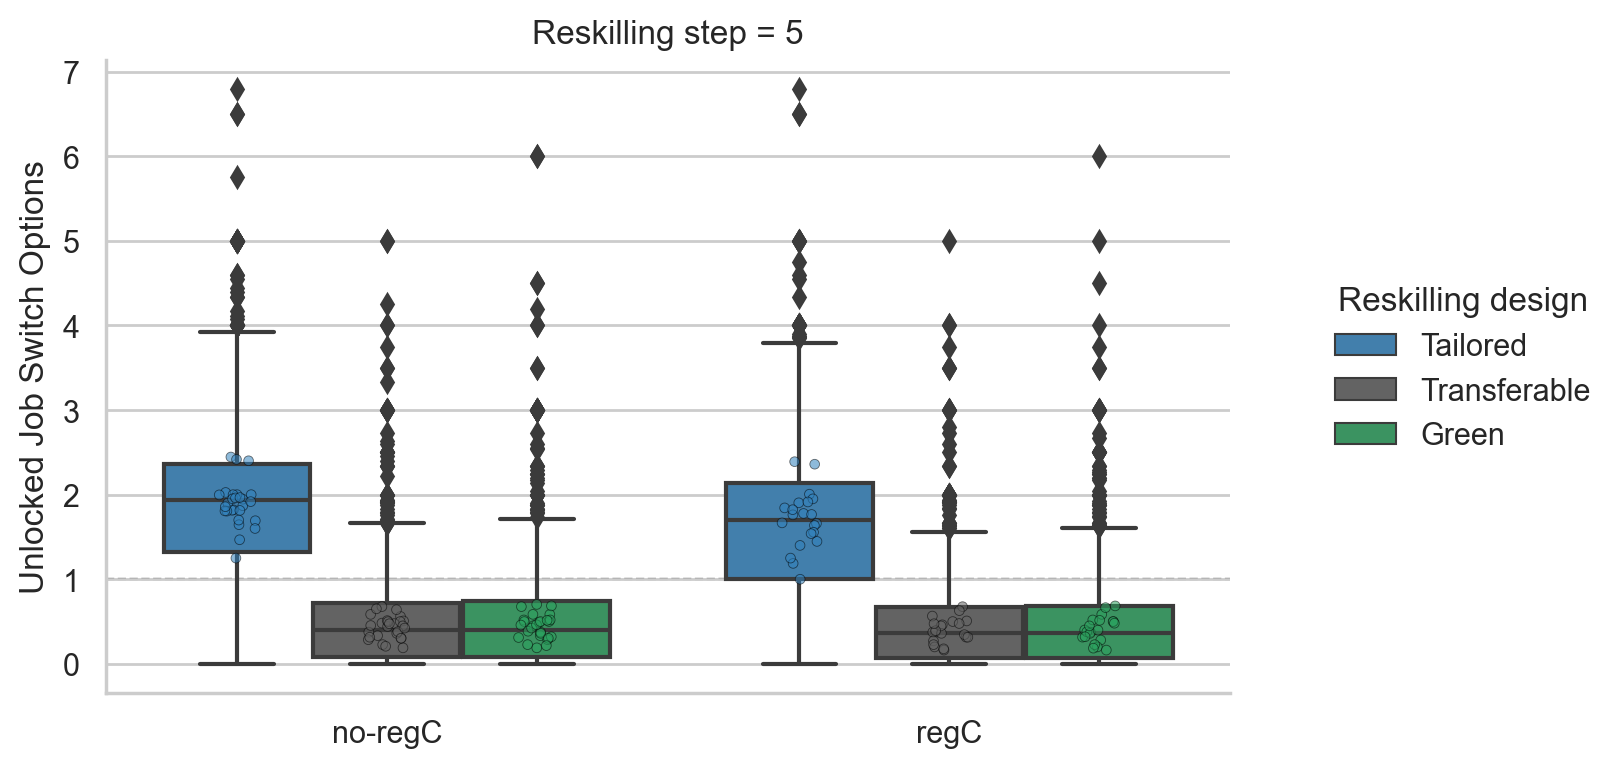

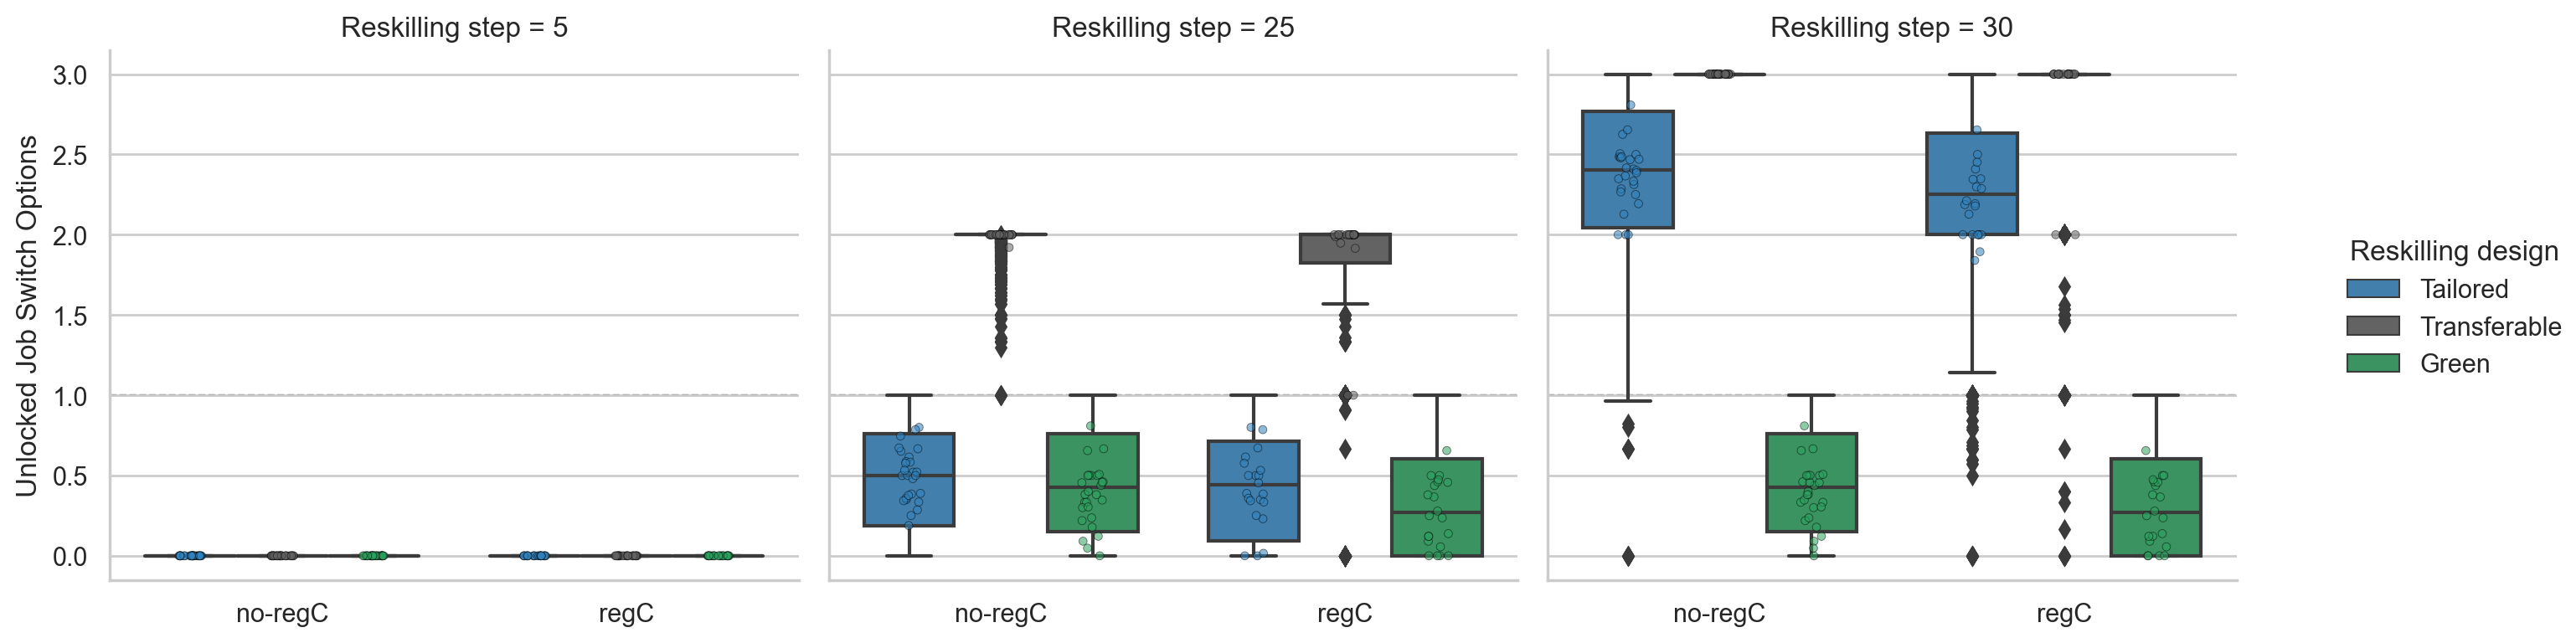

In [34]:
# ---------------------------------------------------------------------------
# Boxplots of unlocked job-switch options (regC vs no-regC) per program, per flow
# ---------------------------------------------------------------------------
# Faceted by reskilling step; one figure per flow (at_risk and shortage).
# x-axis is categorical (regional constraint), so the line-panel axis helpers
# do not apply here; bespoke box/strip styling is preserved.

# ---- config
STEPS    = [5, 25, 30]        # choose key steps to display
ORDER_X  = ["no-regC", "regC"]

PROGRAM = "tailored"
METRIC = "transitions_box"

# display labels for modes (same mapping you used before)
label_map = {
    "reskill-optimal":    "Tailored",
    "reskill-coreWeight": "Transferable",
    "reskill-coreRanked": "Transferable",
    "reskill-green":    "Green" # shortage: "reskill-green":      "Green",
}

# palette (blue / green / grey family)
palette_dict_base = {
    "Tailored":     "#3182bd",  # blue
    "Transferable": "#636363",  # grey
    "Green":      "#2ca25f",  # green , shortage: "Green"
}

for flow in FLOWS:
    # ---- build data slice from long transitions
    need_cols = [
        "COUNTRYW","NUTS_ID","regional_constraint","job_pool","reskilling_mode",
        "reskilling_step","n_transitions"
    ]
    data = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["job_pool"].isin(FLOW_ALIASES[flow])) &
        (df_tidy_long_transitions["reskilling_step"].isin(STEPS)),
        [c for c in need_cols if c in df_tidy_long_transitions.columns]
    ].copy()

    # check
    data["regional_constraint"] = pd.Categorical(
        data["regional_constraint"], categories=["no-regC","regC"], ordered=True
    )

    present = data["regional_constraint"].dropna().unique().tolist()
    assert any(x in present for x in ["no-regC","regC"]), "No regC/no-regC rows found. Did the tidy rebuild finish?"

    # clean numerics
    data["reskilling_step"] = pd.to_numeric(data["reskilling_step"], errors="coerce").astype(int)
    data["n_transitions"]   = pd.to_numeric(data["n_transitions"], errors="coerce")
    data = data.dropna(subset=["n_transitions"])

    # map mode labels and restrict to present ones
    data["mode_label"] = data["reskilling_mode"].map(label_map)
    data = data.dropna(subset=["mode_label"])
    hue_order = [m for m in ["Tailored","Transferable","Digital","Green"] if m in data["mode_label"].unique()]
    palette_dict = {k: palette_dict_base[k] for k in hue_order}

    # nicer facet titles
    col_name = "Reskilling step"
    data[col_name] = data["reskilling_step"].astype(int)

    # ---- country-level medians for overlay dots (avoid overplot clutter)
    df_country = (
        data.groupby(["COUNTRYW","regional_constraint","mode_label",col_name], as_index=False)
            ["n_transitions"].median()
    )

    # ---- plot
    sns.set_theme(style="whitegrid")
    g = sns.catplot(
        data=data,
        x="regional_constraint", y="n_transitions",
        hue="mode_label",
        col=col_name, col_order=sorted(data[col_name].unique()),
        order=ORDER_X, hue_order=hue_order,
        kind="box",
        dodge=True,
        showfliers=True,  # keep, but small markersize
        height=4, aspect=0.9,
        palette=palette_dict,
    )

    # style box fliers smaller
    for ax in g.axes.flatten():
        for artist in ax.artists:
            pass  # seaborn handles styling; we’ll overlay points next

    # overlay country medians as semi-transparent dots
    for ax, step in zip(g.axes.flatten(), sorted(data[col_name].unique())):
        sub = df_country[df_country[col_name] == step]
        sns.stripplot(
            data=sub,
            x="regional_constraint", y="n_transitions",
            hue="mode_label",
            order=ORDER_X, hue_order=hue_order,
            dodge=True, size=3.5, linewidth=0.3,
            edgecolor="black", alpha=0.55,
            palette=palette_dict, ax=ax
        )
        # remove the duplicate legend generated by stripplot
        ax.legend_.remove() if ax.get_legend() else None

        # y=1 guide
        ax.axhline(1, linestyle="--", color="black", linewidth=0.8, zorder=0)

        # tidy labels
        ax.set_xlabel("")
        ax.set_ylabel("Unlocked Job Switch Options" if ax is g.axes.flatten()[0] else "")

    # legend
    try:
        g._legend.remove()
    except Exception:
        pass

    # add a fresh legend and move it
    g.add_legend(title="Reskilling design")
    leg = g._legend
    if leg is not None:
        leg.set_bbox_to_anchor((1.02, 0.5))  # to the right, centered vertically
        # Matplotlib versions differ: prefer set_location(), else set_loc(), else fallback
        if hasattr(leg, "set_location"):
            leg.set_location("center left")
        elif hasattr(leg, "set_loc"):
            leg.set_loc("center left")
        else:
            leg._loc = 6  # center left (fallback; private attr)
        leg.set_frame_on(False)

    # widen right margin so the legend isn't clipped
    g.fig.subplots_adjust(right=0.82)

    plt.tight_layout()

    # ---- save PDF
    outfile = os.path.join(fig_out_dir(flow), fig_name(flow, PROGRAM, METRIC, scope="regC", ext="pdf"))
    plt.savefig(outfile, bbox_inches="tight", format="pdf")
    print(f"Saved: {outfile}")


/tmp/claude-4346793/ipykernel_72843/1024045649.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edata.groupby(["COUNTRYW","regional_constraint","mode_label",col_name], as_index=False)[y_col]
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default o

/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/at_risk/at_risk_tailored_income_box_regC.pdf


/tmp/claude-4346793/ipykernel_72843/1024045649.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  edata.groupby(["COUNTRYW","regional_constraint","mode_label",col_name], as_index=False)[y_col]
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default o

/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/.venv/lib/python3.11/site-packages/seaborn/categ

Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/figures/reskilling_simulation/shortage/shortage_tailored_income_box_regC.pdf


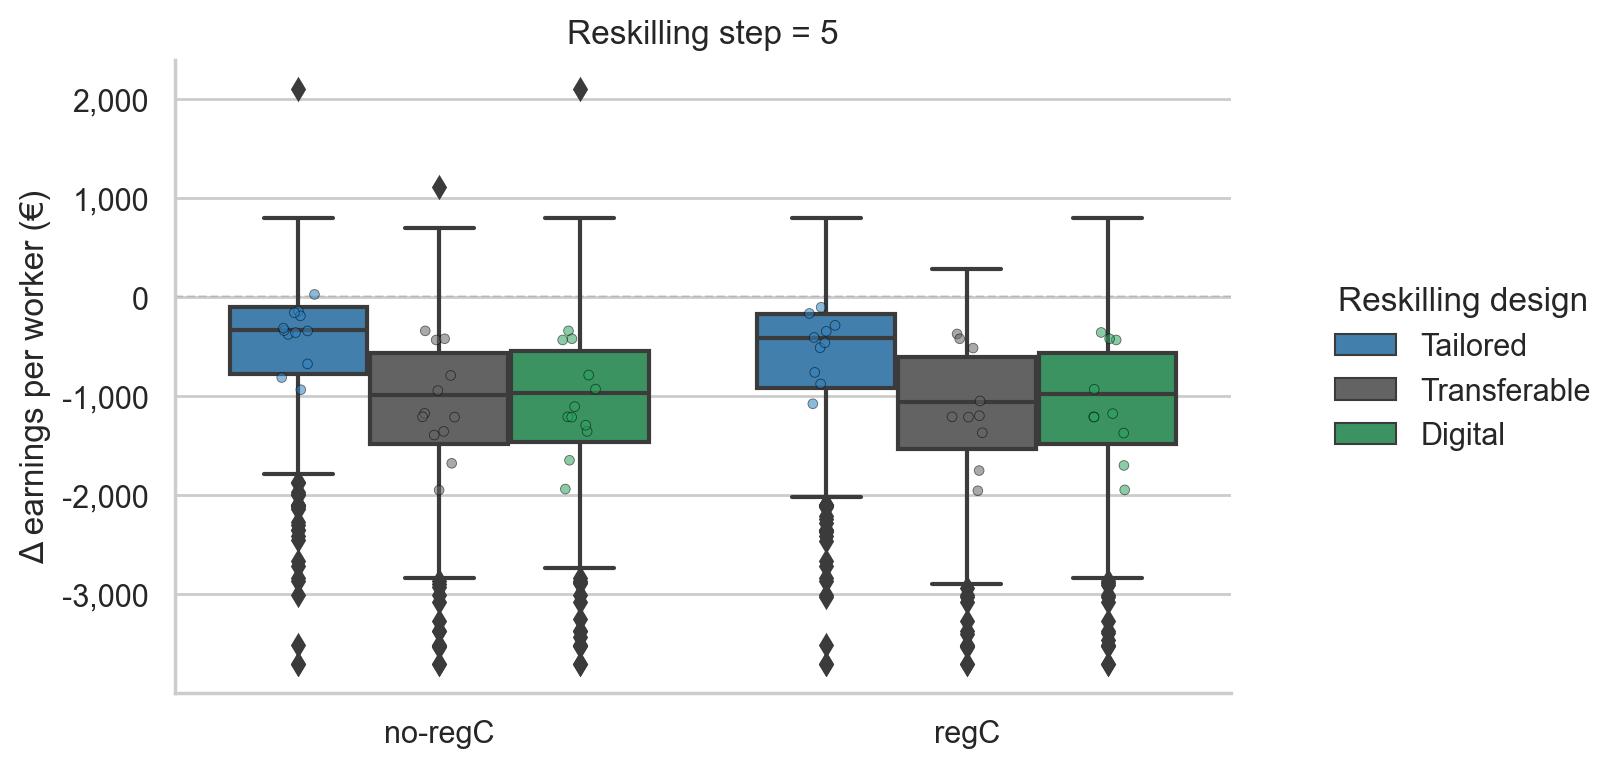

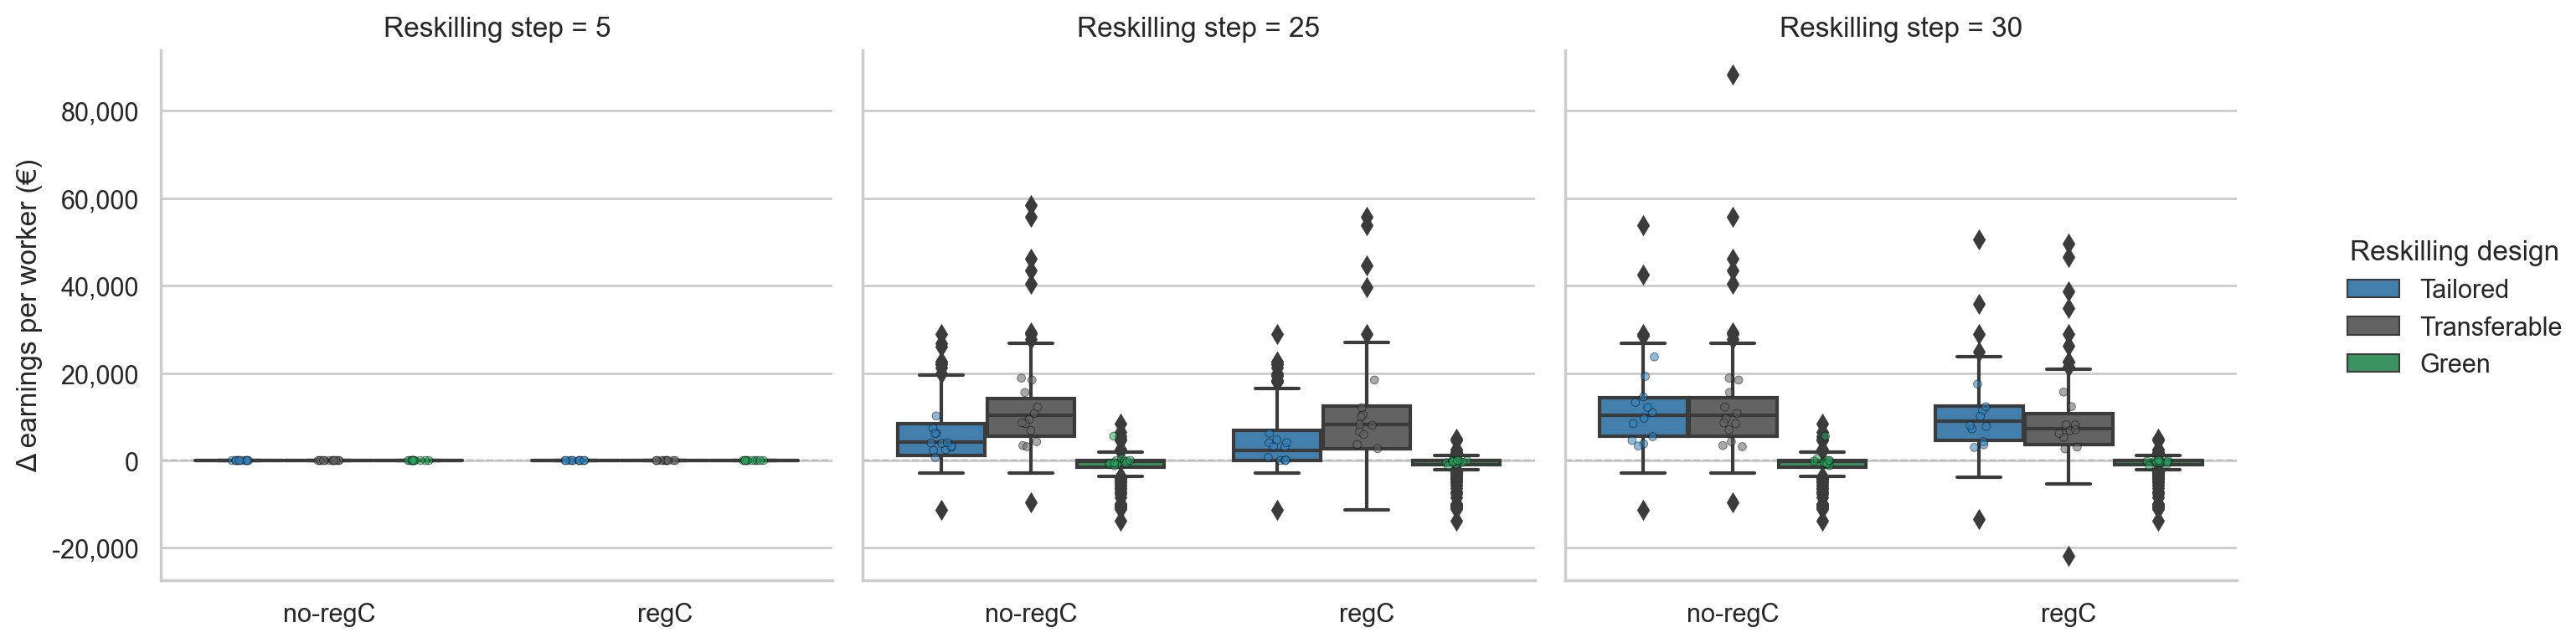

In [35]:
# ---------------------------------------------------------------------------
# Boxplots of Δ earnings per worker (weighted, regC vs no-regC) per program, per flow
# ---------------------------------------------------------------------------
# Faceted by reskilling step; one figure per flow (at_risk and shortage).
# Tailored vs Transferable vs Digital/Green. x-axis is categorical (regional
# constraint), so the line-panel axis helpers do not apply here; bespoke styling
# is preserved.

# ---- config (reuse your choices)
STEPS    = [5, 25, 30] # adapt when shortage/at_risk
ORDER_X  = ["no-regC", "regC"]

PROGRAM = "tailored"
METRIC = "income_box"

# Display labels & palette
label_map = {
    "reskill-optimal":     "Tailored",
    "reskill-coreRanked":  "Transferable",
    "reskill-coreWeight":  "Transferable",  # alias if present
    "reskill-digital":     "Digital",
    "reskill-green":       "Green",
}
palette_dict_base = {
    "Tailored":     "#3182bd",  # blue
    "Transferable": "#636363",  # grey
    "Digital":      "#2ca25f",  # green
    "Green":        "#2ca25f",  # green (same hue for shortage)
}

# ---- source frame (weighted €/worker preferred)
if "df_tidy_long_earnings_merged" not in globals():
    raise RuntimeError("df_tidy_long_earnings_merged not found. Run the tidy/melt prep first.")
y_candidates = ["earnings_delta_rel_w", "earnings_delta_rel"]  # weighted → fallback unweighted
y_col = next((c for c in y_candidates if c in df_tidy_long_earnings_merged.columns), None)
if y_col is None:
    raise RuntimeError("No per-worker earnings column found (earnings_delta_rel_w / earnings_delta_rel).")

for flow in FLOWS:
    # Which three modes to show (Digital for at_risk; Green for shortage)
    if flow == "shortage":
        MODES_WANTED = ["reskill-optimal", "reskill-coreRanked", "reskill-green"]
    else:
        MODES_WANTED = ["reskill-optimal", "reskill-coreRanked", "reskill-digital"]

    # ---- slice data
    need_cols = ["COUNTRYW","regional_constraint","job_pool","reskilling_mode","reskilling_step", y_col]
    edata = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["job_pool"].isin(FLOW_ALIASES[flow])) &
        (df_tidy_long_earnings_merged["reskilling_mode"].isin(MODES_WANTED)) &
        (df_tidy_long_earnings_merged["reskilling_step"].isin(STEPS)),
        [c for c in need_cols if c in df_tidy_long_earnings_merged.columns]
    ].copy()

    # enforce x order and clean numerics
    edata["regional_constraint"] = pd.Categorical(edata["regional_constraint"],
                                                  categories=["no-regC","regC"], ordered=True)
    edata["reskilling_step"] = pd.to_numeric(edata["reskilling_step"], errors="coerce").astype(int)
    edata[y_col] = pd.to_numeric(edata[y_col], errors="coerce")
    edata = edata.dropna(subset=[y_col])

    # map display labels & palette (only those present)
    edata["mode_label"] = edata["reskilling_mode"].map(label_map)
    edata = edata.dropna(subset=["mode_label"])
    hue_order = [m for m in ["Tailored","Transferable","Digital","Green"] if m in edata["mode_label"].unique()]
    palette_dict = {k: palette_dict_base[k] for k in hue_order}

    # facet title
    col_name = "Reskilling step"
    edata[col_name] = edata["reskilling_step"].astype(int)

    # country-level medians for overlay dots
    df_country = (
        edata.groupby(["COUNTRYW","regional_constraint","mode_label",col_name], as_index=False)[y_col]
             .median()
    )

    # ---- plot
    sns.set_theme(style="whitegrid")
    g = sns.catplot(
        data=edata,
        x="regional_constraint", y=y_col,
        hue="mode_label",
        col=col_name, col_order=sorted(edata[col_name].unique()),
        order=[x for x in ORDER_X if x in edata["regional_constraint"].cat.categories],
        hue_order=hue_order,
        kind="box",
        dodge=True,
        showfliers=True,
        height=4, aspect=0.9,
        palette=palette_dict,
    )

    # overlay dots = country medians
    for ax, step in zip(g.axes.flatten(), sorted(edata[col_name].unique())):
        sub = df_country[df_country[col_name] == step]
        if not sub.empty:
            sns.stripplot(
                data=sub,
                x="regional_constraint", y=y_col,
                hue="mode_label",
                order=[x for x in ORDER_X if x in edata["regional_constraint"].cat.categories],
                hue_order=hue_order,
                dodge=True, size=3.5, linewidth=0.3,
                edgecolor="black", alpha=0.55,
                palette=palette_dict, ax=ax
            )
            if ax.get_legend() is not None:
                ax.get_legend().remove()

        ax.axhline(0, linestyle="--", color="black", linewidth=0.8, zorder=0)
        ax.set_xlabel("")
        ax.set_ylabel("Δ earnings per worker (€)" if ax is g.axes.flatten()[0] else "")
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v:,.0f}"))

    # legend outside on the right (version-safe)
    try:
        g._legend.remove()
    except Exception:
        pass
    g.add_legend(title="Reskilling design")
    leg = g._legend
    if leg is not None:
        leg.set_bbox_to_anchor((1.02, 0.5))
        if hasattr(leg, "set_location"):
            leg.set_location("center left")
        elif hasattr(leg, "set_loc"):
            leg.set_loc("center left")
        else:
            leg._loc = 6
        leg.set_frame_on(False)

    g.fig.subplots_adjust(right=0.82)
    plt.tight_layout()

    # ---- save
    outfile = os.path.join(fig_out_dir(flow), fig_name(flow, PROGRAM, METRIC, scope="regC", ext="pdf"))
    plt.savefig(outfile, bbox_inches="tight", format="pdf")
    print(f"Saved: {outfile}")


#### 5. Summary tables

In [36]:
# ---------------------------------------------------------------------------
# Appendix summary table by sector within each country, per flow
# ---------------------------------------------------------------------------
# €/worker (median, weighted) and Totals (Mio €) by sector within each country.
# Values at each (country×sector)'s first-unlock step (median n_transitions ≥ 1);
# Country summary rows use the country-level first-unlock step.
# One table per flow (at_risk and shortage); flows are never pooled.

# ---- Settings
MODE = "reskill-optimal"
REGC = "regC"
y_pw  = "earnings_delta_rel_w"   # €/worker (weighted)
y_tot = "earnings_delta_abs"     # totals €

PROGRAM = "tailored"
METRIC = "summary_by_sector"

# ---- Sector label (same as sector plots)
base_sector_col = "NACE2_1D_label"
sector_source = (
    "NACE2_1D_label_short"
    if "NACE2_1D_label_short" in df_tidy_long_earnings_merged.columns
    else base_sector_col
)

def compact_sector_label(s: str) -> str:
    if sector_source == "NACE2_1D_label_short":
        return str(s)
    s = re.sub(r"\s+", " ", str(s)).strip().replace(" and ", " & ")
    repl = {
        "Activities": "Act.", "Activity": "Act.", "Management": "Mgmt.",
        "Professional": "Prof.", "Scientific": "Sci.", "Technical": "Tech.",
        "Information": "Info.", "Communication": "Comm.",
        "Financial": "Fin.", "Insurance": "Ins.",
        "Administrative": "Admin.", "Support": "Support",
        "Transportation": "Transport", "Storage": "Storage",
        "Sewerage": "Sewer.", "Remediation": "Remed.",
    }
    for k, v in repl.items():
        s = re.sub(rf"\b{k}\b", v, s)
    return s

def euro0(x):
    try: return f"€{x:,.0f}".replace(",", " ")
    except: return "—"

def mio1(x):
    try: return f"{x:,.1f}".replace(",", " ")
    except: return "—"

def col_as_series(df, colname):
    """Return the first occurrence of a duplicated column name as a Series, else None."""
    if colname not in df.columns:
        return None
    sub = df.loc[:, df.columns == colname]
    return sub.iloc[:, 0] if sub.shape[1] else None

def pick_series(df, names):
    """Return the first non-None Series among candidate names."""
    for n in names:
        s = col_as_series(df, n)
        if s is not None:
            return s
    return None

def first_unlock_step(steps, vals):
    steps = np.asarray(steps); vals = np.asarray(vals)
    idx = np.where(vals >= 1)[0]
    return int(steps[idx[0]]) if idx.size else None

for flow in FLOWS:
    POOL_SET = FLOW_ALIASES[flow]

    # -----------------------------
    # Slice & clean earnings data (filtered to this flow)
    # -----------------------------
    earn = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["regional_constraint"] == REGC) &
        (df_tidy_long_earnings_merged["reskilling_mode"]     == MODE) &
        (df_tidy_long_earnings_merged["job_pool"].astype(str).isin(POOL_SET)),
        :
    ].copy()

    # Drop duplicate-named columns (keep first)
    earn = earn.loc[:, ~earn.columns.duplicated()]

    need_earn_cols = ["COUNTRYW","NUTS_ID","reskilling_step", y_pw, y_tot]
    for c in need_earn_cols:
        if c not in earn.columns:
            raise KeyError(f"Missing '{c}' in earnings frame; check the prep block.")

    # Build sector display in earnings (robust)
    sec_series_earn = pick_series(earn, [sector_source, base_sector_col])
    if sec_series_earn is None:
        raise KeyError(f"Neither '{sector_source}' nor '{base_sector_col}' present in earnings frame.")
    if sector_source in earn.columns:
        earn["sector_disp"] = sec_series_earn.astype(str)
    else:
        earn["sector_disp"] = sec_series_earn.astype(str).map(compact_sector_label)

    earn = earn[["COUNTRYW","NUTS_ID","reskilling_step","sector_disp", y_pw, y_tot]].copy()
    for c in ["reskilling_step", y_pw, y_tot]:
        earn[c] = pd.to_numeric(earn[c], errors="coerce")
    earn.dropna(subset=["COUNTRYW","reskilling_step"], inplace=True)
    earn["reskilling_step"] = earn["reskilling_step"].astype(int)

    # Countries & sectors
    countries = sorted(earn["COUNTRYW"].dropna().unique().tolist())
    sectors   = sorted(earn["sector_disp"].dropna().unique().tolist())

    # -----------------------------
    # Transitions (for first-unlock), filtered to this flow
    # -----------------------------
    tran = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["regional_constraint"] == REGC) &
        (df_tidy_long_transitions["reskilling_mode"]     == MODE) &
        (df_tidy_long_transitions["job_pool"].astype(str).isin(POOL_SET)),
        :
    ].copy()

    tran = tran.loc[:, ~tran.columns.duplicated()]  # drop duplicate-named cols

    need_tran_cols = ["COUNTRYW","NUTS_ID","reskilling_step","n_transitions"]
    for c in need_tran_cols:
        if c not in tran.columns:
            raise KeyError(f"Missing '{c}' in transitions frame.")

    # Build sector display in transitions (robust)
    sec_series_tran = pick_series(tran, [sector_source, base_sector_col])
    if sec_series_tran is None:
        raise KeyError(f"Neither '{sector_source}' nor '{base_sector_col}' present in transitions frame.")
    if sector_source in tran.columns:
        tran["sector_disp"] = sec_series_tran.astype(str)
    else:
        tran["sector_disp"] = sec_series_tran.astype(str).map(compact_sector_label)

    # numeric clean
    tran["reskilling_step"] = pd.to_numeric(tran["reskilling_step"], errors="coerce").astype("Int64")
    tran["n_transitions"]   = pd.to_numeric(tran["n_transitions"],   errors="coerce")
    tran.dropna(subset=["COUNTRYW","reskilling_step","n_transitions","sector_disp"], inplace=True)
    tran["reskilling_step"] = tran["reskilling_step"].astype(int)
    tran = tran[tran["COUNTRYW"].isin(countries)].copy()

    # median transitions per (country, sector, step)
    med_tran_cs = (
        tran.groupby(["COUNTRYW","sector_disp","reskilling_step"])["n_transitions"]
            .median().reset_index()
    )
    # median transitions per (country, step)
    med_tran_c = (
        tran.groupby(["COUNTRYW","reskilling_step"])["n_transitions"]
            .median().reset_index()
    )

    # Lookups
    first_unlock_cs = {}
    for (cty, sec), sub in med_tran_cs.groupby(["COUNTRYW","sector_disp"]):
        st = first_unlock_step(sub["reskilling_step"].values, sub["n_transitions"].values)
        if st is not None:
            first_unlock_cs[(cty, sec)] = st

    first_unlock_c = {}
    for cty, sub in med_tran_c.groupby("COUNTRYW"):
        st = first_unlock_step(sub["reskilling_step"].values, sub["n_transitions"].values)
        if st is not None:
            first_unlock_c[cty] = st

    # -----------------------------
    # Aggregate earnings at needed steps
    # -----------------------------
    med_earn_cs = (
        earn.groupby(["COUNTRYW","sector_disp","reskilling_step"])[y_pw]
            .median().reset_index()
    )
    med_earn_c = (
        earn.groupby(["COUNTRYW","reskilling_step"])[y_pw]
            .median().reset_index()
    )
    sum_tot_c = (
        earn.groupby(["COUNTRYW","reskilling_step"])[y_tot]
            .sum().reset_index()
    )

    # -----------------------------
    # Build output matrix
    # -----------------------------
    row_labels = sectors + ["Country avg (€/worker)", "Country total (Mio €)"]
    out = pd.DataFrame(index=row_labels, columns=countries, dtype=object)

    for cty in countries:
        step_c = first_unlock_c.get(cty, None)

        # sector rows (each at its own first unlock)
        for sec in sectors:
            step_cs = first_unlock_cs.get((cty, sec), None)
            if step_cs is None:
                out.loc[sec, cty] = "—"
                continue
            sub = med_earn_cs[
                (med_earn_cs["COUNTRYW"]==cty) &
                (med_earn_cs["sector_disp"]==sec) &
                (med_earn_cs["reskilling_step"]==step_cs)
            ]
            out.loc[sec, cty] = (
                f"{euro0(float(sub[y_pw].iloc[0]))} (step {step_cs})" if len(sub) else "—"
            )

        # country avg €/worker at country-level step
        if step_c is not None:
            subc = med_earn_c[(med_earn_c["COUNTRYW"]==cty) & (med_earn_c["reskilling_step"]==step_c)]
            out.loc["Country avg (€/worker)", cty] = (
                f"{euro0(float(subc[y_pw].iloc[0]))} (step {step_c})" if len(subc) else "—"
            )
        else:
            out.loc["Country avg (€/worker)", cty] = "—"

        # country total (Mio €) at country-level step
        if step_c is not None:
            subt = sum_tot_c[(sum_tot_c["COUNTRYW"]==cty) & (sum_tot_c["reskilling_step"]==step_c)]
            out.loc["Country total (Mio €)", cty] = (
                f"{mio1(float(subt[y_tot].iloc[0]) / 1e6)} (step {step_c})" if len(subt) else "—"
            )
        else:
            out.loc["Country total (Mio €)", cty] = "—"

    print(f"Flow: {flow} | Countries: {len(countries)} | Sectors: {len(sectors)}")
    display(out)

    # Save to disk
    csv_path  = os.path.join(table_out_dir(flow), fig_name(flow, PROGRAM, METRIC, scope="regC", ext="csv"))
    out.to_csv(csv_path, encoding="utf-8-sig")
    print(f"Saved: {csv_path}")


Flow: at_risk | Countries: 21 | Sectors: 8


,AT,BE,CH,CZ,DE,DK,EL,ES,FI,FR,HR,HU,IE,IT,LT,NO,PL,PT,RO,SE,SK
"Agriculture, Forestry and Fishing",€nan (step 4),€nan (step 14),€-1 754 (step 0),€nan (step 8),€nan (step 4),€-694 (step 13),€61 (step 4),€nan (step 10),€437 (step 14),€-1 003 (step 7),€nan (step 5),€nan (step 8),€-652 (step 4),€nan (step 10),€nan (step 7),€-825 (step 6),€nan (step 14),€-421 (step 11),€nan (step 5),€319 (step 14),€-342 (step 8)
Construction,€nan (step 4),€nan (step 4),€-382 (step 4),€nan (step 4),€nan (step 4),€-416 (step 4),€56 (step 4),€nan (step 4),€-186 (step 4),€-229 (step 4),€nan (step 4),€nan (step 4),€-68 (step 4),€nan (step 4),€nan (step 4),€-416 (step 4),€nan (step 4),€-126 (step 4),€nan (step 4),€-365 (step 4),€-19 (step 4)
"Electricity, Gas, Steam and Air Conditioning Supply",€nan (step 4),€nan (step 4),€-965 (step 4),€nan (step 4),€nan (step 4),€-1 594 (step 0),€-55 (step 4),€nan (step 4),€-1 396 (step 0),€-436 (step 4),€nan (step 4),€nan (step 4),€-716 (step 0),€nan (step 4),€nan (step 0),€-2 408 (step 0),€nan (step 4),€-361 (step 4),€nan (step 4),€-1 478 (step 0),€-195 (step 4)
Manufacturing,€nan (step 0),€nan (step 4),€-1 605 (step 3),€nan (step 3),€nan (step 4),€-1 372 (step 0),€-137 (step 6),€nan (step 4),€-1 021 (step 0),€-464 (step 4),€nan (step 3),€nan (step 3),€-992 (step 4),€nan (step 3),€nan (step 3),€-875 (step 4),€nan (step 0),€-193 (step 6),€nan (step 3),€-897 (step 3),€-302 (step 3)
Mining and Quarrying,€nan (step 4),€nan (step 0),€-1 714 (step 13),€nan (step 4),€nan (step 4),€-1 472 (step 0),€-181 (step 5),€nan (step 4),€-1 119 (step 4),€-1 027 (step 4),€nan (step 6),€nan (step 4),€132 (step 6),€nan (step 4),€nan (step 4),€-1 552 (step 4),€nan (step 4),€-199 (step 4),€nan (step 4),€-501 (step 5),€-84 (step 4)
Transportation and Storage,€nan (step 7),€nan (step 8),€-1 657 (step 10),€nan (step 8),€nan (step 9),€-1 531 (step 10),€-314 (step 13),€nan (step 10),€-988 (step 5),€-587 (step 7),€nan (step 7),€nan (step 5),€-576 (step 7),€nan (step 9),€nan (step 4),€-1 370 (step 8),€nan (step 8),€-494 (step 8),€nan (step 5),€-1 193 (step 10),€-266 (step 7)
"Water Supply; Sewerage, Waste Management and Remediation Activities",€nan (step 4),€nan (step 4),€-646 (step 4),€nan (step 4),€nan (step 4),€-1 170 (step 4),€-57 (step 0),€nan (step 4),€-356 (step 4),€-138 (step 4),€nan (step 4),€nan (step 5),€-435 (step 4),€nan (step 4),€nan (step 4),€-1 417 (step 7),€nan (step 4),€-230 (step 4),€nan (step 0),€-468 (step 4),€-67 (step 4)
Wholesale and Retail Trade; Repair of Motor Vehicles and Motorcycles,€nan (step 4),€nan (step 5),€-746 (step 5),€nan (step 5),€nan (step 5),€-658 (step 5),€-11 (step 5),€nan (step 5),€-103 (step 4),€-345 (step 5),€nan (step 5),€nan (step 4),€-189 (step 8),€nan (step 4),€nan (step 4),€-1 013 (step 5),€nan (step 5),€-195 (step 6),€nan (step 4),€-393 (step 5),€-154 (step 5)
Country avg (€/worker),€nan (step 4),€nan (step 4),€-864 (step 4),€nan (step 4),€nan (step 4),€-1 048 (step 4),€-102 (step 5),€nan (step 4),€-589 (step 4),€-470 (step 4),€nan (step 4),€nan (step 4),€-673 (step 4),€nan (step 4),€nan (step 4),€-1 057 (step 4),€nan (step 4),€-285 (step 5),€nan (step 4),€-434 (step 4),€-168 (step 4)
Country total (Mio €),0.0 (step 4),0.0 (step 4),-510.0 (step 4),0.0 (step 4),0.0 (step 4),-368.3 (step 4),-77.4 (step 5),0.0 (step 4),-172.1 (step 4),-2 159.0 (step 4),0.0 (step 4),0.0 (step 4),-374.6 (step 4),0.0 (step 4),0.0 (step 4),-578.1 (step 4),0.0 (step 4),-97.0 (step 5),0.0 (step 4),-383.3 (step 4),-107.1 (step 4)


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/tables/reskilling_simulation/at_risk/at_risk_tailored_summary_by_sector_regC.csv


Flow: shortage | Countries: 21 | Sectors: 8


,AT,BE,CH,CZ,DE,DK,EL,ES,FI,FR,HR,HU,IE,IT,LT,NO,PL,PT,RO,SE,SK
"Agriculture, Forestry and Fishing",€nan (step 27),€nan (step 27),€22 695 (step 24),€nan (step 24),€nan (step 24),€13 026 (step 26),€1 945 (step 26),€nan (step 24),€6 775 (step 24),€15 117 (step 24),€nan (step 26),€nan (step 26),€4 484 (step 27),€nan (step 27),€nan (step 26),€0 (step 26),€nan (step 26),—,€nan (step 26),€6 967 (step 26),€1 984 (step 26)
Construction,€nan (step 27),€nan (step 27),€7 888 (step 26),€nan (step 27),€nan (step 26),€0 (step 24),—,€nan (step 27),€3 618 (step 24),€4 604 (step 26),—,€nan (step 27),€1 267 (step 26),€nan (step 26),€nan (step 26),€9 352 (step 26),€nan (step 26),€5 072 (step 26),€nan (step 26),€7 945 (step 24),€3 747 (step 27)
"Electricity, Gas, Steam and Air Conditioning Supply",€nan (step 27),€nan (step 27),€6 638 (step 26),€nan (step 24),€nan (step 26),—,€4 387 (step 24),€nan (step 24),€-1 463 (step 24),€7 686 (step 26),€nan (step 24),€nan (step 27),€0 (step 24),€nan (step 27),€nan (step 24),€8 665 (step 24),€nan (step 27),—,€nan (step 24),€3 637 (step 24),€2 554 (step 27)
Manufacturing,€nan (step 26),€nan (step 27),€16 266 (step 27),€nan (step 27),€nan (step 26),€8 251 (step 27),€3 145 (step 27),€nan (step 26),€7 610 (step 26),€8 412 (step 27),€nan (step 27),€nan (step 27),€5 108 (step 26),€nan (step 29),€nan (step 27),€13 455 (step 27),€nan (step 27),—,€nan (step 27),€7 931 (step 27),€2 950 (step 27)
Mining and Quarrying,€nan (step 27),—,€7 590 (step 26),€nan (step 24),€nan (step 26),—,€-383 (step 26),€nan (step 26),€-1 463 (step 24),€12 824 (step 26),€nan (step 24),€nan (step 27),€5 451 (step 24),€nan (step 26),€nan (step 24),€12 342 (step 24),€nan (step 26),—,€nan (step 24),€6 923 (step 24),€3 244 (step 27)
Transportation and Storage,€nan (step 27),€nan (step 27),€13 962 (step 27),€nan (step 27),€nan (step 27),€7 754 (step 27),€1 943 (step 27),€nan (step 27),€6 056 (step 27),€8 422 (step 27),€nan (step 27),€nan (step 27),€-826 (step 26),€nan (step 27),€nan (step 27),€8 914 (step 27),€nan (step 27),€2 888 (step 29),€nan (step 27),€7 323 (step 27),€2 570 (step 27)
"Water Supply; Sewerage, Waste Management and Remediation Activities",€nan (step 27),€nan (step 26),€14 112 (step 27),€nan (step 27),€nan (step 26),€5 705 (step 27),—,€nan (step 26),€4 746 (step 27),€9 924 (step 26),€nan (step 24),€nan (step 27),€5 460 (step 24),€nan (step 27),€nan (step 27),€7 905 (step 27),€nan (step 26),€3 768 (step 26),€nan (step 24),€3 205 (step 27),€2 666 (step 27)
Wholesale and Retail Trade; Repair of Motor Vehicles and Motorcycles,€nan (step 26),€nan (step 27),€11 334 (step 26),€nan (step 26),€nan (step 27),€5 798 (step 26),€2 419 (step 26),€nan (step 26),€8 755 (step 26),€10 423 (step 29),€nan (step 27),€nan (step 26),€3 610 (step 26),€nan (step 26),€nan (step 26),€13 965 (step 27),€nan (step 26),€6 502 (step 27),€nan (step 26),€4 370 (step 26),€1 466 (step 26)
Country avg (€/worker),€nan (step 27),€nan (step 27),€16 052 (step 27),€nan (step 26),€nan (step 26),€9 907 (step 27),€1 598 (step 26),€nan (step 26),€4 297 (step 26),€9 918 (step 27),€nan (step 26),€nan (step 27),€2 430 (step 26),€nan (step 27),€nan (step 26),€11 983 (step 27),€nan (step 27),€7 536 (step 29),€nan (step 26),€3 143 (step 26),€2 935 (step 27)
Country total (Mio €),0.0 (step 27),0.0 (step 27),4 167.5 (step 27),0.0 (step 26),0.0 (step 26),1 129.3 (step 27),295.8 (step 26),0.0 (step 26),760.7 (step 26),14 132.2 (step 27),0.0 (step 26),0.0 (step 27),234.5 (step 26),0.0 (step 27),0.0 (step 26),2 288.6 (step 27),0.0 (step 27),2 376.8 (step 29),0.0 (step 26),814.3 (step 26),604.4 (step 27)


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/tables/reskilling_simulation/shortage/shortage_tailored_summary_by_sector_regC.csv


In [37]:
# ---------------------------------------------------------------------------
# Appendix summary table by country and sector at first-unlock step, per flow
# ---------------------------------------------------------------------------
# Income change (€/worker + Mio € totals) by country and sector at first-unlock
# step — robust y_pw selection. One table per flow (at_risk and shortage);
# flows are never pooled.


# ---- Config ----
MODE = "reskill-optimal"
REG  = "regC"

PROGRAM = "tailored"
METRIC = "summary_by_country"

# Countries without earnings (you provided these)
iso_missing_earnings = ['IT','NL','DE','HU','AT','RO','PL','ES','LT','CY','BE','CZ','HR','IS','LV']

# ---- Compact sector labels ----
compact_map = {
    "Agriculture, Forestry and Fishing": "Agri., Forest., Fish.",
    "Mining and Quarrying": "Mining",
    "Manufacturing": "Manufacturing",
    "Electricity, Gas, Steam and Air Conditioning Supply": "Electricity, Gas",
    "Water Supply; Sewerage, Waste Management and Remediation Activities": "Water, Waste Mgmt.",
    "Construction": "Construction",
    "Wholesale and Retail Trade; Repair of Motor Vehicles and Motorcycles": "Trade, Repair",
    "Transportation and Storage": "Transport",
    "Information and Communication": "Info. & Comm.",
    "Financial and Insurance Activities": "Finance & Insurance",
    "Professional, Scientific and Technical Activities": "Prof., Sci., Tech.",
    "Administrative and Support Service Activities": "Admin. & Support",
}
def compact_sector_label(s): return compact_map.get(s, s)

# ---- Helper for duplicate columns ----
def col_as_series(df, colname):
    """Return the first column as a Series if duplicated names exist; None if absent."""
    if colname not in df.columns:
        return None
    sub = df.loc[:, df.columns == colname]
    if sub.shape[1] == 0:
        return None
    return sub.iloc[:, 0]

def first_unlock_step(group):
    s = group.groupby("reskilling_step")["n_transitions"].median().sort_index()
    ge1 = np.where(s.values >= 1)[0]
    return (int(s.index[ge1[0]]) if len(ge1) else np.nan)

for flow in FLOWS:
    countries_with_data = sorted(
        [c for c in df_tidy_long_earnings_merged["COUNTRYW"].unique() if c not in iso_missing_earnings]
    )

    # ==========================================================
    # 1) Prepare earnings and transitions frames (filtered to this flow)
    # ==========================================================
    earn = df_tidy_long_earnings_merged.copy()
    tran = df_tidy_long_transitions.copy()

    # Remove duplicate-named columns
    earn = earn.loc[:, ~earn.columns.duplicated()]
    tran = tran.loc[:, ~tran.columns.duplicated()]

    # Keep only relevant constraint, mode & flow
    earn = earn.loc[
        (earn["reskilling_mode"] == MODE) &
        (earn["regional_constraint"] == REG) &
        (earn["job_pool"].astype(str).isin(FLOW_ALIASES[flow]))
    ].copy()
    tran = tran.loc[
        (tran["reskilling_mode"] == MODE) &
        (tran["regional_constraint"] == REG) &
        (tran["job_pool"].astype(str).isin(FLOW_ALIASES[flow]))
    ].copy()

    # ---- Decide €/worker column (y_pw) robustly
    y_tot = "earnings_delta_abs"

    if "earnings_delta_rel_w" in earn.columns:
        y_pw = "earnings_delta_rel_w"
    elif "earnings_delta_rel" in earn.columns:
        y_pw = "earnings_delta_rel"  # unweighted fallback
    elif ("earnings_delta_abs" in earn.columns) and ("weight_sum" in earn.columns):
        earn["earnings_delta_rel_w"] = earn["earnings_delta_abs"] / earn["weight_sum"]
        earn.loc[earn["weight_sum"] == 0, "earnings_delta_rel_w"] = np.nan
        y_pw = "earnings_delta_rel_w"
    else:
        raise KeyError(
            "No per-worker earnings column available. Need 'earnings_delta_rel_w' or "
            "'earnings_delta_rel' or both 'earnings_delta_abs' and 'weight_sum' to compute it."
        )

    # Sanity checks
    for c in ["COUNTRYW","reskilling_step", y_tot, y_pw]:
        if c not in earn.columns:
            raise KeyError(f"Missing '{c}' in earnings frame.")

    # Sector label (prefer short if present) — NO 'or' on Series
    sector_col_short = "NACE2_1D_label_short"
    sector_col_base  = "NACE2_1D_label"
    sec_series_earn = col_as_series(earn, sector_col_short)
    if sec_series_earn is None:
        sec_series_earn = col_as_series(earn, sector_col_base)
    if sec_series_earn is None:
        raise KeyError("No sector label column found in earnings frame.")
    earn["sector_disp"] = sec_series_earn.astype(str).map(compact_sector_label)

    # Ensure transitions has sector too (use base/short if present) — NO 'or' on Series
    sec_series_tran = col_as_series(tran, sector_col_short)
    if sec_series_tran is None:
        sec_series_tran = col_as_series(tran, sector_col_base)
    if sec_series_tran is None:
        tran["sector_disp"] = "All sectors"  # rare fallback
    else:
        tran["sector_disp"] = sec_series_tran.astype(str).map(compact_sector_label)

    # ---- Clean numeric
    for df_ in [earn, tran]:
        df_["reskilling_step"] = pd.to_numeric(df_["reskilling_step"], errors="coerce").astype("Int64")
    earn[y_pw]  = pd.to_numeric(earn[y_pw],  errors="coerce")
    earn[y_tot] = pd.to_numeric(earn[y_tot], errors="coerce")
    tran["n_transitions"] = pd.to_numeric(tran["n_transitions"], errors="coerce")

    # Keep only countries that have earnings data
    earn = earn[earn["COUNTRYW"].isin(countries_with_data)].copy()
    tran = tran[tran["COUNTRYW"].isin(countries_with_data)].copy()

    # ==========================================================
    # 2) Compute first unlock steps (median n_transitions ≥ 1)
    # ==========================================================
    first_unlock_cs = (
        tran.groupby(["COUNTRYW", "sector_disp"], dropna=False)
            .apply(first_unlock_step)
            .reset_index(name="first_unlock_step")
    )

    first_unlock_c = (
        tran.groupby(["COUNTRYW"], dropna=False)
            .apply(first_unlock_step)
            .reset_index(name="first_unlock_step")
    )

    # ==========================================================
    # 3) Median €/worker + total Mio € at those steps
    # ==========================================================
    med_earn_cs = (
        earn.groupby(["COUNTRYW", "sector_disp", "reskilling_step"], dropna=False)[y_pw]
            .median().reset_index()
    )
    sum_tot_c = (
        earn.groupby(["COUNTRYW", "reskilling_step"], dropna=False)[y_tot]
            .sum().reset_index()
    )

    # ==========================================================
    # 4) Assemble the wide table
    # ==========================================================
    sectors_list = sorted(earn["sector_disp"].dropna().unique())
    out = pd.DataFrame()

    for country in countries_with_data:
        col_vals = {}
        # per-sector rows
        for sector in sectors_list:
            step = first_unlock_cs.loc[
                (first_unlock_cs["COUNTRYW"] == country) &
                (first_unlock_cs["sector_disp"] == sector),
                "first_unlock_step"
            ]
            if step.empty or not np.isfinite(step.iloc[0]):
                val_txt = "—"
            else:
                st = int(step.iloc[0])
                val = med_earn_cs.loc[
                    (med_earn_cs["COUNTRYW"] == country) &
                    (med_earn_cs["sector_disp"] == sector) &
                    (med_earn_cs["reskilling_step"] == st),
                    y_pw
                ]
                val_txt = (
                    f"€{val.iloc[0]:,.0f}".replace(",", " ") + f" (step {st})"
                    if len(val) and np.isfinite(val.iloc[0]) else "—"
                )
            col_vals[sector] = val_txt

        # Country avg and total (at country unlock step)
        step_c = first_unlock_c.loc[first_unlock_c["COUNTRYW"] == country, "first_unlock_step"]
        if step_c.empty or not np.isfinite(step_c.iloc[0]):
            avg_txt = tot_txt = "—"
        else:
            stc = int(step_c.iloc[0])
            # country avg €/worker = median across (NUTS×sector) at that step
            val_avg = earn.loc[
                (earn["COUNTRYW"] == country) &
                (earn["reskilling_step"] == stc),
                y_pw
            ]
            # country total Mio €
            val_tot = sum_tot_c.loc[
                (sum_tot_c["COUNTRYW"] == country) &
                (sum_tot_c["reskilling_step"] == stc),
                y_tot
            ]
            avg_txt = (
                f"€{val_avg.median():,.0f}".replace(",", " ") + f" (step {stc})"
                if len(val_avg) and np.isfinite(val_avg.median()) else "—"
            )
            tot_txt = (
                f"{(val_tot.sum()/1e6):,.1f}".replace(",", " ") + f" (step {stc})"
                if len(val_tot) and np.isfinite(val_tot.sum()) else "—"
            )

        col_vals["Country avg (€/worker)"] = avg_txt
        col_vals["Country total (Mio €)"]  = tot_txt

        out[country] = pd.Series(col_vals)

    # Ensure row order: sectors, then summaries
    out = out.reindex(sectors_list + ["Country avg (€/worker)", "Country total (Mio €)"])

    # ==========================================================
    # 5) Order countries by total loss (most negative first)
    # ==========================================================
    order_vals = []
    for c in out.columns:
        val = out.at["Country total (Mio €)", c]
        try:
            num = float(val.split(" ")[0].replace(" ","").replace(",", ""))
        except Exception:
            num = 0.0
        order_vals.append((c, num))
    order_sorted = [c for c,_ in sorted(order_vals, key=lambda x: x[1])]
    out = out.loc[:, order_sorted]

    # ==========================================================
    # 6) Display + Save
    # ==========================================================
    pd.options.display.max_rows = 30
    pd.options.display.max_colwidth = 40
    display(out.style.set_caption(f"Income change at first unlocked job transition — flow={flow}, mode={MODE}, regC"))

    csv_path  = os.path.join(table_out_dir(flow), fig_name(flow, PROGRAM, METRIC, scope="regC", ext="csv"))
    out.to_csv(csv_path, encoding="utf-8-sig")
    print(f"Saved: {csv_path}")


/tmp/claude-4346793/ipykernel_72843/941854984.py:135: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(first_unlock_step)
/tmp/claude-4346793/ipykernel_72843/941854984.py:141: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(first_unlock_step)


,NO,CH,SE,IE,DK,FI,SK,PT,EL,FR,EE,LU
"Agri., Forest., Fish.",€-825 (step 6),€-1 754 (step 0),€319 (step 14),€-652 (step 4),€-694 (step 13),€437 (step 14),€-342 (step 8),€-421 (step 11),€61 (step 4),€-1 003 (step 7),—,—
Construction,€-416 (step 4),€-382 (step 4),€-365 (step 4),€-68 (step 4),€-416 (step 4),€-186 (step 4),€-19 (step 4),€-126 (step 4),€56 (step 4),€-229 (step 4),—,—
"Electricity, Gas",€-2 408 (step 0),€-965 (step 4),€-1 478 (step 0),€-716 (step 0),€-1 594 (step 0),€-1 396 (step 0),€-195 (step 4),€-361 (step 4),€-55 (step 4),€-436 (step 4),—,—
Manufacturing,€-875 (step 4),€-1 605 (step 3),€-897 (step 3),€-992 (step 4),€-1 372 (step 0),€-1 021 (step 0),€-302 (step 3),€-193 (step 6),€-137 (step 6),€-464 (step 4),—,—
Mining,€-1 552 (step 4),€-1 714 (step 13),€-501 (step 5),€132 (step 6),€-1 472 (step 0),€-1 119 (step 4),€-84 (step 4),€-199 (step 4),€-181 (step 5),€-1 027 (step 4),—,—
"Trade, Repair",€-1 013 (step 5),€-746 (step 5),€-393 (step 5),€-189 (step 8),€-658 (step 5),€-103 (step 4),€-154 (step 5),€-195 (step 6),€-11 (step 5),€-345 (step 5),—,—
Transport,€-1 370 (step 8),€-1 657 (step 10),€-1 193 (step 10),€-576 (step 7),€-1 531 (step 10),€-988 (step 5),€-266 (step 7),€-494 (step 8),€-314 (step 13),€-587 (step 7),—,—
"Water, Waste Mgmt.",€-1 417 (step 7),€-646 (step 4),€-468 (step 4),€-435 (step 4),€-1 170 (step 4),€-356 (step 4),€-67 (step 4),€-230 (step 4),€-57 (step 0),€-138 (step 4),—,—
Country avg (€/worker),€-1 057 (step 4),€-864 (step 4),€-434 (step 4),€-673 (step 4),€-1 048 (step 4),€-589 (step 4),€-168 (step 4),€-285 (step 5),€-102 (step 5),€-470 (step 4),—,—
Country total (Mio €),-578.1 (step 4),-510.0 (step 4),-383.3 (step 4),-374.6 (step 4),-368.3 (step 4),-172.1 (step 4),-107.1 (step 4),-97.0 (step 5),-77.4 (step 5),-2 159.0 (step 4),—,—


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/tables/reskilling_simulation/at_risk/at_risk_tailored_summary_by_country_regC.csv


/tmp/claude-4346793/ipykernel_72843/941854984.py:135: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(first_unlock_step)
/tmp/claude-4346793/ipykernel_72843/941854984.py:141: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(first_unlock_step)


,EE,LU,DK,NO,PT,CH,FR,IE,EL,SK,FI,SE
"Agri., Forest., Fish.",—,—,€13 026 (step 26),€0 (step 26),—,€22 695 (step 24),€15 117 (step 24),€4 484 (step 27),€1 945 (step 26),€1 984 (step 26),€6 775 (step 24),€6 967 (step 26)
Construction,—,—,€0 (step 24),€9 352 (step 26),€5 072 (step 26),€7 888 (step 26),€4 604 (step 26),€1 267 (step 26),—,€3 747 (step 27),€3 618 (step 24),€7 945 (step 24)
"Electricity, Gas",—,—,—,€8 665 (step 24),—,€6 638 (step 26),€7 686 (step 26),€0 (step 24),€4 387 (step 24),€2 554 (step 27),€-1 463 (step 24),€3 637 (step 24)
Manufacturing,—,—,€8 251 (step 27),€13 455 (step 27),—,€16 266 (step 27),€8 412 (step 27),€5 108 (step 26),€3 145 (step 27),€2 950 (step 27),€7 610 (step 26),€7 931 (step 27)
Mining,—,—,—,€12 342 (step 24),—,€7 590 (step 26),€12 824 (step 26),€5 451 (step 24),€-383 (step 26),€3 244 (step 27),€-1 463 (step 24),€6 923 (step 24)
"Trade, Repair",—,—,€5 798 (step 26),€13 965 (step 27),€6 502 (step 27),€11 334 (step 26),€10 423 (step 29),€3 610 (step 26),€2 419 (step 26),€1 466 (step 26),€8 755 (step 26),€4 370 (step 26)
Transport,—,—,€7 754 (step 27),€8 914 (step 27),€2 888 (step 29),€13 962 (step 27),€8 422 (step 27),€-826 (step 26),€1 943 (step 27),€2 570 (step 27),€6 056 (step 27),€7 323 (step 27)
"Water, Waste Mgmt.",—,—,€5 705 (step 27),€7 905 (step 27),€3 768 (step 26),€14 112 (step 27),€9 924 (step 26),€5 460 (step 24),—,€2 666 (step 27),€4 746 (step 27),€3 205 (step 27)
Country avg (€/worker),—,—,€9 907 (step 27),€11 983 (step 27),€7 536 (step 29),€16 052 (step 27),€9 918 (step 27),€2 430 (step 26),€1 598 (step 26),€2 935 (step 27),€4 297 (step 26),€3 143 (step 26)
Country total (Mio €),—,—,1 129.3 (step 27),2 288.6 (step 27),2 376.8 (step 29),4 167.5 (step 27),14 132.2 (step 27),234.5 (step 26),295.8 (step 26),604.4 (step 27),760.7 (step 26),814.3 (step 26)


Saved: /Users/go82gax/Documents/Projekte/LFS/Analyse/PythonProject/Simulating-Re-Skilling-Journeys/results/tables/reskilling_simulation/shortage/shortage_tailored_summary_by_country_regC.csv
